# 10 - LaMa Restoration

**Origin:** Existing Notebook 14, rebuilt against the normalized Notebook 08 contracts  
**Refactor status:** Finished     
**Validation status:** Finished        
**Completion gate passed:** Yes  
**Output root:** `outputs/10_lama_restoration/`  
**Depends on:** Notebook 08

## Purpose

Produce the learned deterministic LaMa inpainting baseline for every methodologically eligible case declared by Notebook 08.

The approved scope contains:

- 250 canonical missing-region cases;
- 35 damage-size sensitivity cases;
- 75 mask-robustness cases;
- 50 eligible localized synthetic-degradation diagnostics;
- 410 total restoration cases;
- 360 LaMa inference cases;
- 50 identity/no-op zero controls.

Binary missing-region masks use foreground values `>= 128`. Eligible synthetic effect masks use the source `active_threshold` of `>= 13`.

LaMa inference is executed through IOPaint using fixed, documented model and compositing policies. Pixels outside the approved mask are preserved exactly through masked compositing. There is no per-case model or mask tuning.

IOPaint exposes experiment-level batch wall-clock runtime rather than reliable individual inference timing. Per-case inference runtimes derived from a batch are therefore explicitly recorded as allocated estimates.

Synthetic-degradation results remain supplementary masked-removal diagnostics. They must not be interpreted as physical conservation treatments or pooled uncritically with missing-content restoration cases.

Generated restorations are plausible learned reconstructions. They are not evidence of historically correct content and do not constitute conservation recommendations.

## Batch 1 - Contract, Initialization, and Dependency Preflight

This batch:

- initializes the Notebook 10 execution identity;
- loads the approved versioned LaMa configuration;
- reads the refreshed inventory and project-path registry;
- validates the completed Notebook 08 handoff;
- declares every approved input and output;
- verifies helper and schema versions;
- verifies fixed mask, compositing, retry, resume, and progress policies;
- resolves the IOPaint implementation and package version;
- verifies the requested CUDA execution environment;
- checks expected cardinalities and legacy cleanup;
- validates output ownership;
- creates only the approved notebook-owned output directories.

No restoration inference, canonical CSV, figure, manifest, artifact manifest, or validation CSV is generated in this batch.

In [1]:
from pathlib import Path
import json
import platform
import sys

import matplotlib
import numpy as np
import pandas as pd
import yaml
from IPython.display import display
from PIL import Image


# ---------------------------------------------------------------------------
# Minimal repository bootstrap
# ---------------------------------------------------------------------------

CURRENT_DIRECTORY = Path.cwd().resolve()

PROJECT_ROOT_MATCHES = [
    candidate
    for candidate in (
        CURRENT_DIRECTORY,
        *CURRENT_DIRECTORY.parents,
    )
    if (
        (candidate / ".git").exists()
        and (
            candidate
            / "src"
            / "restoration_eval"
        ).is_dir()
        and (
            candidate
            / "notebooks"
        ).is_dir()
    )
]

if not PROJECT_ROOT_MATCHES:
    raise FileNotFoundError(
        "Could not locate the painting-restoration repository root "
        f"from {CURRENT_DIRECTORY}."
    )

PROJECT_ROOT = PROJECT_ROOT_MATCHES[0]
SOURCE_DIRECTORY = PROJECT_ROOT / "src"

if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(
        0,
        str(SOURCE_DIRECTORY),
    )


# ---------------------------------------------------------------------------
# Versioned project helpers
# ---------------------------------------------------------------------------

from restoration_eval import (
    __version__ as PACKAGE_VERSION,
)

from restoration_eval.manifests import (
    MANIFESTS_MODULE_VERSION,
    sha256_file,
    utc_now_iso,
)

from restoration_eval.paths import (
    INVENTORY_RUN_PATH,
    PATHS_MODULE_VERSION,
    PROJECT_FILE_INVENTORY_PATH,
    PROJECT_PATHS_JSON_PATH,
    ensure_output_subdirs,
    load_project_paths_registry,
    notebook_output_root,
    require_notebook_output_path,
    to_repo_relative,
    validate_project_paths_registry,
)

from restoration_eval.restoration_lama import (
    LAMA_CONFIG_SCHEMA_VERSION,
    RESTORATION_GENERATOR_NAME,
    RESTORATION_GENERATOR_VERSION,
    RESTORATIONS_SCHEMA_VERSION,
    RUNTIME_SUMMARY_SCHEMA_VERSION,
    get_lama_runtime_environment,
    load_lama_config,
)

from restoration_eval.schemas import (
    ARTIFACT_MANIFEST_SCHEMA,
    CASE_REGISTRY_SCHEMA,
    MODEL_ELIGIBILITY_SCHEMA,
    RESTORATION_RUNTIME_SUMMARY_SCHEMA,
    RESTORATIONS_SCHEMA,
    SCHEMAS_MODULE_VERSION,
    VALIDATION_CHECKS_SCHEMA,
)

from restoration_eval.validation import (
    VALIDATION_MODULE_VERSION,
    ValidationCollector,
)


# ---------------------------------------------------------------------------
# Notebook execution identity
# ---------------------------------------------------------------------------

NOTEBOOK_ID = "10"
NOTEBOOK_STEM = "10_lama_restoration"
NOTEBOOK_NAME = "LaMa Restoration"

ORIGIN = (
    "Existing Notebook 14; rebuilt against "
    "normalized Notebook 08 contracts"
)

RUN_STARTED_AT_UTC = utc_now_iso()

SUPPORTED_PYTHON_MINORS = {
    (3, 11),
    (3, 12),
}

HELPER_VERSIONS = {
    "restoration_eval": PACKAGE_VERSION,
    "paths": PATHS_MODULE_VERSION,
    "schemas": SCHEMAS_MODULE_VERSION,
    "manifests": MANIFESTS_MODULE_VERSION,
    "validation": VALIDATION_MODULE_VERSION,
    "restoration_lama": RESTORATION_GENERATOR_VERSION,
}


print(
    "Notebook:",
    f"{NOTEBOOK_ID} - {NOTEBOOK_NAME}",
)

print(
    "Repository root:",
    PROJECT_ROOT,
)

print(
    "Run started:",
    RUN_STARTED_AT_UTC,
)

print(
    "Python executable:",
    sys.executable,
)

print(
    "Python:",
    platform.python_version(),
)

print(
    "pandas:",
    pd.__version__,
)

print(
    "NumPy:",
    np.__version__,
)

print(
    "Matplotlib:",
    matplotlib.__version__,
)

print(
    "Pillow:",
    getattr(
        Image,
        "__version__",
        "unknown",
    ),
)

print(
    "PyYAML:",
    yaml.__version__,
)

print(
    "LaMa helper:",
    RESTORATION_GENERATOR_VERSION,
)

Notebook: 10 - LaMa Restoration
Repository root: D:\Masters\FH\Thesis\painting-restoration-eval
Run started: 2026-08-24T21:48:50.561946Z
Python executable: D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Scripts\python.exe
Python: 3.12.6
pandas: 2.3.3
NumPy: 1.26.4
Matplotlib: 3.11.0
Pillow: 9.5.0
PyYAML: 6.0.3
LaMa helper: 3.1.0


In [2]:
# ---------------------------------------------------------------------------
# Approved configuration and dependency paths
# ---------------------------------------------------------------------------

CONFIG_PATH = (
    PROJECT_ROOT
    / "config"
    / "experiments"
    / "lama.yaml"
)

HELPER_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "restoration_lama.py"
)

SCHEMAS_PATH = (
    PROJECT_ROOT
    / "src"
    / "restoration_eval"
    / "schemas.py"
)

NOTEBOOK_PATH = (
    PROJECT_ROOT
    / "notebooks"
    / "10_lama_restoration.ipynb"
)

lama_config = load_lama_config(
    CONFIG_PATH
)

EXPECTED_COUNTS = lama_config[
    "expected"
]

configured_inputs = lama_config[
    "inputs"
]

configured_output = lama_config[
    "output"
]


# ---------------------------------------------------------------------------
# Explicit input paths
# ---------------------------------------------------------------------------

INPUTS = {
    "project_inventory": (
        PROJECT_FILE_INVENTORY_PATH
    ),
    "inventory_run": (
        INVENTORY_RUN_PATH
    ),
    "project_paths_registry": (
        PROJECT_PATHS_JSON_PATH
    ),
    "lama_config": (
        CONFIG_PATH
    ),
    "case_registry": (
        PROJECT_ROOT
        / configured_inputs[
            "case_registry_path"
        ]
    ),
    "model_eligibility": (
        PROJECT_ROOT
        / configured_inputs[
            "model_eligibility_path"
        ]
    ),
    "schema_registry": (
        PROJECT_ROOT
        / configured_inputs[
            "schema_registry_path"
        ]
    ),
    "upstream_run_manifest": (
        PROJECT_ROOT
        / configured_inputs[
            "upstream_run_manifest_path"
        ]
    ),
    "upstream_artifacts": (
        PROJECT_ROOT
        / configured_inputs[
            "upstream_artifacts_path"
        ]
    ),
    "evaluation_contract_config": (
        PROJECT_ROOT
        / configured_inputs[
            "evaluation_contract_config_path"
        ]
    ),
    "synthetic_degradation_config": (
        PROJECT_ROOT
        / configured_inputs[
            "synthetic_degradation_config_path"
        ]
    ),
}


# ---------------------------------------------------------------------------
# Current inventory and project-path registry
# ---------------------------------------------------------------------------

inventory_df = pd.read_csv(
    PROJECT_FILE_INVENTORY_PATH,
    low_memory=False,
)

with INVENTORY_RUN_PATH.open(
    "r",
    encoding="utf-8-sig",
) as inventory_file:
    inventory_run = json.load(
        inventory_file
    )

project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

inventory_relative_paths = set(
    inventory_df[
        "relative_path"
    ]
    .astype(str)
    .str.replace(
        "\\",
        "/",
        regex=False,
    )
)


# ---------------------------------------------------------------------------
# Notebook 08 handoff
# ---------------------------------------------------------------------------

with INPUTS[
    "upstream_run_manifest"
].open(
    "r",
    encoding="utf-8-sig",
) as manifest_file:
    upstream_run_manifest = json.load(
        manifest_file
    )

upstream_artifacts_df = pd.read_csv(
    INPUTS[
        "upstream_artifacts"
    ]
)

with INPUTS[
    "schema_registry"
].open(
    "r",
    encoding="utf-8-sig",
) as schema_file:
    upstream_schema_registry = json.load(
        schema_file
    )

with INPUTS[
    "synthetic_degradation_config"
].open(
    "r",
    encoding="utf-8-sig",
) as synthetic_config_file:
    synthetic_degradation_config = (
        yaml.safe_load(
            synthetic_config_file
        )
    )


# ---------------------------------------------------------------------------
# IOPaint and hardware environment
# ---------------------------------------------------------------------------

lama_runtime_environment = (
    get_lama_runtime_environment(
        lama_config,
        project_root=PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Notebook-owned output paths
# ---------------------------------------------------------------------------

OUTPUT_ROOT = notebook_output_root(
    NOTEBOOK_STEM,
    PROJECT_ROOT,
    create=False,
)

OUTPUTS = {
    "restorations": (
        OUTPUT_ROOT
        / configured_output[
            "restorations_path"
        ]
    ),
    "restored_images": (
        OUTPUT_ROOT
        / configured_output[
            "restored_directory"
        ]
    ),
    "runtime_summary": (
        OUTPUT_ROOT
        / configured_output[
            "runtime_summary_path"
        ]
    ),
    "restoration_examples": (
        OUTPUT_ROOT
        / configured_output[
            "examples_figure_path"
        ]
    ),
    "run_manifest": (
        OUTPUT_ROOT
        / configured_output[
            "run_manifest_path"
        ]
    ),
    "artifact_manifest": (
        OUTPUT_ROOT
        / configured_output[
            "artifacts_path"
        ]
    ),
    "validation_checks": (
        OUTPUT_ROOT
        / configured_output[
            "validation_path"
        ]
    ),
    "checkpoint": (
        OUTPUT_ROOT
        / configured_output[
            "checkpoint_path"
        ]
    ),
    "batch_runs_checkpoint": (
        OUTPUT_ROOT
        / configured_output[
            "batch_runs_checkpoint_path"
        ]
    ),
    "smoke_directory": (
        OUTPUT_ROOT
        / configured_output[
            "smoke_directory"
        ]
    ),
    "batch_work_directory": (
        OUTPUT_ROOT
        / configured_output[
            "batch_work_directory"
        ]
    ),
    "failure_logs_directory": (
        OUTPUT_ROOT
        / configured_output[
            "retained_failure_logs_directory"
        ]
    ),
}


for output_path in OUTPUTS.values():
    require_notebook_output_path(
        output_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )


OUTPUT_DIRECTORIES = (
    ensure_output_subdirs(
        NOTEBOOK_STEM,
        (
            "data",
            "images",
            "metrics",
            "figures",
            "manifests",
            "validation",
            "work",
        ),
        PROJECT_ROOT,
    )
)


# ---------------------------------------------------------------------------
# Normalized input contract
# ---------------------------------------------------------------------------

input_contract_records = [
    {
        "input_key": "project_inventory",
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            INPUTS["project_inventory"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": "project_file_inventory.v1",
        "required_columns_or_keys": (
            "inventory_schema_version, inventory_run_id, "
            "relative_path, file_kind, size_bytes, hash_value"
        ),
        "expected_cardinality": len(
            inventory_df
        ),
        "applicability": "repository",
    },
    {
        "input_key": "inventory_run",
        "producer": "tools/build_project_inventory.py",
        "relative_path": to_repo_relative(
            INPUTS["inventory_run"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "inventory_run.v1",
        "required_columns_or_keys": (
            "inventory_run_id, status, inventory_sha256, summary"
        ),
        "expected_cardinality": 1,
        "applicability": "repository",
    },
    {
        "input_key": "project_paths_registry",
        "producer": "validated notebook handoffs",
        "relative_path": to_repo_relative(
            INPUTS["project_paths_registry"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "project_paths.v1",
        "required_columns_or_keys": (
            "registry_schema_version, artifacts"
        ),
        "expected_cardinality": len(
            project_paths_registry[
                "artifacts"
            ]
        ),
        "applicability": "repository",
    },
    {
        "input_key": "lama_config",
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            CONFIG_PATH,
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": (
            LAMA_CONFIG_SCHEMA_VERSION
        ),
        "required_columns_or_keys": (
            "dataset, inputs, output, model, execution, expected"
        ),
        "expected_cardinality": 1,
        "applicability": "lama",
    },
    {
        "input_key": "case_registry",
        "producer": "Notebook 08",
        "relative_path": to_repo_relative(
            INPUTS["case_registry"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            CASE_REGISTRY_SCHEMA.version
        ),
        "required_columns_or_keys": ", ".join(
            CASE_REGISTRY_SCHEMA.required_columns
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "case_registry_rows"
            ]
        ),
        "applicability": "all_cases",
    },
    {
        "input_key": "model_eligibility",
        "producer": "Notebook 08",
        "relative_path": to_repo_relative(
            INPUTS["model_eligibility"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            MODEL_ELIGIBILITY_SCHEMA.version
        ),
        "required_columns_or_keys": ", ".join(
            MODEL_ELIGIBILITY_SCHEMA.required_columns
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "model_eligibility_rows"
            ]
        ),
        "applicability": "all_case_model_pairs",
    },
    {
        "input_key": "schema_registry",
        "producer": "Notebook 08",
        "relative_path": to_repo_relative(
            INPUTS["schema_registry"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "schema_registry.v1",
        "required_columns_or_keys": (
            "schema_registry_version, schemas"
        ),
        "expected_cardinality": len(
            upstream_schema_registry[
                "schemas"
            ]
        ),
        "applicability": "downstream_contracts",
    },
    {
        "input_key": "upstream_run_manifest",
        "producer": "Notebook 08",
        "relative_path": to_repo_relative(
            INPUTS["upstream_run_manifest"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "json",
        "schema_version": "run_manifest.v1",
        "required_columns_or_keys": (
            "run_id, run_status, validation_summary, "
            "completion_gate_passed"
        ),
        "expected_cardinality": 1,
        "applicability": "notebook_08_handoff",
    },
    {
        "input_key": "upstream_artifacts",
        "producer": "Notebook 08",
        "relative_path": to_repo_relative(
            INPUTS["upstream_artifacts"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "csv",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "required_columns_or_keys": ", ".join(
            ARTIFACT_MANIFEST_SCHEMA.required_columns
        ),
        "expected_cardinality": len(
            upstream_artifacts_df
        ),
        "applicability": "notebook_08_handoff",
    },
    {
        "input_key": "evaluation_contract_config",
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            INPUTS["evaluation_contract_config"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": "evaluation_contract_config.v1",
        "required_columns_or_keys": (
            "dataset, output, models, schemas"
        ),
        "expected_cardinality": 1,
        "applicability": "eligibility_policy",
    },
    {
        "input_key": "synthetic_degradation_config",
        "producer": "project configuration",
        "relative_path": to_repo_relative(
            INPUTS["synthetic_degradation_config"],
            PROJECT_ROOT,
        ),
        "required": True,
        "format": "yaml",
        "schema_version": "synthetic_degradation_config.v1",
        "required_columns_or_keys": (
            "dataset, inputs, generator, degradations"
        ),
        "expected_cardinality": 1,
        "applicability": "synthetic_mask_threshold",
    },
]

INPUT_CONTRACT = pd.DataFrame(
    input_contract_records
)


# ---------------------------------------------------------------------------
# Normalized output contract
# ---------------------------------------------------------------------------

output_contract_records = [
    {
        "output_key": "lama.restorations",
        "relative_path": to_repo_relative(
            OUTPUTS["restorations"],
            PROJECT_ROOT,
        ),
        "artifact_role": "primary",
        "format": "csv",
        "schema_version": (
            RESTORATIONS_SCHEMA_VERSION
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "restorations_row_count"
            ]
        ),
        "downstream_consumers": (
            "Notebooks 13-17 and later comparisons/reports"
        ),
    },
    {
        "output_key": "lama.restored_images",
        "relative_path": to_repo_relative(
            OUTPUTS["restored_images"],
            PROJECT_ROOT,
        ),
        "artifact_role": "primary",
        "format": "png_directory",
        "schema_version": (
            lama_config[
                "schema_versions"
            ][
                "restored_images"
            ]
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "restored_file_count"
            ]
        ),
        "downstream_consumers": (
            "Notebooks 13-17 and later comparisons/reports"
        ),
    },
    {
        "output_key": "lama.runtime_summary",
        "relative_path": to_repo_relative(
            OUTPUTS["runtime_summary"],
            PROJECT_ROOT,
        ),
        "artifact_role": "downstream",
        "format": "csv",
        "schema_version": (
            RUNTIME_SUMMARY_SCHEMA_VERSION
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "runtime_summary_row_count"
            ]
        ),
        "downstream_consumers": (
            "comparison and reporting notebooks"
        ),
    },
    {
        "output_key": "lama.restoration_examples",
        "relative_path": to_repo_relative(
            OUTPUTS["restoration_examples"],
            PROJECT_ROOT,
        ),
        "artifact_role": "reporting",
        "format": "png",
        "schema_version": (
            lama_config[
                "schema_versions"
            ][
                "examples_figure"
            ]
        ),
        "expected_cardinality": 1,
        "downstream_consumers": (
            "thesis and visual QA"
        ),
    },
    {
        "output_key": "lama.run_manifest",
        "relative_path": to_repo_relative(
            OUTPUTS["run_manifest"],
            PROJECT_ROOT,
        ),
        "artifact_role": "universal_manifest",
        "format": "json",
        "schema_version": "run_manifest.v1",
        "expected_cardinality": 1,
        "downstream_consumers": (
            "all downstream stages"
        ),
    },
    {
        "output_key": "lama.artifact_manifest",
        "relative_path": to_repo_relative(
            OUTPUTS["artifact_manifest"],
            PROJECT_ROOT,
        ),
        "artifact_role": "universal_manifest",
        "format": "csv",
        "schema_version": (
            ARTIFACT_MANIFEST_SCHEMA.version
        ),
        "expected_cardinality": (
            EXPECTED_COUNTS[
                "artifact_record_count"
            ]
        ),
        "downstream_consumers": (
            "project paths registry"
        ),
    },
    {
        "output_key": (
            "validation.10_lama_restoration"
        ),
        "relative_path": to_repo_relative(
            OUTPUTS["validation_checks"],
            PROJECT_ROOT,
        ),
        "artifact_role": "qa",
        "format": "csv",
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "expected_cardinality": (
            "consolidated validation rows"
        ),
        "downstream_consumers": (
            "completion gate and audit"
        ),
    },
]

OUTPUT_CONTRACT = pd.DataFrame(
    output_contract_records
)


print(
    "Configuration:",
    to_repo_relative(
        CONFIG_PATH,
        PROJECT_ROOT,
    ),
)

print(
    "Inventory run:",
    inventory_run[
        "inventory_run_id"
    ],
)

print(
    "IOPaint launch mode:",
    lama_runtime_environment[
        "iopaint_launch_mode"
    ],
)

print(
    "IOPaint version:",
    lama_runtime_environment[
        "iopaint_version"
    ] or "unresolved",
)

print(
    "Requested device:",
    lama_runtime_environment[
        "requested_device"
    ],
)

print(
    "Effective device:",
    lama_runtime_environment[
        "effective_device"
    ],
)

print(
    "CUDA available:",
    lama_runtime_environment[
        "cuda_available"
    ],
)

Configuration: config/experiments/lama.yaml
Inventory run: inventory_20260824T205251Z_5d365508
IOPaint launch mode: python_module
IOPaint version: 1.6.0
Requested device: cuda
Effective device: cuda
CUDA available: True


In [3]:
# ---------------------------------------------------------------------------
# Batch 1 consolidated validation
# ---------------------------------------------------------------------------

VALIDATION = ValidationCollector()


def add_batch_1_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage="batch_1_preflight",
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Supported Python runtime
# ---------------------------------------------------------------------------

observed_python_minor = (
    sys.version_info.major,
    sys.version_info.minor,
)

add_batch_1_check(
    check_id="supported_python_runtime",
    description=(
        "Python minor version is approved."
    ),
    expected=sorted(
        SUPPORTED_PYTHON_MINORS
    ),
    observed=observed_python_minor,
    passed=(
        observed_python_minor
        in SUPPORTED_PYTHON_MINORS
    ),
)


# ---------------------------------------------------------------------------
# 2. Active Python executable
# ---------------------------------------------------------------------------

python_executable_exists = (
    Path(
        sys.executable
    ).is_file()
)

add_batch_1_check(
    check_id="python_executable_available",
    description=(
        "The active kernel executable exists "
        "and can launch IOPaint as a module."
    ),
    expected=True,
    observed={
        "path": sys.executable,
        "exists": python_executable_exists,
    },
    passed=python_executable_exists,
)


# ---------------------------------------------------------------------------
# 3. Configuration identity
# ---------------------------------------------------------------------------

observed_config_identity = {
    "schema": lama_config[
        "config_schema_version"
    ],
    "version": lama_config[
        "config_version"
    ],
    "notebook_stem": lama_config[
        "output"
    ][
        "notebook_stem"
    ],
    "model_id": lama_config[
        "model"
    ][
        "model_id"
    ],
    "configuration_id": lama_config[
        "model"
    ][
        "configuration_id"
    ],
}

expected_config_identity = {
    "schema": "lama_config.v1",
    "version": "1.1.0",
    "notebook_stem": NOTEBOOK_STEM,
    "model_id": "lama",
    "configuration_id": (
        "lama_iopaint_masked_composite_v1"
    ),
}

add_batch_1_check(
    check_id="configuration_identity",
    description=(
        "The approved Notebook 10 "
        "configuration is loaded."
    ),
    expected=expected_config_identity,
    observed=observed_config_identity,
    passed=(
        observed_config_identity
        == expected_config_identity
    ),
)


# ---------------------------------------------------------------------------
# 4. Fixed method contract
# ---------------------------------------------------------------------------

observed_method_contract = {
    "implementation": lama_config[
        "model"
    ][
        "implementation"
    ],
    "model_name": lama_config[
        "model"
    ][
        "iopaint_model_name"
    ],
    "model_revision": lama_config[
        "model"
    ][
        "model_revision"
    ],
    "requested_device": lama_config[
        "model"
    ][
        "requested_device"
    ],
    "cpu_fallback": lama_config[
        "model"
    ][
        "allow_cpu_fallback"
    ],
    "precision": lama_config[
        "model"
    ][
        "precision"
    ],
    "binary_threshold": lama_config[
        "model"
    ][
        "mask_threshold_policy"
    ][
        "binary_missing_region"
    ][
        "threshold"
    ],
    "synthetic_threshold": lama_config[
        "model"
    ][
        "mask_threshold_policy"
    ][
        "synthetic_degradation"
    ][
        "threshold"
    ],
    "zero_control_policy": lama_config[
        "model"
    ][
        "zero_control_policy"
    ],
    "compositing_policy": lama_config[
        "model"
    ][
        "compositing_policy"
    ],
    "maximum_retries": lama_config[
        "model"
    ][
        "maximum_retries"
    ],
    "progress_interval": lama_config[
        "execution"
    ][
        "progress_interval_cases"
    ],
    "batch_grouping": lama_config[
        "execution"
    ][
        "batch_grouping"
    ],
}

expected_method_contract = {
    "implementation": "IOPaint CLI",
    "model_name": "lama",
    "model_revision": (
        "iopaint_lama_default"
    ),
    "requested_device": "cuda",
    "cpu_fallback": False,
    "precision": "float32",
    "binary_threshold": 128,
    "synthetic_threshold": 13,
    "zero_control_policy": (
        "identity_noop"
    ),
    "compositing_policy": (
        "masked_composite_preserve_outside.v1"
    ),
    "maximum_retries": 1,
    "progress_interval": 10,
    "batch_grouping": "experiment_id",
}

add_batch_1_check(
    check_id="fixed_method_contract",
    description=(
        "LaMa model, thresholds, device, "
        "compositing, retry, grouping, and "
        "progress policies are frozen."
    ),
    expected=expected_method_contract,
    observed=observed_method_contract,
    passed=(
        observed_method_contract
        == expected_method_contract
    ),
)


# ---------------------------------------------------------------------------
# 5. Synthetic threshold traceability
# ---------------------------------------------------------------------------

source_active_threshold = int(
    synthetic_degradation_config[
        "generator"
    ][
        "active_threshold"
    ]
)

configured_synthetic_threshold = int(
    lama_config[
        "model"
    ][
        "mask_threshold_policy"
    ][
        "synthetic_degradation"
    ][
        "threshold"
    ]
)

add_batch_1_check(
    check_id="synthetic_threshold_traceability",
    description=(
        "The LaMa synthetic threshold matches "
        "the source active_threshold."
    ),
    expected=source_active_threshold,
    observed=configured_synthetic_threshold,
    passed=(
        configured_synthetic_threshold
        == source_active_threshold
    ),
)


# ---------------------------------------------------------------------------
# 6. Helper and schema versions
# ---------------------------------------------------------------------------

observed_versions = {
    "helper": (
        RESTORATION_GENERATOR_VERSION
    ),
    "schemas_module": (
        SCHEMAS_MODULE_VERSION
    ),
    "restorations_schema": (
        RESTORATIONS_SCHEMA.version
    ),
    "runtime_summary_schema": (
        RESTORATION_RUNTIME_SUMMARY_SCHEMA.version
    ),
    "case_registry_schema": (
        CASE_REGISTRY_SCHEMA.version
    ),
    "model_eligibility_schema": (
        MODEL_ELIGIBILITY_SCHEMA.version
    ),
}

expected_versions = {
    "helper": "3.1.0",
    "schemas_module": "1.9.0",
    "restorations_schema": (
        "restorations.v1"
    ),
    "runtime_summary_schema": (
        "restoration_runtime_summary.v1"
    ),
    "case_registry_schema": (
        "case_registry.v1"
    ),
    "model_eligibility_schema": (
        "model_eligibility.v1"
    ),
}

add_batch_1_check(
    check_id="helper_and_schema_versions",
    description=(
        "Approved helper and normalized "
        "schemas are active."
    ),
    expected=expected_versions,
    observed=observed_versions,
    passed=(
        observed_versions
        == expected_versions
    ),
)


# ---------------------------------------------------------------------------
# 7. Inventory health
# ---------------------------------------------------------------------------

inventory_checksum_matches = (
    sha256_file(
        PROJECT_FILE_INVENTORY_PATH
    )
    == inventory_run[
        "inventory_sha256"
    ]
)

inventory_health = {
    "schema": inventory_run[
        "inventory_schema_version"
    ],
    "status": inventory_run[
        "status"
    ],
    "file_count": inventory_run[
        "summary"
    ][
        "file_count"
    ],
    "read_error_file_count": inventory_run[
        "summary"
    ][
        "read_error_file_count"
    ],
    "read_error_count": inventory_run[
        "summary"
    ][
        "read_error_count"
    ],
    "checksum_matches": (
        inventory_checksum_matches
    ),
}

add_batch_1_check(
    check_id="inventory_health",
    description=(
        "The refreshed inventory is complete "
        "and checksum-pinned."
    ),
    expected={
        "schema": "project_file_inventory.v1",
        "status": "completed",
        "read_error_file_count": 0,
        "read_error_count": 0,
        "checksum_matches": True,
    },
    observed=inventory_health,
    passed=(
        inventory_health[
            "schema"
        ]
        == "project_file_inventory.v1"
        and inventory_health[
            "status"
        ]
        == "completed"
        and inventory_health[
            "read_error_file_count"
        ]
        == 0
        and inventory_health[
            "read_error_count"
        ]
        == 0
        and inventory_health[
            "checksum_matches"
        ]
    ),
)


# ---------------------------------------------------------------------------
# 8. Project-path registry
# ---------------------------------------------------------------------------

project_paths_errors = (
    validate_project_paths_registry(
        project_paths_registry
    )
)

registered_keys = {
    artifact[
        "artifact_key"
    ]
    for artifact
    in project_paths_registry[
        "artifacts"
    ]
}

required_registry_keys = set(
    configured_inputs[
        "required_registry_keys"
    ]
)

missing_registry_keys = sorted(
    required_registry_keys
    - registered_keys
)

add_batch_1_check(
    check_id="project_paths_registry",
    description=(
        "The project registry is valid and "
        "contains the required Notebook 08 artifacts."
    ),
    expected={
        "validation_errors": 0,
        "missing_required_keys": [],
    },
    observed={
        "validation_errors": len(
            project_paths_errors
        ),
        "missing_required_keys": (
            missing_registry_keys
        ),
    },
    passed=(
        not project_paths_errors
        and not missing_registry_keys
    ),
    details=project_paths_errors,
)


# ---------------------------------------------------------------------------
# 9. Completed Notebook 08 handoff
# ---------------------------------------------------------------------------

upstream_consolidated_validation = (
    upstream_run_manifest
    .get(
        "validation_summary",
        {},
    )
    .get(
        "consolidated",
        {},
    )
)

upstream_state = {
    "run_status": upstream_run_manifest.get(
        "run_status"
    ),
    "validation_passed": (
        upstream_consolidated_validation.get(
            "overall_passed"
        )
    ),
    "completion_gate_passed": (
        upstream_run_manifest.get(
            "completion_gate_passed"
        )
    ),
}

expected_upstream_state = {
    "run_status": "completed",
    "validation_passed": True,
    "completion_gate_passed": True,
}

add_batch_1_check(
    check_id="upstream_run_manifest",
    description=(
        "Notebook 08 handoff is completed "
        "and validated."
    ),
    expected=expected_upstream_state,
    observed=upstream_state,
    passed=(
        upstream_state
        == expected_upstream_state
    ),
)


# ---------------------------------------------------------------------------
# 10. Required upstream artifacts
# ---------------------------------------------------------------------------

required_artifact_keys = {
    "case_registry",
    "model_eligibility",
    "schema_registry",
}

observed_artifact_keys = set(
    upstream_artifacts_df[
        "artifact_key"
    ].astype(str)
)

missing_artifact_keys = sorted(
    required_artifact_keys
    - observed_artifact_keys
)

upstream_artifacts_passed = bool(
    upstream_artifacts_df[
        "validation_status"
    ]
    .astype(str)
    .eq("passed")
    .all()
)

add_batch_1_check(
    check_id="upstream_artifacts",
    description=(
        "Required Notebook 08 artifacts "
        "are present and passed."
    ),
    expected={
        "missing_keys": [],
        "all_passed": True,
    },
    observed={
        "missing_keys": (
            missing_artifact_keys
        ),
        "all_passed": (
            upstream_artifacts_passed
        ),
    },
    passed=(
        not missing_artifact_keys
        and upstream_artifacts_passed
    ),
)


# ---------------------------------------------------------------------------
# 11. Required upstream schemas
# ---------------------------------------------------------------------------

upstream_schema_versions = {
    schema[
        "name"
    ]: schema[
        "version"
    ]
    for schema
    in upstream_schema_registry[
        "schemas"
    ]
}

required_upstream_schemas = {
    "case_registry": "case_registry.v1",
    "model_eligibility": (
        "model_eligibility.v1"
    ),
    "artifact_manifest": (
        "artifact_manifest.v1"
    ),
    "validation_checks": (
        "validation_checks.v1"
    ),
}

observed_required_schemas = {
    schema_name: (
        upstream_schema_versions.get(
            schema_name
        )
    )
    for schema_name
    in required_upstream_schemas
}

add_batch_1_check(
    check_id="upstream_schema_registry",
    description=(
        "Notebook 08 exports the required "
        "schema versions."
    ),
    expected=required_upstream_schemas,
    observed=observed_required_schemas,
    passed=(
        observed_required_schemas
        == required_upstream_schemas
    ),
)


# ---------------------------------------------------------------------------
# 12. Declared input presence and inventory coverage
# ---------------------------------------------------------------------------

missing_input_paths = sorted(
    input_key
    for input_key, input_path
    in INPUTS.items()
    if not input_path.is_file()
)

add_batch_1_check(
    check_id="declared_input_presence",
    description=(
        "Every declared file input exists."
    ),
    expected=[],
    observed=missing_input_paths,
    passed=(
        not missing_input_paths
    ),
)

inventory_exempt_keys = {
    "project_inventory",
    "inventory_run",
}

inputs_missing_from_inventory = sorted(
    input_key
    for input_key, input_path
    in INPUTS.items()
    if (
        input_key
        not in inventory_exempt_keys
        and to_repo_relative(
            input_path,
            PROJECT_ROOT,
        )
        not in inventory_relative_paths
    )
)

add_batch_1_check(
    check_id="declared_inputs_in_inventory",
    description=(
        "All non-inventory-control inputs "
        "appear in the refreshed inventory."
    ),
    expected=[],
    observed=inputs_missing_from_inventory,
    passed=(
        not inputs_missing_from_inventory
    ),
)


# ---------------------------------------------------------------------------
# 13. Inventory-backed upstream cardinalities
# ---------------------------------------------------------------------------

def inventory_table_row_count(
    input_path,
):
    relative_path = to_repo_relative(
        input_path,
        PROJECT_ROOT,
    )

    matching_rows = inventory_df.loc[
        inventory_df[
            "relative_path"
        ]
        .astype(str)
        .eq(relative_path)
    ]

    if len(matching_rows) != 1:
        return None

    row_count = pd.to_numeric(
        matching_rows.iloc[
            0
        ][
            "tabular_row_count"
        ],
        errors="coerce",
    )

    if pd.isna(row_count):
        return None

    return int(
        row_count
    )


observed_upstream_counts = {
    "case_registry_rows": (
        inventory_table_row_count(
            INPUTS[
                "case_registry"
            ]
        )
    ),
    "model_eligibility_rows": (
        inventory_table_row_count(
            INPUTS[
                "model_eligibility"
            ]
        )
    ),
}

expected_upstream_counts = {
    "case_registry_rows": (
        EXPECTED_COUNTS[
            "case_registry_rows"
        ]
    ),
    "model_eligibility_rows": (
        EXPECTED_COUNTS[
            "model_eligibility_rows"
        ]
    ),
}

add_batch_1_check(
    check_id="upstream_inventory_cardinalities",
    description=(
        "Inventory row counts match the "
        "approved Notebook 08 inputs."
    ),
    expected=expected_upstream_counts,
    observed=observed_upstream_counts,
    passed=(
        observed_upstream_counts
        == expected_upstream_counts
    ),
)


# ---------------------------------------------------------------------------
# 14. Approved execution cardinalities
# ---------------------------------------------------------------------------

expected_execution_counts = {
    "eligible_cases": 410,
    "model_inference_cases": 360,
    "zero_controls": 50,
    "restored_files": 410,
    "runtime_summary_rows": 5,
    "representative_cases": 8,
    "artifact_records": 5,
    "canonical_files_without_failure_logs": 416,
}

observed_execution_counts = {
    "eligible_cases": EXPECTED_COUNTS[
        "eligible_case_count"
    ],
    "model_inference_cases": EXPECTED_COUNTS[
        "model_inference_case_count"
    ],
    "zero_controls": EXPECTED_COUNTS[
        "zero_control_case_count"
    ],
    "restored_files": EXPECTED_COUNTS[
        "restored_file_count"
    ],
    "runtime_summary_rows": EXPECTED_COUNTS[
        "runtime_summary_row_count"
    ],
    "representative_cases": EXPECTED_COUNTS[
        "representative_case_count"
    ],
    "artifact_records": EXPECTED_COUNTS[
        "artifact_record_count"
    ],
    "canonical_files_without_failure_logs": (
        EXPECTED_COUNTS[
            "total_output_file_count_without_failure_logs"
        ]
    ),
}

add_batch_1_check(
    check_id="approved_execution_cardinalities",
    description=(
        "Configured execution and output "
        "cardinalities match the approved contract."
    ),
    expected=expected_execution_counts,
    observed=observed_execution_counts,
    passed=(
        observed_execution_counts
        == expected_execution_counts
    ),
)


# ---------------------------------------------------------------------------
# 15. Per-experiment eligible counts
# ---------------------------------------------------------------------------

expected_experiment_counts = {
    "canonical_missing_region": 250,
    "damage_size_sensitivity": 35,
    "mask_robustness": 75,
    "synthetic_degradation": 50,
}

observed_experiment_counts = {
    str(
        experiment_id
    ): int(
        case_count
    )
    for experiment_id, case_count
    in EXPECTED_COUNTS[
        "eligible_case_count_by_experiment"
    ].items()
}

add_batch_1_check(
    check_id="eligible_experiment_cardinalities",
    description=(
        "Configured eligible-case counts match "
        "every approved experiment."
    ),
    expected=expected_experiment_counts,
    observed=observed_experiment_counts,
    passed=(
        observed_experiment_counts
        == expected_experiment_counts
    ),
)


# ---------------------------------------------------------------------------
# 16. Output ownership
# ---------------------------------------------------------------------------

output_scope_errors = []

for output_key, output_path in OUTPUTS.items():
    try:
        require_notebook_output_path(
            output_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )
    except ValueError as exc:
        output_scope_errors.append(
            f"{output_key}: {exc}"
        )

add_batch_1_check(
    check_id="output_ownership",
    description=(
        "Every proposed write remains inside "
        "the Notebook 10 output root."
    ),
    expected=[],
    observed=output_scope_errors,
    passed=(
        not output_scope_errors
    ),
)


# ---------------------------------------------------------------------------
# 17. Legacy cleanup
# ---------------------------------------------------------------------------

legacy_paths = [
    (
        PROJECT_ROOT
        / "notebooks"
        / "10_opencv_difference_maps.ipynb"
    ),
    (
        PROJECT_ROOT
        / "notebooks"
        / "14_lama_restoration.ipynb"
    ),
    (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "restored"
        / "lama"
    ),
    (
        PROJECT_ROOT
        / "data"
        / "processed"
        / "metadata"
        / "metadata_restored_lama.csv"
    ),
    (
        PROJECT_ROOT
        / "outputs"
        / "14_lama_restoration"
    ),
    (
        PROJECT_ROOT
        / "outputs"
        / "figures"
        / "lama"
    ),
    (
        PROJECT_ROOT
        / "outputs"
        / "reports"
        / "lama_restoration_manifest.json"
    ),
    (
        PROJECT_ROOT
        / "outputs"
        / "reports"
        / "lama_restoration_report.md"
    ),
]

remaining_legacy_paths = [
    to_repo_relative(
        legacy_path,
        PROJECT_ROOT,
    )
    for legacy_path
    in legacy_paths
    if legacy_path.exists()
]

add_batch_1_check(
    check_id="legacy_cleanup",
    description=(
        "Approved legacy LaMa lineage is absent."
    ),
    expected=[],
    observed=remaining_legacy_paths,
    passed=(
        not remaining_legacy_paths
    ),
)


# ---------------------------------------------------------------------------
# 18. Clean canonical output root
# ---------------------------------------------------------------------------

existing_canonical_files = sorted(
    output_file
    .relative_to(
        OUTPUT_ROOT
    )
    .as_posix()
    for output_file
    in OUTPUT_ROOT.rglob("*")
    if (
        output_file.is_file()
        and "work"
        not in output_file
        .relative_to(
            OUTPUT_ROOT
        )
        .parts
    )
)

add_batch_1_check(
    check_id="clean_canonical_output_root",
    description=(
        "No canonical Notebook 10 files "
        "predate execution."
    ),
    expected=[],
    observed=existing_canonical_files,
    passed=(
        not existing_canonical_files
    ),
)


# ---------------------------------------------------------------------------
# 19. IOPaint implementation discovery
# ---------------------------------------------------------------------------

iopaint_discovery = {
    "module_available": (
        lama_runtime_environment[
            "iopaint_module_available"
        ]
    ),
    "launch_mode": (
        lama_runtime_environment[
            "iopaint_launch_mode"
        ]
    ),
    "command_prefix": (
        lama_runtime_environment[
            "iopaint_command_prefix"
        ]
    ),
    "version": (
        lama_runtime_environment[
            "iopaint_version"
        ]
    ),
    "model_name": (
        lama_runtime_environment[
            "iopaint_model_name"
        ]
    ),
    "model_revision": (
        lama_runtime_environment[
            "model_revision"
        ]
    ),
}

iopaint_discovery_passed = bool(
    iopaint_discovery[
        "command_prefix"
    ]
    and iopaint_discovery[
        "version"
    ]
    and iopaint_discovery[
        "model_name"
    ]
    == "lama"
    and iopaint_discovery[
        "model_revision"
    ]
    == "iopaint_lama_default"
)

add_batch_1_check(
    check_id="iopaint_implementation",
    description=(
        "IOPaint and the configured LaMa "
        "implementation are resolvable."
    ),
    expected={
        "command_available": True,
        "version_recorded": True,
        "model_name": "lama",
        "model_revision": (
            "iopaint_lama_default"
        ),
    },
    observed=iopaint_discovery,
    passed=iopaint_discovery_passed,
)


# ---------------------------------------------------------------------------
# 20. Requested CUDA environment
# ---------------------------------------------------------------------------

cuda_environment = {
    "requested_device": (
        lama_runtime_environment[
            "requested_device"
        ]
    ),
    "effective_device": (
        lama_runtime_environment[
            "effective_device"
        ]
    ),
    "cpu_fallback_used": (
        lama_runtime_environment[
            "cpu_fallback_used"
        ]
    ),
    "torch_version": (
        lama_runtime_environment[
            "torch_version"
        ]
    ),
    "cuda_available": (
        lama_runtime_environment[
            "cuda_available"
        ]
    ),
    "cuda_device_count": (
        lama_runtime_environment[
            "cuda_device_count"
        ]
    ),
    "cuda_device_name": (
        lama_runtime_environment[
            "cuda_device_name"
        ]
    ),
    "cuda_runtime_version": (
        lama_runtime_environment[
            "cuda_runtime_version"
        ]
    ),
}

cuda_environment_passed = bool(
    cuda_environment[
        "requested_device"
    ]
    == "cuda"
    and cuda_environment[
        "effective_device"
    ]
    == "cuda"
    and not cuda_environment[
        "cpu_fallback_used"
    ]
    and cuda_environment[
        "torch_version"
    ]
    and cuda_environment[
        "cuda_available"
    ]
    and int(
        cuda_environment[
            "cuda_device_count"
        ]
    )
    >= 1
    and cuda_environment[
        "cuda_device_name"
    ]
)

add_batch_1_check(
    check_id="cuda_execution_environment",
    description=(
        "The requested CUDA environment is "
        "available without silent CPU fallback."
    ),
    expected={
        "requested_device": "cuda",
        "effective_device": "cuda",
        "cpu_fallback_used": False,
        "torch_version_recorded": True,
        "cuda_available": True,
        "minimum_device_count": 1,
        "device_name_recorded": True,
    },
    observed=cuda_environment,
    passed=cuda_environment_passed,
)


# ---------------------------------------------------------------------------
# 21. Configuration and helper checksums
# ---------------------------------------------------------------------------

preparation_checksums = {
    "configuration_sha256": (
        sha256_file(
            CONFIG_PATH
        )
    ),
    "helper_sha256": (
        sha256_file(
            HELPER_PATH
        )
    ),
    "schemas_sha256": (
        sha256_file(
            SCHEMAS_PATH
        )
    ),
}

add_batch_1_check(
    check_id="preparation_checksums",
    description=(
        "Configuration, helper, and schema "
        "implementations are checksum-pinned."
    ),
    expected={
        "nonempty_checksums": 3,
    },
    observed={
        "nonempty_checksums": sum(
            bool(
                checksum
            )
            for checksum
            in preparation_checksums.values()
        ),
        **preparation_checksums,
    },
    passed=all(
        preparation_checksums.values()
    ),
)


# ---------------------------------------------------------------------------
# 22. Optional model-artifact checksum
# ---------------------------------------------------------------------------

model_artifact_sha256 = (
    lama_runtime_environment[
        "model_artifact_sha256"
    ]
)

add_batch_1_check(
    check_id="model_artifact_checksum",
    description=(
        "A local model-artifact checksum is "
        "recorded when the IOPaint cache exposes "
        "a stable model file."
    ),
    expected="nonempty when discoverable",
    observed=(
        model_artifact_sha256
        or "not discoverable"
    ),
    passed=bool(
        model_artifact_sha256
    ),
    severity="warning",
    details=(
        "The configured IOPaint version and "
        "model revision remain mandatory even "
        "when a stable cache artifact cannot "
        "be resolved."
    ),
)


batch_1_checks_df = (
    VALIDATION.to_dataframe()
)

VALIDATION.raise_for_blocking()

In [4]:
# ---------------------------------------------------------------------------
# Batch 1 dry-run summary
# ---------------------------------------------------------------------------

environment_df = pd.DataFrame(
    [
        {
            "component": "Python",
            "version": (
                platform.python_version()
            ),
            "detail": sys.executable,
        },
        {
            "component": "pandas",
            "version": pd.__version__,
            "detail": "",
        },
        {
            "component": "NumPy",
            "version": np.__version__,
            "detail": "",
        },
        {
            "component": "Matplotlib",
            "version": (
                matplotlib.__version__
            ),
            "detail": "",
        },
        {
            "component": "Pillow",
            "version": getattr(
                Image,
                "__version__",
                "unknown",
            ),
            "detail": "",
        },
        {
            "component": "PyYAML",
            "version": yaml.__version__,
            "detail": "",
        },
        {
            "component": "IOPaint",
            "version": (
                lama_runtime_environment[
                    "iopaint_version"
                ]
                or "unresolved"
            ),
            "detail": (
                lama_runtime_environment[
                    "iopaint_launch_mode"
                ]
            ),
        },
        {
            "component": "PyTorch",
            "version": (
                lama_runtime_environment[
                    "torch_version"
                ]
                or "unresolved"
            ),
            "detail": (
                lama_runtime_environment[
                    "cuda_runtime_version"
                ]
                or ""
            ),
        },
        {
            "component": "CUDA device",
            "version": (
                lama_runtime_environment[
                    "effective_device"
                ]
            ),
            "detail": (
                lama_runtime_environment[
                    "cuda_device_name"
                ]
                or "unavailable"
            ),
        },
        {
            "component": (
                RESTORATION_GENERATOR_NAME
            ),
            "version": (
                RESTORATION_GENERATOR_VERSION
            ),
            "detail": "",
        },
    ]
)


experiment_scope_df = (
    pd.DataFrame(
        [
            {
                "experiment_id": (
                    experiment_id
                ),
                "eligible_case_count": (
                    case_count
                ),
            }
            for experiment_id, case_count
            in EXPECTED_COUNTS[
                "eligible_case_count_by_experiment"
            ].items()
        ]
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


method_contract_df = pd.DataFrame(
    [
        {
            "setting": "model_id",
            "value": lama_config[
                "model"
            ][
                "model_id"
            ],
        },
        {
            "setting": "implementation",
            "value": lama_config[
                "model"
            ][
                "implementation"
            ],
        },
        {
            "setting": "model_revision",
            "value": lama_config[
                "model"
            ][
                "model_revision"
            ],
        },
        {
            "setting": "requested_device",
            "value": lama_config[
                "model"
            ][
                "requested_device"
            ],
        },
        {
            "setting": "precision",
            "value": lama_config[
                "model"
            ][
                "precision"
            ],
        },
        {
            "setting": "binary_mask_threshold",
            "value": ">= 128",
        },
        {
            "setting": "synthetic_mask_threshold",
            "value": ">= 13",
        },
        {
            "setting": "zero_control_policy",
            "value": lama_config[
                "model"
            ][
                "zero_control_policy"
            ],
        },
        {
            "setting": "compositing_policy",
            "value": lama_config[
                "model"
            ][
                "compositing_policy"
            ],
        },
        {
            "setting": "maximum_retries",
            "value": lama_config[
                "model"
            ][
                "maximum_retries"
            ],
        },
        {
            "setting": "progress_interval_cases",
            "value": lama_config[
                "execution"
            ][
                "progress_interval_cases"
            ],
        },
        {
            "setting": "batch_grouping",
            "value": lama_config[
                "execution"
            ][
                "batch_grouping"
            ],
        },
    ]
)


print(
    "Batch 1 validation checks:"
)

display(
    batch_1_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nRuntime environment:"
)

display(
    environment_df
)


print(
    "\nNormalized input contract:"
)

display(
    INPUT_CONTRACT
)


print(
    "\nNormalized output contract:"
)

display(
    OUTPUT_CONTRACT
)


print(
    "\nApproved eligible scope:"
)

display(
    experiment_scope_df
)


print(
    "\nFixed method contract:"
)

display(
    method_contract_df
)


print(
    "\nPreparation checksums:"
)

display(
    pd.DataFrame(
        [
            {
                "component": component,
                "sha256": checksum,
            }
            for component, checksum
            in preparation_checksums.items()
        ]
    )
)


print(
    "\nBatch 1 completed successfully."
)

print(
    "Checks:",
    len(
        batch_1_checks_df
    ),
)

print(
    "Passed:",
    int(
        batch_1_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Blocking failures:",
    int(
        (
            batch_1_checks_df[
                "severity"
            ]
            .eq("blocking")
            & ~batch_1_checks_df[
                "passed"
            ]
            .astype(bool)
        ).sum()
    ),
)

print(
    "Warnings:",
    int(
        batch_1_checks_df[
            "severity"
        ]
        .eq("warning")
        .sum()
    ),
)

print(
    "Inventory run:",
    inventory_run[
        "inventory_run_id"
    ],
)

print(
    "Inventory checksum:",
    inventory_run[
        "inventory_sha256"
    ],
)

print(
    "IOPaint command prefix:",
    lama_runtime_environment[
        "iopaint_command_prefix"
    ],
)

print(
    "Declared eligible cases:",
    EXPECTED_COUNTS[
        "eligible_case_count"
    ],
)

print(
    "Model inference cases:",
    EXPECTED_COUNTS[
        "model_inference_case_count"
    ],
)

print(
    "Identity zero controls:",
    EXPECTED_COUNTS[
        "zero_control_case_count"
    ],
)

print(
    "Output root:",
    to_repo_relative(
        OUTPUT_ROOT,
        PROJECT_ROOT,
    ),
)

print(
    "Next approved stage: "
    "Batch 2 - normalized input loading, "
    "eligible worklist construction, file "
    "validation, hashing, and threshold routing."
)

Batch 1 validation checks:


,check_id,severity,expected,observed,passed
0,supported_python_runtime,blocking,"[[3, 11], [3, 12]]","[3, 12]",True
1,python_executable_available,blocking,True,"{""exists"": true, ""path"": ""D:\\Masters\\FH\\The...",True
2,configuration_identity,blocking,"{""configuration_id"": ""lama_iopaint_masked_comp...","{""configuration_id"": ""lama_iopaint_masked_comp...",True
3,fixed_method_contract,blocking,"{""batch_grouping"": ""experiment_id"", ""binary_th...","{""batch_grouping"": ""experiment_id"", ""binary_th...",True
4,synthetic_threshold_traceability,blocking,13,13,True
5,helper_and_schema_versions,blocking,"{""case_registry_schema"": ""case_registry.v1"", ""...","{""case_registry_schema"": ""case_registry.v1"", ""...",True
6,inventory_health,blocking,"{""checksum_matches"": true, ""read_error_count"":...","{""checksum_matches"": true, ""file_count"": 11130...",True
7,project_paths_registry,blocking,"{""missing_required_keys"": [], ""validation_erro...","{""missing_required_keys"": [], ""validation_erro...",True
8,upstream_run_manifest,blocking,"{""completion_gate_passed"": true, ""run_status"":...","{""completion_gate_passed"": true, ""run_status"":...",True
9,upstream_artifacts,blocking,"{""all_passed"": true, ""missing_keys"": []}","{""all_passed"": true, ""missing_keys"": []}",True



Runtime environment:


,component,version,detail
0,Python,3.12.6,D:\Masters\FH\Thesis\painting-restoration-eval...
1,pandas,2.3.3,
2,NumPy,1.26.4,
3,Matplotlib,3.11.0,
4,Pillow,9.5.0,
5,PyYAML,6.0.3,
6,IOPaint,1.6.0,python_module
7,PyTorch,2.5.1+cu121,12.1
8,CUDA device,cuda,NVIDIA GeForce RTX 3060 Laptop GPU
9,restoration_eval.restoration_lama,3.1.0,



Normalized input contract:


...


Fixed method contract:


,setting,value
0,model_id,lama
1,implementation,IOPaint CLI
2,model_revision,iopaint_lama_default
3,requested_device,cuda
4,precision,float32
5,binary_mask_threshold,>= 128
6,synthetic_mask_threshold,>= 13
7,zero_control_policy,identity_noop
8,compositing_policy,masked_composite_preserve_outside.v1
9,maximum_retries,1



Preparation checksums:


,component,sha256
0,configuration_sha256,7c606eb3c860bbae4ef782ac5f2b7bd31c9dc5d70be8d1...
1,helper_sha256,f2a44e47d4acc195eb275f197613d6c230dd71711fc846...
2,schemas_sha256,c6a0a2103cce128888d60d1d017539c59e5ced0e762acf...



Batch 1 completed successfully.
Checks: 23
Passed: 23
Blocking failures: 0
Warnings: 1
Inventory run: inventory_20260824T205251Z_5d365508
Inventory checksum: 68a6329f805244d662183217ca8c7e265f400e0e1528f112bebd6713ca2050f6
IOPaint command prefix: ['D:\\Masters\\FH\\Thesis\\painting-restoration-eval\\.venv\\Scripts\\python.exe', '-m', 'iopaint']
Declared eligible cases: 410
Model inference cases: 360
Identity zero controls: 50
Output root: outputs/10_lama_restoration
Next approved stage: Batch 2 - normalized input loading, eligible worklist construction, file validation, hashing, and threshold routing.


## Batch 2 - Normalized Input Loading and Eligible Worklist

This batch:

- loads the Notebook 08 case registry and model-eligibility table;
- validates both normalized schemas;
- selects only cases explicitly eligible for `model_id = lama`;
- verifies the exact 410-case scope across all four experiments;
- assigns the approved inclusive mask threshold to every case;
- identifies the 360 model-inference cases and 50 identity zero controls;
- validates every input, clean-image, mask, effect-mask, and source-manifest reference;
- computes full input and mask SHA-256 checksums for resumable execution;
- validates image and mask geometry before staging;
- creates deterministic notebook-owned restoration paths;
- verifies configured smoke-test and representative cases;
- preserves the supplementary methodological role of synthetic-degradation cases.

This batch performs no IOPaint inference and writes no canonical output files.

In [5]:
from restoration_eval.restoration_lama import (
    build_eligible_case_worklist,
    prepare_lama_work_items,
)

from restoration_eval.schemas import (
    validate_dataframe,
)


# ---------------------------------------------------------------------------
# Load normalized Notebook 08 inputs
# ---------------------------------------------------------------------------

case_registry_df = pd.read_csv(
    INPUTS[
        "case_registry"
    ]
)

model_eligibility_df = pd.read_csv(
    INPUTS[
        "model_eligibility"
    ]
)

with INPUTS[
    "evaluation_contract_config"
].open(
    "r",
    encoding="utf-8-sig",
) as evaluation_config_file:
    evaluation_contract_config = (
        yaml.safe_load(
            evaluation_config_file
        )
    )


# ---------------------------------------------------------------------------
# Validate source schemas
# ---------------------------------------------------------------------------

case_registry_schema_result = (
    validate_dataframe(
        case_registry_df,
        CASE_REGISTRY_SCHEMA,
        allow_extra_columns=False,
    )
)

model_eligibility_schema_result = (
    validate_dataframe(
        model_eligibility_df,
        MODEL_ELIGIBILITY_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Normalize eligibility for audit summaries
# ---------------------------------------------------------------------------

if pd.api.types.is_bool_dtype(
    model_eligibility_df[
        "eligible"
    ]
):
    model_eligibility_df[
        "eligible_normalized"
    ] = (
        model_eligibility_df[
            "eligible"
        ]
        .astype(bool)
    )
else:
    normalized_eligibility_values = (
        model_eligibility_df[
            "eligible"
        ]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    invalid_eligibility_values = sorted(
        normalized_eligibility_values.loc[
            ~normalized_eligibility_values.isin(
                {
                    "true",
                    "false",
                }
            )
        ]
        .unique()
        .tolist()
    )

    if invalid_eligibility_values:
        raise ValueError(
            "Eligibility contains invalid values: "
            f"{invalid_eligibility_values}"
        )

    model_eligibility_df[
        "eligible_normalized"
    ] = (
        normalized_eligibility_values
        .eq("true")
    )


lama_eligibility_df = (
    model_eligibility_df.loc[
        model_eligibility_df[
            "model_id"
        ]
        .astype(str)
        .eq("lama")
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Build the exact approved LaMa worklist
# ---------------------------------------------------------------------------

execution_worklist_df = (
    build_eligible_case_worklist(
        case_registry_df,
        model_eligibility_df.drop(
            columns=[
                "eligible_normalized",
            ]
        ),
        lama_config,
    )
)


# ---------------------------------------------------------------------------
# Deterministic planned output paths
# ---------------------------------------------------------------------------

execution_worklist_df[
    "planned_restored_path"
] = (
    execution_worklist_df.apply(
        lambda row: to_repo_relative(
            OUTPUTS[
                "restored_images"
            ]
            / str(
                row[
                    "experiment_id"
                ]
            )
            / (
                str(
                    row[
                        "case_id"
                    ]
                )
                + ".png"
            ),
            PROJECT_ROOT,
        ),
        axis=1,
    )
)

execution_worklist_df[
    "planned_absolute_path_length"
] = (
    execution_worklist_df[
        "planned_restored_path"
    ]
    .map(
        lambda relative_path: len(
            str(
                (
                    PROJECT_ROOT
                    / relative_path
                )
                .resolve()
            )
        )
    )
)


# ---------------------------------------------------------------------------
# Validate files, masks, geometry, and full checksums
# ---------------------------------------------------------------------------

print(
    "Preparing and hashing the approved LaMa worklist."
)

print(
    "Progress will be reported every",
    lama_config[
        "execution"
    ][
        "progress_interval_cases"
    ],
    "cases.",
)

execution_worklist_df = (
    prepare_lama_work_items(
        execution_worklist_df,
        project_root=PROJECT_ROOT,
        config=lama_config,
        progress_callback=print,
    )
)


# ---------------------------------------------------------------------------
# Explicit execution routing
# ---------------------------------------------------------------------------

execution_worklist_df[
    "execution_mode"
] = np.where(
    execution_worklist_df[
        "is_zero_control"
    ]
    .astype(bool),
    "identity_noop",
    "model_inference",
)

execution_worklist_df[
    "mask_policy_name"
] = np.where(
    execution_worklist_df[
        "experiment_id"
    ]
    .astype(str)
    .eq(
        "synthetic_degradation"
    ),
    "synthetic_degradation",
    "binary_missing_region",
)

execution_worklist_df[
    "mask_comparison"
] = "greater_than_or_equal"


# ---------------------------------------------------------------------------
# In-memory worklist summaries
# ---------------------------------------------------------------------------

worklist_experiment_summary_df = (
    execution_worklist_df
    .groupby(
        "experiment_id",
        dropna=False,
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        painting_count=(
            "painting_id",
            "nunique",
        ),
        input_count=(
            "input_image_path",
            "nunique",
        ),
        mask_count=(
            "mask_or_effect_path",
            "nunique",
        ),
        zero_control_count=(
            "is_zero_control",
            "sum",
        ),
    )
    .reset_index()
)

execution_mode_summary_df = (
    execution_worklist_df
    .groupby(
        [
            "experiment_id",
            "execution_mode",
        ],
        dropna=False,
        sort=True,
    )
    .size()
    .reset_index(
        name="case_count"
    )
)

mask_policy_summary_df = (
    execution_worklist_df
    .groupby(
        [
            "experiment_id",
            "mask_policy_name",
            "mask_threshold",
            "mask_comparison",
        ],
        dropna=False,
        sort=True,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        minimum_mask_pixels=(
            "mask_area_pixels",
            "min",
        ),
        median_mask_pixels=(
            "mask_area_pixels",
            "median",
        ),
        maximum_mask_pixels=(
            "mask_area_pixels",
            "max",
        ),
    )
    .reset_index()
)

worklist_objective_summary_df = (
    execution_worklist_df
    .groupby(
        [
            "experiment_id",
            "restoration_objective",
        ],
        dropna=False,
        sort=True,
    )
    .size()
    .reset_index(
        name="case_count"
    )
)

lama_eligibility_summary_df = (
    lama_eligibility_df
    .groupby(
        [
            "eligible_normalized",
            "eligibility_reason",
        ],
        dropna=False,
        sort=True,
    )
    .size()
    .reset_index(
        name="case_count"
    )
)


print(
    "Loaded case-registry rows:",
    len(
        case_registry_df
    ),
)

print(
    "Loaded model-eligibility rows:",
    len(
        model_eligibility_df
    ),
)

print(
    "Prepared LaMa worklist rows:",
    len(
        execution_worklist_df
    ),
)

print(
    "Model-inference rows:",
    int(
        execution_worklist_df[
            "execution_mode"
        ]
        .eq(
            "model_inference"
        )
        .sum()
    ),
)

print(
    "Identity zero controls:",
    int(
        execution_worklist_df[
            "execution_mode"
        ]
        .eq(
            "identity_noop"
        )
        .sum()
    ),
)

Preparing and hashing the approved LaMa worklist.
Progress will be reported every 10 cases.
Prepared 10/410 (2.4%) | elapsed=0.4s | throughput=22.74 cases/s | latest=canonical__p002__zero_control
Prepared 20/410 (4.9%) | elapsed=0.9s | throughput=23.24 cases/s | latest=canonical__p004__zero_control
Prepared 30/410 (7.3%) | elapsed=1.2s | throughput=24.21 cases/s | latest=canonical__p006__zero_control
Prepared 40/410 (9.8%) | elapsed=1.6s | throughput=24.38 cases/s | latest=canonical__p008__zero_control
Prepared 50/410 (12.2%) | elapsed=2.1s | throughput=23.91 cases/s | latest=canonical__p010__zero_control
Prepared 60/410 (14.6%) | elapsed=2.5s | throughput=24.02 cases/s | latest=canonical__p012__zero_control
Prepared 70/410 (17.1%) | elapsed=2.9s | throughput=24.04 cases/s | latest=canonical__p014__zero_control
Prepared 80/410 (19.5%) | elapsed=3.4s | throughput=23.53 cases/s | latest=canonical__p016__zero_control
Prepared 90/410 (22.0%) | elapsed=3.8s | throughput=23.68 cases/s | late

In [6]:
# ---------------------------------------------------------------------------
# Inventory-backed referenced-file audit
# ---------------------------------------------------------------------------

inventory_audit_df = (
    inventory_df.copy()
)

inventory_audit_df[
    "relative_path"
] = (
    inventory_audit_df[
        "relative_path"
    ]
    .astype(str)
    .str.replace(
        "\\",
        "/",
        regex=False,
    )
)

if inventory_audit_df[
    "relative_path"
].duplicated().any():
    duplicate_inventory_paths = (
        inventory_audit_df.loc[
            inventory_audit_df[
                "relative_path"
            ]
            .duplicated(
                keep=False
            ),
            "relative_path",
        ]
        .astype(str)
        .tolist()
    )

    raise ValueError(
        "Inventory contains duplicate paths: "
        f"{duplicate_inventory_paths[:20]}"
    )

inventory_lookup = (
    inventory_audit_df
    .set_index(
        "relative_path",
        drop=False,
    )
)


def normalized_relative_path(
    path_value,
):
    return (
        str(
            path_value
        )
        .replace(
            "\\",
            "/",
        )
        .strip()
    )


def repository_relative_path_valid(
    relative_path,
):
    path = Path(
        relative_path
    )

    return bool(
        relative_path
        and not path.is_absolute()
        and ".."
        not in path.parts
    )


path_reference_rows = []

path_specs = (
    (
        "input_image",
        "input_image_path",
        "RGB",
    ),
    (
        "clean_image",
        "clean_image_path",
        "RGB",
    ),
    (
        "mask_or_effect",
        "mask_or_effect_path",
        "L",
    ),
)

for _, case_row in (
    execution_worklist_df.iterrows()
):
    for (
        path_kind,
        source_column,
        expected_mode,
    ) in path_specs:
        relative_path = (
            normalized_relative_path(
                case_row[
                    source_column
                ]
            )
        )

        absolute_path = (
            PROJECT_ROOT
            / relative_path
        )

        inventory_recorded = (
            relative_path
            in inventory_lookup.index
        )

        inventory_row = (
            inventory_lookup.loc[
                relative_path
            ]
            if inventory_recorded
            else None
        )

        image_width = (
            pd.to_numeric(
                inventory_row[
                    "image_width"
                ],
                errors="coerce",
            )
            if inventory_recorded
            else np.nan
        )

        image_height = (
            pd.to_numeric(
                inventory_row[
                    "image_height"
                ],
                errors="coerce",
            )
            if inventory_recorded
            else np.nan
        )

        inventory_mode = (
            str(
                inventory_row[
                    "image_mode"
                ]
            )
            if inventory_recorded
            else ""
        )

        inventory_format = (
            str(
                inventory_row[
                    "image_format"
                ]
            )
            if inventory_recorded
            else ""
        )

        inventory_read_errors = (
            pd.to_numeric(
                inventory_row[
                    "read_error_count"
                ],
                errors="coerce",
            )
            if inventory_recorded
            else np.nan
        )

        path_reference_rows.append(
            {
                "case_id": (
                    case_row[
                        "case_id"
                    ]
                ),
                "experiment_id": (
                    case_row[
                        "experiment_id"
                    ]
                ),
                "path_kind": path_kind,
                "relative_path": (
                    relative_path
                ),
                "repository_relative": (
                    repository_relative_path_valid(
                        relative_path
                    )
                ),
                "file_exists": (
                    absolute_path.is_file()
                ),
                "inventory_recorded": (
                    inventory_recorded
                ),
                "image_width": (
                    image_width
                ),
                "image_height": (
                    image_height
                ),
                "image_mode": (
                    inventory_mode
                ),
                "image_format": (
                    inventory_format
                ),
                "inventory_read_error_count": (
                    inventory_read_errors
                ),
                "dimensions_valid": bool(
                    image_width
                    == lama_config[
                        "execution"
                    ][
                        "target_width"
                    ]
                    and image_height
                    == lama_config[
                        "execution"
                    ][
                        "target_height"
                    ]
                ),
                "mode_valid": bool(
                    inventory_mode
                    == expected_mode
                ),
                "format_valid": bool(
                    inventory_format
                    == "PNG"
                ),
                "inventory_readable": bool(
                    inventory_read_errors
                    == 0
                ),
            }
        )


worklist_path_audit_df = (
    pd.DataFrame(
        path_reference_rows
    )
)

path_kind_summary_df = (
    worklist_path_audit_df
    .groupby(
        "path_kind",
        sort=True,
    )
    .agg(
        reference_count=(
            "relative_path",
            "size",
        ),
        unique_path_count=(
            "relative_path",
            "nunique",
        ),
        existing_count=(
            "file_exists",
            "sum",
        ),
        inventory_recorded_count=(
            "inventory_recorded",
            "sum",
        ),
        dimensions_valid_count=(
            "dimensions_valid",
            "sum",
        ),
        mode_valid_count=(
            "mode_valid",
            "sum",
        ),
        format_valid_count=(
            "format_valid",
            "sum",
        ),
        readable_count=(
            "inventory_readable",
            "sum",
        ),
    )
    .reset_index()
)


# ---------------------------------------------------------------------------
# Source-manifest traceability
# ---------------------------------------------------------------------------

source_manifest_paths = sorted(
    execution_worklist_df[
        "source_manifest_path"
    ]
    .astype(str)
    .map(
        normalized_relative_path
    )
    .unique()
    .tolist()
)

source_manifest_audit_df = (
    pd.DataFrame(
        [
            {
                "relative_path": (
                    source_manifest_path
                ),
                "repository_relative": (
                    repository_relative_path_valid(
                        source_manifest_path
                    )
                ),
                "file_exists": (
                    (
                        PROJECT_ROOT
                        / source_manifest_path
                    )
                    .is_file()
                ),
                "inventory_recorded": (
                    source_manifest_path
                    in inventory_lookup.index
                ),
            }
            for source_manifest_path
            in source_manifest_paths
        ]
    )
)


# ---------------------------------------------------------------------------
# Smoke and representative selections
# ---------------------------------------------------------------------------

configured_smoke_case_ids = [
    lama_config[
        "smoke"
    ][
        "deterministic_case_id"
    ],
    lama_config[
        "smoke"
    ][
        "zero_control_case_id"
    ],
]

representative_case_ids = list(
    lama_config[
        "representative_case_ids"
    ]
)

eligible_case_ids = set(
    execution_worklist_df[
        "case_id"
    ]
    .astype(str)
)

missing_smoke_case_ids = sorted(
    set(
        configured_smoke_case_ids
    )
    - eligible_case_ids
)

missing_representative_case_ids = sorted(
    set(
        representative_case_ids
    )
    - eligible_case_ids
)


# ---------------------------------------------------------------------------
# Representative worklist table
# ---------------------------------------------------------------------------

representative_worklist_df = (
    execution_worklist_df.loc[
        execution_worklist_df[
            "case_id"
        ]
        .astype(str)
        .isin(
            representative_case_ids
        ),
        [
            "case_id",
            "experiment_id",
            "painting_id",
            "execution_mode",
            "mask_policy_name",
            "mask_threshold",
            "mask_area_pixels",
            "planned_restored_path",
        ],
    ]
    .copy()
)

representative_order = {
    case_id: order_index
    for order_index, case_id
    in enumerate(
        representative_case_ids
    )
}

representative_worklist_df[
    "representative_order"
] = (
    representative_worklist_df[
        "case_id"
    ]
    .map(
        representative_order
    )
)

representative_worklist_df = (
    representative_worklist_df
    .sort_values(
        "representative_order",
        kind="stable",
    )
    .drop(
        columns=[
            "representative_order",
        ]
    )
    .reset_index(
        drop=True
    )
)


print(
    "Referenced path rows:",
    len(
        worklist_path_audit_df
    ),
)

print(
    "Unique source manifests:",
    len(
        source_manifest_audit_df
    ),
)

print(
    "Configured smoke cases:",
    configured_smoke_case_ids,
)

print(
    "Configured representative cases:",
    len(
        representative_case_ids
    ),
)

Referenced path rows: 1230
Unique source manifests: 4
Configured smoke cases: ['canonical__p039__loss_large', 'canonical__p001__zero_control']
Configured representative cases: 8


In [7]:
# ---------------------------------------------------------------------------
# Batch 2 consolidated validation
# ---------------------------------------------------------------------------

def add_batch_2_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_2_input_loading"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


# ---------------------------------------------------------------------------
# 1. Source schemas
# ---------------------------------------------------------------------------

source_schema_state = {
    "case_registry_passed": (
        case_registry_schema_result.passed
    ),
    "model_eligibility_passed": (
        model_eligibility_schema_result.passed
    ),
}

add_batch_2_check(
    check_id="source_schemas",
    description=(
        "Notebook 08 source tables satisfy "
        "their normalized schemas."
    ),
    expected={
        "case_registry_passed": True,
        "model_eligibility_passed": True,
    },
    observed=source_schema_state,
    passed=all(
        source_schema_state.values()
    ),
    details={
        "case_registry": (
            case_registry_schema_result.to_dict()
        ),
        "model_eligibility": (
            model_eligibility_schema_result.to_dict()
        ),
    },
)


# ---------------------------------------------------------------------------
# 2. Source row counts
# ---------------------------------------------------------------------------

observed_source_counts = {
    "case_registry_rows": len(
        case_registry_df
    ),
    "model_eligibility_rows": len(
        model_eligibility_df
    ),
}

expected_source_counts = {
    "case_registry_rows": 525,
    "model_eligibility_rows": 2100,
}

add_batch_2_check(
    check_id="source_row_counts",
    description=(
        "Notebook 08 source tables have "
        "the approved cardinalities."
    ),
    expected=expected_source_counts,
    observed=observed_source_counts,
    passed=(
        observed_source_counts
        == expected_source_counts
    ),
)


# ---------------------------------------------------------------------------
# 3. Complete case-model coverage
# ---------------------------------------------------------------------------

observed_model_coverage = {
    "model_count": int(
        model_eligibility_df[
            "model_id"
        ].nunique()
    ),
    "minimum_rows_per_model": int(
        model_eligibility_df
        .groupby(
            "model_id"
        )
        .size()
        .min()
    ),
    "maximum_rows_per_model": int(
        model_eligibility_df
        .groupby(
            "model_id"
        )
        .size()
        .max()
    ),
}

expected_model_coverage = {
    "model_count": 4,
    "minimum_rows_per_model": 525,
    "maximum_rows_per_model": 525,
}

add_batch_2_check(
    check_id="complete_case_model_coverage",
    description=(
        "Every approved model has one "
        "eligibility decision per case."
    ),
    expected=expected_model_coverage,
    observed=observed_model_coverage,
    passed=(
        observed_model_coverage
        == expected_model_coverage
    ),
)


# ---------------------------------------------------------------------------
# 4. LaMa eligibility counts
# ---------------------------------------------------------------------------

observed_lama_counts = {
    "decision_rows": len(
        lama_eligibility_df
    ),
    "eligible_rows": int(
        lama_eligibility_df[
            "eligible_normalized"
        ].sum()
    ),
    "ineligible_rows": int(
        (
            ~lama_eligibility_df[
                "eligible_normalized"
            ]
        ).sum()
    ),
}

expected_lama_counts = {
    "decision_rows": 525,
    "eligible_rows": 410,
    "ineligible_rows": 115,
}

add_batch_2_check(
    check_id="lama_eligibility_counts",
    description=(
        "LaMa has exactly 410 eligible "
        "and 115 ineligible cases."
    ),
    expected=expected_lama_counts,
    observed=observed_lama_counts,
    passed=(
        observed_lama_counts
        == expected_lama_counts
    ),
)


# ---------------------------------------------------------------------------
# 5. Eligible worklist identity
# ---------------------------------------------------------------------------

observed_worklist_identity = {
    "row_count": len(
        execution_worklist_df
    ),
    "unique_case_ids": int(
        execution_worklist_df[
            "case_id"
        ].nunique()
    ),
    "model_ids": sorted(
        execution_worklist_df[
            "model_id"
        ]
        .astype(str)
        .unique()
        .tolist()
    ),
    "all_status_passed": bool(
        execution_worklist_df[
            "status"
        ]
        .astype(str)
        .eq("passed")
        .all()
    ),
}

expected_worklist_identity = {
    "row_count": 410,
    "unique_case_ids": 410,
    "model_ids": [
        "lama",
    ],
    "all_status_passed": True,
}

add_batch_2_check(
    check_id="eligible_worklist_identity",
    description=(
        "The execution worklist contains "
        "410 unique passed LaMa cases."
    ),
    expected=expected_worklist_identity,
    observed=observed_worklist_identity,
    passed=(
        observed_worklist_identity
        == expected_worklist_identity
    ),
)


# ---------------------------------------------------------------------------
# 6. Eligible experiment counts
# ---------------------------------------------------------------------------

observed_experiment_counts = {
    str(
        experiment_id
    ): int(
        case_count
    )
    for experiment_id, case_count
    in execution_worklist_df
    .groupby(
        "experiment_id"
    )
    .size()
    .items()
}

expected_experiment_counts = {
    "canonical_missing_region": 250,
    "damage_size_sensitivity": 35,
    "mask_robustness": 75,
    "synthetic_degradation": 50,
}

add_batch_2_check(
    check_id="eligible_experiment_counts",
    description=(
        "Eligible worklist counts match "
        "all four experiment branches."
    ),
    expected=expected_experiment_counts,
    observed=observed_experiment_counts,
    passed=(
        observed_experiment_counts
        == expected_experiment_counts
    ),
)


# ---------------------------------------------------------------------------
# 7. Execution routing
# ---------------------------------------------------------------------------

observed_execution_routing = {
    str(
        execution_mode
    ): int(
        case_count
    )
    for execution_mode, case_count
    in execution_worklist_df
    .groupby(
        "execution_mode"
    )
    .size()
    .items()
}

expected_execution_routing = {
    "identity_noop": 50,
    "model_inference": 360,
}

add_batch_2_check(
    check_id="execution_routing",
    description=(
        "Exactly 360 cases require LaMa and "
        "50 zero controls use identity output."
    ),
    expected=expected_execution_routing,
    observed=observed_execution_routing,
    passed=(
        observed_execution_routing
        == expected_execution_routing
    ),
)


# ---------------------------------------------------------------------------
# 8. Mask-threshold routing
# ---------------------------------------------------------------------------

observed_mask_threshold_counts = {
    int(
        threshold
    ): int(
        case_count
    )
    for threshold, case_count
    in execution_worklist_df
    .groupby(
        "mask_threshold"
    )
    .size()
    .items()
}

expected_mask_threshold_counts = {
    13: 50,
    128: 360,
}

all_mask_comparisons_inclusive = bool(
    execution_worklist_df[
        "mask_comparison"
    ]
    .astype(str)
    .eq(
        "greater_than_or_equal"
    )
    .all()
)

add_batch_2_check(
    check_id="mask_threshold_routing",
    description=(
        "Binary and synthetic cases use "
        "their approved inclusive thresholds."
    ),
    expected={
        "threshold_counts": (
            expected_mask_threshold_counts
        ),
        "all_inclusive": True,
    },
    observed={
        "threshold_counts": (
            observed_mask_threshold_counts
        ),
        "all_inclusive": (
            all_mask_comparisons_inclusive
        ),
    },
    passed=(
        observed_mask_threshold_counts
        == expected_mask_threshold_counts
        and all_mask_comparisons_inclusive
    ),
)


# ---------------------------------------------------------------------------
# 9. Resolved mask areas
# ---------------------------------------------------------------------------

zero_control_df = (
    execution_worklist_df.loc[
        execution_worklist_df[
            "is_zero_control"
        ]
        .astype(bool)
    ]
    .copy()
)

model_inference_df = (
    execution_worklist_df.loc[
        ~execution_worklist_df[
            "is_zero_control"
        ]
        .astype(bool)
    ]
    .copy()
)

mask_area_contract = {
    "zero_control_rows": len(
        zero_control_df
    ),
    "zero_control_nonzero_masks": int(
        zero_control_df[
            "mask_area_pixels"
        ]
        .gt(0)
        .sum()
    ),
    "model_inference_rows": len(
        model_inference_df
    ),
    "model_inference_empty_masks": int(
        model_inference_df[
            "mask_area_pixels"
        ]
        .eq(0)
        .sum()
    ),
}

expected_mask_area_contract = {
    "zero_control_rows": 50,
    "zero_control_nonzero_masks": 0,
    "model_inference_rows": 360,
    "model_inference_empty_masks": 0,
}

add_batch_2_check(
    check_id="resolved_mask_areas",
    description=(
        "Zero controls have empty masks and "
        "every inference case has a non-empty mask."
    ),
    expected=expected_mask_area_contract,
    observed=mask_area_contract,
    passed=(
        mask_area_contract
        == expected_mask_area_contract
    ),
)


# ---------------------------------------------------------------------------
# 10. Zero-control methodology
# ---------------------------------------------------------------------------

observed_zero_control_contract = {
    "case_count": len(
        zero_control_df
    ),
    "experiment_ids": sorted(
        zero_control_df[
            "experiment_id"
        ]
        .astype(str)
        .unique()
        .tolist()
    ),
    "thresholds": sorted(
        zero_control_df[
            "mask_threshold"
        ]
        .astype(int)
        .unique()
        .tolist()
    ),
    "identity_objectives": int(
        zero_control_df[
            "restoration_objective"
        ]
        .astype(str)
        .str.contains(
            "identity",
            case=False,
            regex=False,
        )
        .sum()
    ),
}

expected_zero_control_contract = {
    "case_count": 50,
    "experiment_ids": [
        "canonical_missing_region",
    ],
    "thresholds": [
        128,
    ],
    "identity_objectives": 50,
}

add_batch_2_check(
    check_id="zero_control_contract",
    description=(
        "All 50 canonical zero controls retain "
        "the identity/no-op objective."
    ),
    expected=expected_zero_control_contract,
    observed=observed_zero_control_contract,
    passed=(
        observed_zero_control_contract
        == expected_zero_control_contract
    ),
)


# ---------------------------------------------------------------------------
# 11. Full checksum preparation
# ---------------------------------------------------------------------------

checksum_contract = {
    "input_checksum_rows": int(
        execution_worklist_df[
            "input_sha256"
        ]
        .astype(str)
        .str.fullmatch(
            r"[0-9a-f]{64}"
        )
        .sum()
    ),
    "mask_checksum_rows": int(
        execution_worklist_df[
            "mask_sha256"
        ]
        .astype(str)
        .str.fullmatch(
            r"[0-9a-f]{64}"
        )
        .sum()
    ),
}

expected_checksum_contract = {
    "input_checksum_rows": 410,
    "mask_checksum_rows": 410,
}

add_batch_2_check(
    check_id="full_input_checksums",
    description=(
        "Every execution case has complete "
        "input and mask SHA-256 evidence."
    ),
    expected=expected_checksum_contract,
    observed=checksum_contract,
    passed=(
        checksum_contract
        == expected_checksum_contract
    ),
)


# ---------------------------------------------------------------------------
# 12. Referenced-path cardinalities
# ---------------------------------------------------------------------------

observed_path_counts = {
    "reference_rows": len(
        worklist_path_audit_df
    ),
    "input_unique": int(
        worklist_path_audit_df.loc[
            worklist_path_audit_df[
                "path_kind"
            ]
            == "input_image",
            "relative_path",
        ].nunique()
    ),
    "clean_unique": int(
        worklist_path_audit_df.loc[
            worklist_path_audit_df[
                "path_kind"
            ]
            == "clean_image",
            "relative_path",
        ].nunique()
    ),
    "mask_unique": int(
        worklist_path_audit_df.loc[
            worklist_path_audit_df[
                "path_kind"
            ]
            == "mask_or_effect",
            "relative_path",
        ].nunique()
    ),
}

expected_path_counts = {
    "reference_rows": 1230,
    "input_unique": 410,
    "clean_unique": 50,
    "mask_unique": 410,
}

add_batch_2_check(
    check_id="path_reference_cardinalities",
    description=(
        "Worklist image references have "
        "the approved cardinalities."
    ),
    expected=expected_path_counts,
    observed=observed_path_counts,
    passed=(
        observed_path_counts
        == expected_path_counts
    ),
)


# ---------------------------------------------------------------------------
# 13. Referenced-file contract
# ---------------------------------------------------------------------------

path_contract_failures = (
    worklist_path_audit_df.loc[
        ~(
            worklist_path_audit_df[
                "repository_relative"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "file_exists"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "inventory_recorded"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "dimensions_valid"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "mode_valid"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "format_valid"
            ]
            .astype(bool)
            & worklist_path_audit_df[
                "inventory_readable"
            ]
            .astype(bool)
        )
    ]
    .copy()
)

add_batch_2_check(
    check_id="referenced_file_contract",
    description=(
        "All 1,230 path references are "
        "repository-relative, present, "
        "inventory-backed, readable, 768x768, "
        "and correctly formatted."
    ),
    expected={
        "failed_reference_rows": 0,
    },
    observed={
        "failed_reference_rows": len(
            path_contract_failures
        ),
    },
    passed=(
        path_contract_failures.empty
    ),
    details=(
        path_contract_failures
        .head(
            20
        )
        .to_dict(
            orient="records"
        )
    ),
)


# ---------------------------------------------------------------------------
# 14. Source-manifest traceability
# ---------------------------------------------------------------------------

observed_source_manifest_contract = {
    "manifest_count": len(
        source_manifest_audit_df
    ),
    "existing_count": int(
        source_manifest_audit_df[
            "file_exists"
        ].sum()
    ),
    "inventory_recorded_count": int(
        source_manifest_audit_df[
            "inventory_recorded"
        ].sum()
    ),
}

expected_source_manifest_contract = {
    "manifest_count": 4,
    "existing_count": 4,
    "inventory_recorded_count": 4,
}

add_batch_2_check(
    check_id="source_manifest_traceability",
    description=(
        "Every eligible case traces to one of "
        "four validated source manifests."
    ),
    expected=expected_source_manifest_contract,
    observed=observed_source_manifest_contract,
    passed=(
        observed_source_manifest_contract
        == expected_source_manifest_contract
    ),
)


# ---------------------------------------------------------------------------
# 15. Smoke and representative selections
# ---------------------------------------------------------------------------

observed_selection_contract = {
    "configured_smoke_cases": len(
        configured_smoke_case_ids
    ),
    "missing_smoke_cases": (
        missing_smoke_case_ids
    ),
    "representative_case_count": len(
        representative_case_ids
    ),
    "missing_representative_cases": (
        missing_representative_case_ids
    ),
}

expected_selection_contract = {
    "configured_smoke_cases": 2,
    "missing_smoke_cases": [],
    "representative_case_count": 8,
    "missing_representative_cases": [],
}

add_batch_2_check(
    check_id="smoke_and_representative_cases",
    description=(
        "Configured smoke and representative "
        "cases are present in the eligible scope."
    ),
    expected=expected_selection_contract,
    observed=observed_selection_contract,
    passed=(
        observed_selection_contract
        == expected_selection_contract
    ),
)


# ---------------------------------------------------------------------------
# 16. Planned output paths
# ---------------------------------------------------------------------------

planned_output_paths = (
    execution_worklist_df[
        "planned_restored_path"
    ]
    .astype(str)
)

planned_path_contract = {
    "path_count": len(
        planned_output_paths
    ),
    "unique_path_count": int(
        planned_output_paths.nunique()
    ),
    "all_within_restored_root": bool(
        planned_output_paths
        .str.startswith(
            (
                "outputs/"
                "10_lama_restoration/"
                "images/restored/"
            )
        )
        .all()
    ),
    "maximum_absolute_path_length": int(
        execution_worklist_df[
            "planned_absolute_path_length"
        ]
        .max()
    ),
}

planned_path_contract_passed = bool(
    planned_path_contract[
        "path_count"
    ]
    == 410
    and planned_path_contract[
        "unique_path_count"
    ]
    == 410
    and planned_path_contract[
        "all_within_restored_root"
    ]
    and planned_path_contract[
        "maximum_absolute_path_length"
    ]
    <= 240
)

add_batch_2_check(
    check_id="planned_output_paths",
    description=(
        "Every eligible case has one unique, "
        "notebook-owned, path-length-safe output."
    ),
    expected={
        "path_count": 410,
        "unique_path_count": 410,
        "all_within_restored_root": True,
        "maximum_absolute_path_length_at_most": 240,
    },
    observed=planned_path_contract,
    passed=planned_path_contract_passed,
)


# ---------------------------------------------------------------------------
# 17. Dataset and generated-input scope
# ---------------------------------------------------------------------------

observed_dataset_scopes = sorted(
    execution_worklist_df[
        "dataset_scope"
    ]
    .astype(str)
    .unique()
    .tolist()
)

legacy_generated_input_references = sorted(
    set(
        worklist_path_audit_df.loc[
            worklist_path_audit_df[
                "relative_path"
            ]
            .astype(str)
            .str.startswith(
                "data/processed/"
            ),
            "relative_path",
        ]
        .astype(str)
        .tolist()
    )
)

add_batch_2_check(
    check_id="dataset_and_input_scope",
    description=(
        "All cases belong to controlled_50 "
        "and consume no legacy generated inputs."
    ),
    expected={
        "dataset_scopes": [
            "controlled_50",
        ],
        "legacy_generated_inputs": [],
    },
    observed={
        "dataset_scopes": (
            observed_dataset_scopes
        ),
        "legacy_generated_inputs": (
            legacy_generated_input_references
        ),
    },
    passed=(
        observed_dataset_scopes
        == [
            "controlled_50",
        ]
        and not legacy_generated_input_references
    ),
)


# ---------------------------------------------------------------------------
# 18. LaMa methodological role
# ---------------------------------------------------------------------------

configured_lama_roles = [
    model_record[
        "methodological_role"
    ]
    for model_record
    in evaluation_contract_config[
        "models"
    ]
    if model_record[
        "model_id"
    ]
    == "lama"
]

add_batch_2_check(
    check_id="lama_methodological_role",
    description=(
        "The evaluation contract identifies "
        "LaMa as the pretrained inpainting baseline."
    ),
    expected=[
        "pretrained_inpainting_baseline",
    ],
    observed=configured_lama_roles,
    passed=(
        configured_lama_roles
        == [
            "pretrained_inpainting_baseline",
        ]
    ),
)


# ---------------------------------------------------------------------------
# 19. Synthetic methodological separation
# ---------------------------------------------------------------------------

synthetic_worklist_df = (
    execution_worklist_df.loc[
        execution_worklist_df[
            "experiment_id"
        ]
        .astype(str)
        .eq(
            "synthetic_degradation"
        )
    ]
    .copy()
)

synthetic_objective_separated = bool(
    synthetic_worklist_df[
        "restoration_objective"
    ]
    .astype(str)
    .str.contains(
        "supplementary",
        case=False,
        regex=False,
    )
    .all()
)

add_batch_2_check(
    check_id="synthetic_methodological_separation",
    description=(
        "All eligible synthetic cases retain "
        "their supplementary diagnostic role."
    ),
    expected={
        "synthetic_cases": 50,
        "all_supplementary": True,
    },
    observed={
        "synthetic_cases": len(
            synthetic_worklist_df
        ),
        "all_supplementary": (
            synthetic_objective_separated
        ),
    },
    passed=(
        len(
            synthetic_worklist_df
        )
        == 50
        and synthetic_objective_separated
    ),
)


# ---------------------------------------------------------------------------
# 20. Batch 2 produced no canonical files
# ---------------------------------------------------------------------------

batch_2_canonical_files = sorted(
    output_file
    .relative_to(
        OUTPUT_ROOT
    )
    .as_posix()
    for output_file
    in OUTPUT_ROOT.rglob("*")
    if (
        output_file.is_file()
        and "work"
        not in output_file
        .relative_to(
            OUTPUT_ROOT
        )
        .parts
    )
)

add_batch_2_check(
    check_id="batch_2_no_canonical_writes",
    description=(
        "Input preparation generated no "
        "canonical Notebook 10 files."
    ),
    expected=[],
    observed=batch_2_canonical_files,
    passed=(
        not batch_2_canonical_files
    ),
)


all_validation_checks_df = (
    VALIDATION.to_dataframe()
)

batch_2_checks_df = (
    all_validation_checks_df.loc[
        all_validation_checks_df[
            "validation_stage"
        ]
        == "batch_2_input_loading"
    ]
    .reset_index(
        drop=True
    )
)

VALIDATION.raise_for_blocking()

In [8]:
# ---------------------------------------------------------------------------
# Batch 2 review summary
# ---------------------------------------------------------------------------

print(
    "Batch 2 validation checks:"
)

display(
    batch_2_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nEligible cases by experiment:"
)

display(
    worklist_experiment_summary_df
)


print(
    "\nExecution routing:"
)

display(
    execution_mode_summary_df
)


print(
    "\nLaMa eligibility decisions:"
)

display(
    lama_eligibility_summary_df
)


print(
    "\nMask-threshold assignments:"
)

display(
    mask_policy_summary_df
)


print(
    "\nRestoration objectives:"
)

display(
    worklist_objective_summary_df
)


print(
    "\nReferenced-file summary:"
)

display(
    path_kind_summary_df
)


print(
    "\nSource-manifest traceability:"
)

display(
    source_manifest_audit_df
)


print(
    "\nConfigured representative cases:"
)

display(
    representative_worklist_df
)


print(
    "\nBatch 2 completed successfully."
)

print(
    "Checks:",
    len(
        batch_2_checks_df
    ),
)

print(
    "Passed:",
    int(
        batch_2_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Eligible worklist rows:",
    len(
        execution_worklist_df
    ),
)

print(
    "Model inference rows:",
    len(
        model_inference_df
    ),
)

print(
    "Identity zero controls:",
    len(
        zero_control_df
    ),
)

print(
    "Unique input images:",
    int(
        execution_worklist_df[
            "input_image_path"
        ].nunique()
    ),
)

print(
    "Unique clean references:",
    int(
        execution_worklist_df[
            "clean_image_path"
        ].nunique()
    ),
)

print(
    "Unique masks/effect masks:",
    int(
        execution_worklist_df[
            "mask_or_effect_path"
        ].nunique()
    ),
)

print(
    "Maximum planned absolute path length:",
    int(
        execution_worklist_df[
            "planned_absolute_path_length"
        ].max()
    ),
)

print(
    "Next approved stage: "
    "Batch 3 - bounded IOPaint LaMa smoke test, "
    "repeat determinism, zero-control identity, "
    "masked compositing, and visual validation."
)

Batch 2 validation checks:


,check_id,severity,expected,observed,passed
0,source_schemas,blocking,"{""case_registry_passed"": true, ""model_eligibil...","{""case_registry_passed"": true, ""model_eligibil...",True
1,source_row_counts,blocking,"{""case_registry_rows"": 525, ""model_eligibility...","{""case_registry_rows"": 525, ""model_eligibility...",True
2,complete_case_model_coverage,blocking,"{""maximum_rows_per_model"": 525, ""minimum_rows_...","{""maximum_rows_per_model"": 525, ""minimum_rows_...",True
3,lama_eligibility_counts,blocking,"{""decision_rows"": 525, ""eligible_rows"": 410, ""...","{""decision_rows"": 525, ""eligible_rows"": 410, ""...",True
4,eligible_worklist_identity,blocking,"{""all_status_passed"": true, ""model_ids"": [""lam...","{""all_status_passed"": true, ""model_ids"": [""lam...",True
5,eligible_experiment_counts,blocking,"{""canonical_missing_region"": 250, ""damage_size...","{""canonical_missing_region"": 250, ""damage_size...",True
6,execution_routing,blocking,"{""identity_noop"": 50, ""model_inference"": 360}","{""identity_noop"": 50, ""model_inference"": 360}",True
7,mask_threshold_routing,blocking,"{""all_inclusive"": true, ""threshold_counts"": {""...","{""all_inclusive"": true, ""threshold_counts"": {""...",True
8,resolved_mask_areas,blocking,"{""model_inference_empty_masks"": 0, ""model_infe...","{""model_inference_empty_masks"": 0, ""model_infe...",True
9,zero_control_contract,blocking,"{""case_count"": 50, ""experiment_ids"": [""canonic...","{""case_count"": 50, ""experiment_ids"": [""canonic...",True



Eligible cases by experiment:


,experiment_id,case_count,painting_count,input_count,mask_count,zero_control_count
0,canonical_missing_region,250,50,250,250,50
1,damage_size_sensitivity,35,5,35,35,0
2,mask_robustness,75,5,75,75,0
3,synthetic_degradation,50,5,50,50,0



Execution routing:


...


Source-manifest traceability:


,relative_path,repository_relative,file_exists,inventory_recorded
0,outputs/04_canonical_damaged_image_generation/...,True,True,True
1,outputs/05_damage_size_sensitivity_dataset_gen...,True,True,True
2,outputs/06_mask_robustness_dataset_generation/...,True,True,True
3,outputs/07_synthetic_degradation_dataset_gener...,True,True,True



Configured representative cases:


,case_id,experiment_id,painting_id,execution_mode,mask_policy_name,mask_threshold,mask_area_pixels,planned_restored_path
0,canonical__p039__loss_large,canonical_missing_region,p039,model_inference,binary_missing_region,128,49001,outputs/10_lama_restoration/images/restored/ca...
1,canonical__p001__zero_control,canonical_missing_region,p001,identity_noop,binary_missing_region,128,0,outputs/10_lama_restoration/images/restored/ca...
2,damage_size__p001__loss_large__size_02pct,damage_size_sensitivity,p001,model_inference,binary_missing_region,128,10184,outputs/10_lama_restoration/images/restored/da...
3,mask_robustness__p001__loss_large__target_12p5...,mask_robustness,p001,model_inference,binary_missing_region,128,63648,outputs/10_lama_restoration/images/restored/ma...
4,synthetic_degradation__p001__dirt_dust__mild,synthetic_degradation,p001,model_inference,synthetic_degradation,13,2160,outputs/10_lama_restoration/images/restored/sy...
5,synthetic_degradation__p001__partial_transpare...,synthetic_degradation,p001,model_inference,synthetic_degradation,13,125029,outputs/10_lama_restoration/images/restored/sy...
6,synthetic_degradation__p001__water_stain__severe,synthetic_degradation,p001,model_inference,synthetic_degradation,13,283659,outputs/10_lama_restoration/images/restored/sy...
7,synthetic_degradation__p001__water_stain_dirt_...,synthetic_degradation,p001,model_inference,synthetic_degradation,13,197997,outputs/10_lama_restoration/images/restored/sy...



Batch 2 completed successfully.
Checks: 20
Passed: 20
Eligible worklist rows: 410
Model inference rows: 360
Identity zero controls: 50
Unique input images: 410
Unique clean references: 50
Unique masks/effect masks: 410
Maximum planned absolute path length: 176
Next approved stage: Batch 3 - bounded IOPaint LaMa smoke test, repeat determinism, zero-control identity, masked compositing, and visual validation.


## Batch 3 - Bounded IOPaint LaMa Smoke Test

This batch performs a bounded execution before the full 410-case run.

The smoke scope contains:

- two independent executions of the same non-zero canonical case;
- one canonical zero control handled through the identity/no-op policy.

The batch validates:

- successful IOPaint module execution on the requested CUDA device;
- exact repeat determinism for the fixed LaMa configuration;
- correct zero-control identity handling without model inference;
- readable 768×768 RGB PNG output;
- exact preservation outside the approved mask;
- non-zero changes inside the mask for the inference case;
- normalized restoration records and runtime provenance;
- command, return-code, retry, and batch evidence;
- isolation of all temporary results under the Notebook 10 `work/` directory.

Smoke-test images are rendered in the notebook for visual inspection but are not persisted as canonical figures or downstream restoration outputs.

In [9]:
import shutil

from restoration_eval.restoration_lama import (
    run_lama_cases,
    validate_restoration_outputs,
    validate_restoration_records,
    write_dataframe_atomic,
)


# ---------------------------------------------------------------------------
# Select the configured smoke-test source cases
# ---------------------------------------------------------------------------

deterministic_source_case_id = (
    lama_config[
        "smoke"
    ][
        "deterministic_case_id"
    ]
)

zero_control_source_case_id = (
    lama_config[
        "smoke"
    ][
        "zero_control_case_id"
    ]
)

deterministic_repeat_count = int(
    lama_config[
        "smoke"
    ][
        "deterministic_repeat_count"
    ]
)

deterministic_source_rows = (
    execution_worklist_df.loc[
        execution_worklist_df[
            "case_id"
        ]
        .astype(str)
        .eq(
            deterministic_source_case_id
        )
    ]
    .copy()
)

zero_control_source_rows = (
    execution_worklist_df.loc[
        execution_worklist_df[
            "case_id"
        ]
        .astype(str)
        .eq(
            zero_control_source_case_id
        )
    ]
    .copy()
)

if len(
    deterministic_source_rows
) != 1:
    raise RuntimeError(
        "The configured deterministic smoke case "
        "must resolve to exactly one worklist row."
    )

if len(
    zero_control_source_rows
) != 1:
    raise RuntimeError(
        "The configured zero-control smoke case "
        "must resolve to exactly one worklist row."
    )

if bool(
    deterministic_source_rows.iloc[
        0
    ][
        "is_zero_control"
    ]
):
    raise RuntimeError(
        "The deterministic smoke case unexpectedly "
        "resolved as a zero control."
    )

if not bool(
    zero_control_source_rows.iloc[
        0
    ][
        "is_zero_control"
    ]
):
    raise RuntimeError(
        "The configured zero-control smoke case "
        "has a non-empty mask."
    )


# ---------------------------------------------------------------------------
# Build independent deterministic repeat rows
# ---------------------------------------------------------------------------

smoke_worklist_rows = []
smoke_repeat_case_ids = []

deterministic_source_record = (
    deterministic_source_rows.iloc[
        0
    ]
    .to_dict()
)

for repeat_index in range(
    1,
    deterministic_repeat_count + 1,
):
    repeat_record = dict(
        deterministic_source_record
    )

    repeat_case_id = (
        f"smoke_repeat_{repeat_index:02d}"
        f"__{deterministic_source_case_id}"
    )

    repeat_record[
        "source_case_id"
    ] = deterministic_source_case_id

    repeat_record[
        "case_id"
    ] = repeat_case_id

    repeat_record[
        "smoke_role"
    ] = (
        f"deterministic_repeat_{repeat_index:02d}"
    )

    repeat_record[
        "planned_restored_path"
    ] = to_repo_relative(
        OUTPUTS[
            "smoke_directory"
        ]
        / "restored"
        / str(
            repeat_record[
                "experiment_id"
            ]
        )
        / (
            repeat_case_id
            + ".png"
        ),
        PROJECT_ROOT,
    )

    smoke_repeat_case_ids.append(
        repeat_case_id
    )

    smoke_worklist_rows.append(
        repeat_record
    )


zero_control_record = (
    zero_control_source_rows.iloc[
        0
    ]
    .to_dict()
)

zero_control_record[
    "source_case_id"
] = zero_control_source_case_id

zero_control_record[
    "smoke_role"
] = "zero_control"

zero_control_record[
    "planned_restored_path"
] = to_repo_relative(
    OUTPUTS[
        "smoke_directory"
    ]
    / "restored"
    / str(
        zero_control_record[
            "experiment_id"
        ]
    )
    / (
        zero_control_source_case_id
        + ".png"
    ),
    PROJECT_ROOT,
)

smoke_worklist_rows.append(
    zero_control_record
)

smoke_worklist_df = (
    pd.DataFrame(
        smoke_worklist_rows
    )
    .sort_values(
        [
            "experiment_id",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


# ---------------------------------------------------------------------------
# Reset only the notebook-owned temporary smoke directory
# ---------------------------------------------------------------------------

SMOKE_ROOT = OUTPUTS[
    "smoke_directory"
]

SMOKE_RESTORED_ROOT = (
    SMOKE_ROOT
    / "restored"
)

SMOKE_WORK_ROOT = (
    SMOKE_ROOT
    / "work"
)

SMOKE_CHECKPOINT_PATH = (
    SMOKE_ROOT
    / "smoke_checkpoint.csv"
)

require_notebook_output_path(
    SMOKE_ROOT,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
)

if SMOKE_ROOT.exists():
    shutil.rmtree(
        SMOKE_ROOT
    )

SMOKE_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------------
# Execute the bounded smoke run
# ---------------------------------------------------------------------------

def save_smoke_checkpoint(
    checkpoint_df,
):
    write_dataframe_atomic(
        checkpoint_df,
        SMOKE_CHECKPOINT_PATH,
    )


print(
    "Starting bounded LaMa smoke test."
)

print(
    "Inference repeats:",
    smoke_repeat_case_ids,
)

print(
    "Zero control:",
    zero_control_source_case_id,
)

print(
    "Device:",
    lama_runtime_environment[
        "effective_device"
    ],
)

print(
    "IOPaint:",
    lama_runtime_environment[
        "iopaint_version"
    ],
)

smoke_records_df, smoke_batch_runs_df = (
    run_lama_cases(
        smoke_worklist_df,
        restored_root=(
            SMOKE_RESTORED_ROOT
        ),
        work_root=(
            SMOKE_WORK_ROOT
        ),
        project_root=PROJECT_ROOT,
        config=lama_config,
        runtime_environment=(
            lama_runtime_environment
        ),
        resume_records=None,
        progress_callback=print,
        checkpoint_callback=(
            save_smoke_checkpoint
        ),
    )
)


print(
    "Smoke records:",
    len(
        smoke_records_df
    ),
)

print(
    "Smoke batch commands:",
    len(
        smoke_batch_runs_df
    ),
)

print(
    "Smoke status counts:"
)

display(
    smoke_records_df[
        "status"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis(
        "status"
    )
    .reset_index(
        name="case_count"
    )
)

Starting bounded LaMa smoke test.
Inference repeats: ['smoke_repeat_01__canonical__p039__loss_large', 'smoke_repeat_02__canonical__p039__loss_large']
Zero control: canonical__p001__zero_control
Device: cuda
IOPaint: 1.6.0
Completed 3/3 (100.0%) | elapsed=35.8s | throughput=0.08 cases/s | latest=smoke_repeat_02__canonical__p039__loss_large
Smoke records: 3
Smoke batch commands: 1
Smoke status counts:


,status,case_count
0,completed,3


In [10]:
# ---------------------------------------------------------------------------
# Validate normalized smoke records and output files
# ---------------------------------------------------------------------------

smoke_record_schema_passed = True
smoke_record_schema_issue = ""

try:
    validate_restoration_records(
        smoke_records_df
    )
except Exception as exc:
    smoke_record_schema_passed = False
    smoke_record_schema_issue = (
        f"{type(exc).__name__}: {exc}"
    )


smoke_output_validation_df = (
    validate_restoration_outputs(
        smoke_records_df,
        smoke_worklist_df,
        project_root=PROJECT_ROOT,
        config=lama_config,
    )
)


# ---------------------------------------------------------------------------
# Deterministic repeat comparison
# ---------------------------------------------------------------------------

smoke_repeat_records_df = (
    smoke_records_df.loc[
        smoke_records_df[
            "case_id"
        ]
        .astype(str)
        .isin(
            smoke_repeat_case_ids
        )
    ]
    .copy()
)

smoke_repeat_records_df[
    "repeat_order"
] = (
    smoke_repeat_records_df[
        "case_id"
    ]
    .map(
        {
            case_id: order_index
            for order_index, case_id
            in enumerate(
                smoke_repeat_case_ids
            )
        }
    )
)

smoke_repeat_records_df = (
    smoke_repeat_records_df
    .sort_values(
        "repeat_order",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)

if len(
    smoke_repeat_records_df
) != deterministic_repeat_count:
    raise RuntimeError(
        "Smoke output does not contain the expected "
        "number of deterministic repeats."
    )


# ---------------------------------------------------------------------------
# Numerically bounded deterministic-repeat comparison
# ---------------------------------------------------------------------------

repeatability_tolerance = lama_config[
    "smoke"
][
    "repeatability_tolerance"
]

maximum_allowed_difference = int(
    repeatability_tolerance[
        "maximum_absolute_difference"
    ]
)

maximum_allowed_mean_difference = float(
    repeatability_tolerance[
        "maximum_mean_absolute_difference"
    ]
)

maximum_allowed_pixel_fraction = float(
    repeatability_tolerance[
        "maximum_different_pixel_fraction"
    ]
)

require_sha256_equality = bool(
    repeatability_tolerance[
        "require_sha256_equality"
    ]
)


smoke_repeat_arrays = []

for restored_path_value in (
    smoke_repeat_records_df[
        "restored_path"
    ]
):
    restored_path = (
        PROJECT_ROOT
        / str(
            restored_path_value
        )
    )

    with Image.open(
        restored_path
    ) as restored_image:
        smoke_repeat_arrays.append(
            np.asarray(
                restored_image.convert(
                    "RGB"
                )
            )
        )


reference_repeat_array = (
    smoke_repeat_arrays[
        0
    ]
)

repeat_pair_results = []

for repeat_index in range(
    1,
    len(
        smoke_repeat_arrays
    ),
):
    comparison_array = (
        smoke_repeat_arrays[
            repeat_index
        ]
    )

    absolute_difference = np.abs(
        reference_repeat_array.astype(
            np.int16
        )
        - comparison_array.astype(
            np.int16
        )
    )

    different_pixel_mask = np.any(
        absolute_difference > 0,
        axis=2,
    )

    pixel_arrays_equal = bool(
        np.array_equal(
            reference_repeat_array,
            comparison_array,
        )
    )

    sha256_equal = bool(
        smoke_repeat_records_df.iloc[
            0
        ][
            "restored_sha256"
        ]
        == smoke_repeat_records_df.iloc[
            repeat_index
        ][
            "restored_sha256"
        ]
    )

    maximum_absolute_difference = int(
        absolute_difference.max()
    )

    mean_absolute_difference = float(
        absolute_difference.mean()
    )

    different_pixel_fraction = float(
        different_pixel_mask.mean()
    )

    sha256_requirement_passed = bool(
        sha256_equal
        or not require_sha256_equality
    )

    within_repeatability_tolerance = bool(
        maximum_absolute_difference
        <= maximum_allowed_difference
        and mean_absolute_difference
        <= maximum_allowed_mean_difference
        and different_pixel_fraction
        <= maximum_allowed_pixel_fraction
        and sha256_requirement_passed
    )

    repeat_pair_results.append(
        {
            "reference_case_id": (
                smoke_repeat_case_ids[
                    0
                ]
            ),
            "comparison_case_id": (
                smoke_repeat_case_ids[
                    repeat_index
                ]
            ),
            "pixel_arrays_equal": (
                pixel_arrays_equal
            ),
            "sha256_equal": (
                sha256_equal
            ),
            "different_pixels": int(
                different_pixel_mask.sum()
            ),
            "different_pixel_fraction": (
                different_pixel_fraction
            ),
            "different_channel_values": int(
                np.count_nonzero(
                    absolute_difference
                )
            ),
            "maximum_absolute_difference": (
                maximum_absolute_difference
            ),
            "mean_absolute_difference": (
                mean_absolute_difference
            ),
            "sha256_requirement_passed": (
                sha256_requirement_passed
            ),
            "within_repeatability_tolerance": (
                within_repeatability_tolerance
            ),
        }
    )


smoke_determinism_df = pd.DataFrame(
    repeat_pair_results
)


# ---------------------------------------------------------------------------
# Smoke-specific execution evidence
# ---------------------------------------------------------------------------

smoke_status_counts = {
    str(
        status
    ): int(
        count
    )
    for status, count
    in smoke_records_df[
        "status"
    ]
    .value_counts(
        dropna=False
    )
    .items()
}

smoke_action_counts = {
    str(
        action
    ): int(
        count
    )
    for action, count
    in smoke_records_df[
        "execution_action"
    ]
    .value_counts(
        dropna=False
    )
    .items()
}

smoke_runtime_methods = {
    str(
        runtime_method
    ): int(
        count
    )
    for runtime_method, count
    in smoke_records_df[
        "runtime_measurement_method"
    ]
    .value_counts(
        dropna=False
    )
    .items()
}

smoke_batch_contract = {
    "batch_count": len(
        smoke_batch_runs_df
    ),
    "case_count": (
        int(
            smoke_batch_runs_df[
                "case_count"
            ].sum()
        )
        if not smoke_batch_runs_df.empty
        else 0
    ),
    "generated_count": (
        int(
            smoke_batch_runs_df[
                "generated_count"
            ].sum()
        )
        if not smoke_batch_runs_df.empty
        else 0
    ),
    "return_codes": (
        sorted(
            smoke_batch_runs_df[
                "return_code"
            ]
            .astype(int)
            .unique()
            .tolist()
        )
        if not smoke_batch_runs_df.empty
        else []
    ),
    "attempts": (
        sorted(
            smoke_batch_runs_df[
                "attempt"
            ]
            .astype(int)
            .unique()
            .tolist()
        )
        if not smoke_batch_runs_df.empty
        else []
    ),
}

smoke_validation_contract = {
    "validation_rows": len(
        smoke_output_validation_df
    ),
    "passed_rows": int(
        smoke_output_validation_df[
            "validation_passed"
        ]
        .astype(bool)
        .sum()
    ),
    "outside_invariance_rows": int(
        smoke_output_validation_df[
            "outside_invariance_valid"
        ]
        .astype(bool)
        .sum()
    ),
    "zero_control_rows": int(
        smoke_output_validation_df[
            "zero_control_valid"
        ]
        .astype(bool)
        .sum()
    ),
}

inference_validation_df = (
    smoke_output_validation_df.loc[
        smoke_output_validation_df[
            "case_id"
        ]
        .astype(str)
        .isin(
            smoke_repeat_case_ids
        )
    ]
    .copy()
)

zero_validation_df = (
    smoke_output_validation_df.loc[
        smoke_output_validation_df[
            "case_id"
        ]
        .astype(str)
        .eq(
            zero_control_source_case_id
        )
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Confirm smoke isolation
# ---------------------------------------------------------------------------

canonical_files_after_smoke = sorted(
    output_file
    .relative_to(
        OUTPUT_ROOT
    )
    .as_posix()
    for output_file
    in OUTPUT_ROOT.rglob("*")
    if (
        output_file.is_file()
        and "work"
        not in output_file
        .relative_to(
            OUTPUT_ROOT
        )
        .parts
    )
)


# ---------------------------------------------------------------------------
# Batch 3 validation collector
# ---------------------------------------------------------------------------

def add_batch_3_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
    severity="blocking",
):
    VALIDATION.add(
        validation_stage=(
            "batch_3_smoke_test"
        ),
        check_id=check_id,
        check_description=description,
        severity=severity,
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_batch_3_check(
    check_id="smoke_record_schema",
    description=(
        "Smoke records satisfy the normalized "
        "LaMa restoration contract."
    ),
    expected={
        "passed": True,
        "issue": "",
    },
    observed={
        "passed": (
            smoke_record_schema_passed
        ),
        "issue": (
            smoke_record_schema_issue
        ),
    },
    passed=(
        smoke_record_schema_passed
    ),
)


add_batch_3_check(
    check_id="smoke_case_identity",
    description=(
        "The smoke run contains two inference "
        "repeats and one zero control."
    ),
    expected={
        "record_count": 3,
        "unique_case_ids": 3,
        "repeat_count": 2,
        "zero_control_count": 1,
    },
    observed={
        "record_count": len(
            smoke_records_df
        ),
        "unique_case_ids": int(
            smoke_records_df[
                "case_id"
            ].nunique()
        ),
        "repeat_count": len(
            smoke_repeat_records_df
        ),
        "zero_control_count": int(
            smoke_records_df[
                "case_id"
            ]
            .astype(str)
            .eq(
                zero_control_source_case_id
            )
            .sum()
        ),
    },
    passed=(
        len(
            smoke_records_df
        )
        == 3
        and smoke_records_df[
            "case_id"
        ].is_unique
        and len(
            smoke_repeat_records_df
        )
        == 2
        and int(
            smoke_records_df[
                "case_id"
            ]
            .astype(str)
            .eq(
                zero_control_source_case_id
            )
            .sum()
        )
        == 1
    ),
)


add_batch_3_check(
    check_id="smoke_execution_status",
    description=(
        "Every bounded smoke case completed."
    ),
    expected={
        "completed": 3,
    },
    observed=smoke_status_counts,
    passed=(
        smoke_status_counts
        == {
            "completed": 3,
        }
    ),
)


add_batch_3_check(
    check_id="smoke_execution_actions",
    description=(
        "Two cases use LaMa and the empty-mask "
        "case uses identity/no-op handling."
    ),
    expected={
        "identity_noop": 1,
        "lama_inpaint": 2,
    },
    observed=smoke_action_counts,
    passed=(
        smoke_action_counts
        == {
            "identity_noop": 1,
            "lama_inpaint": 2,
        }
    ),
)


add_batch_3_check(
    check_id="smoke_iopaint_batch",
    description=(
        "One successful IOPaint batch produced "
        "both requested inference outputs."
    ),
    expected={
        "batch_count": 1,
        "case_count": 2,
        "generated_count": 2,
        "return_codes": [
            0,
        ],
        "attempts": [
            1,
        ],
    },
    observed=smoke_batch_contract,
    passed=(
        smoke_batch_contract
        == {
            "batch_count": 1,
            "case_count": 2,
            "generated_count": 2,
            "return_codes": [
                0,
            ],
            "attempts": [
                1,
            ],
        }
    ),
)


determinism_contract_passed = bool(
    len(
        smoke_determinism_df
    )
    == 1
    and smoke_determinism_df[
        "within_repeatability_tolerance"
    ]
    .astype(bool)
    .all()
)

add_batch_3_check(
    check_id="repeat_determinism",
    description=(
        "Repeated non-sampling LaMa outputs "
        "remain within the approved numerical "
        "CUDA repeatability tolerance."
    ),
    expected={
        "comparison_rows": 1,
        "maximum_absolute_difference": (
            maximum_allowed_difference
        ),
        "maximum_mean_absolute_difference": (
            maximum_allowed_mean_difference
        ),
        "maximum_different_pixel_fraction": (
            maximum_allowed_pixel_fraction
        ),
        "require_sha256_equality": (
            require_sha256_equality
        ),
        "all_within_tolerance": True,
    },
    observed={
        "comparison_rows": len(
            smoke_determinism_df
        ),
        "maximum_absolute_difference": int(
            smoke_determinism_df[
                "maximum_absolute_difference"
            ]
            .max()
        ),
        "maximum_mean_absolute_difference": float(
            smoke_determinism_df[
                "mean_absolute_difference"
            ]
            .max()
        ),
        "maximum_different_pixel_fraction": float(
            smoke_determinism_df[
                "different_pixel_fraction"
            ]
            .max()
        ),
        "all_sha256_equal": bool(
            smoke_determinism_df[
                "sha256_equal"
            ]
            .astype(bool)
            .all()
        ),
        "all_within_tolerance": bool(
            smoke_determinism_df[
                "within_repeatability_tolerance"
            ]
            .astype(bool)
            .all()
        ),
    },
    passed=(
        determinism_contract_passed
    ),
    details=(
        "Exact checksums remain recorded as "
        "provenance evidence but are not a "
        "blocking CUDA repeatability requirement "
        "unless explicitly enabled in the config."
    ),
)


add_batch_3_check(
    check_id="smoke_output_validation",
    description=(
        "All smoke outputs are readable, "
        "checksum-valid 768x768 RGB PNGs."
    ),
    expected={
        "validation_rows": 3,
        "passed_rows": 3,
    },
    observed={
        "validation_rows": (
            smoke_validation_contract[
                "validation_rows"
            ]
        ),
        "passed_rows": (
            smoke_validation_contract[
                "passed_rows"
            ]
        ),
    },
    passed=(
        smoke_validation_contract[
            "validation_rows"
        ]
        == 3
        and smoke_validation_contract[
            "passed_rows"
        ]
        == 3
    ),
)


add_batch_3_check(
    check_id="smoke_spatial_invariants",
    description=(
        "Inference changes occur inside masks "
        "while all outside-mask pixels remain exact."
    ),
    expected={
        "inference_rows": 2,
        "inside_change_valid": 2,
        "outside_invariance_valid": 2,
    },
    observed={
        "inference_rows": len(
            inference_validation_df
        ),
        "inside_change_valid": int(
            inference_validation_df[
                "inside_change_valid"
            ]
            .astype(bool)
            .sum()
        ),
        "outside_invariance_valid": int(
            inference_validation_df[
                "outside_invariance_valid"
            ]
            .astype(bool)
            .sum()
        ),
    },
    passed=(
        len(
            inference_validation_df
        )
        == 2
        and inference_validation_df[
            "inside_change_valid"
        ]
        .astype(bool)
        .all()
        and inference_validation_df[
            "outside_invariance_valid"
        ]
        .astype(bool)
        .all()
    ),
)


add_batch_3_check(
    check_id="smoke_zero_control_identity",
    description=(
        "The smoke zero control is an exact "
        "identity output with no outside changes."
    ),
    expected={
        "zero_rows": 1,
        "zero_control_valid": 1,
        "outside_invariance_valid": 1,
    },
    observed={
        "zero_rows": len(
            zero_validation_df
        ),
        "zero_control_valid": int(
            zero_validation_df[
                "zero_control_valid"
            ]
            .astype(bool)
            .sum()
        ),
        "outside_invariance_valid": int(
            zero_validation_df[
                "outside_invariance_valid"
            ]
            .astype(bool)
            .sum()
        ),
    },
    passed=(
        len(
            zero_validation_df
        )
        == 1
        and zero_validation_df[
            "zero_control_valid"
        ]
        .astype(bool)
        .all()
        and zero_validation_df[
            "outside_invariance_valid"
        ]
        .astype(bool)
        .all()
    ),
)


add_batch_3_check(
    check_id="smoke_runtime_provenance",
    description=(
        "Inference and identity runtimes retain "
        "their distinct measurement methods."
    ),
    expected={
        "experiment_batch_wall_clock_allocated_mean": 2,
        "measured_identity_copy_wall_clock": 1,
    },
    observed=smoke_runtime_methods,
    passed=(
        smoke_runtime_methods
        == {
            "experiment_batch_wall_clock_allocated_mean": 2,
            "measured_identity_copy_wall_clock": 1,
        }
    ),
)


add_batch_3_check(
    check_id="smoke_work_isolation",
    description=(
        "The bounded smoke test produced no "
        "canonical Notebook 10 files."
    ),
    expected=[],
    observed=canonical_files_after_smoke,
    passed=(
        not canonical_files_after_smoke
    ),
)


all_validation_checks_df = (
    VALIDATION.to_dataframe()
)

batch_3_checks_df = (
    all_validation_checks_df.loc[
        all_validation_checks_df[
            "validation_stage"
        ]
        == "batch_3_smoke_test"
    ]
    .reset_index(
        drop=True
    )
)

VALIDATION.raise_for_blocking()

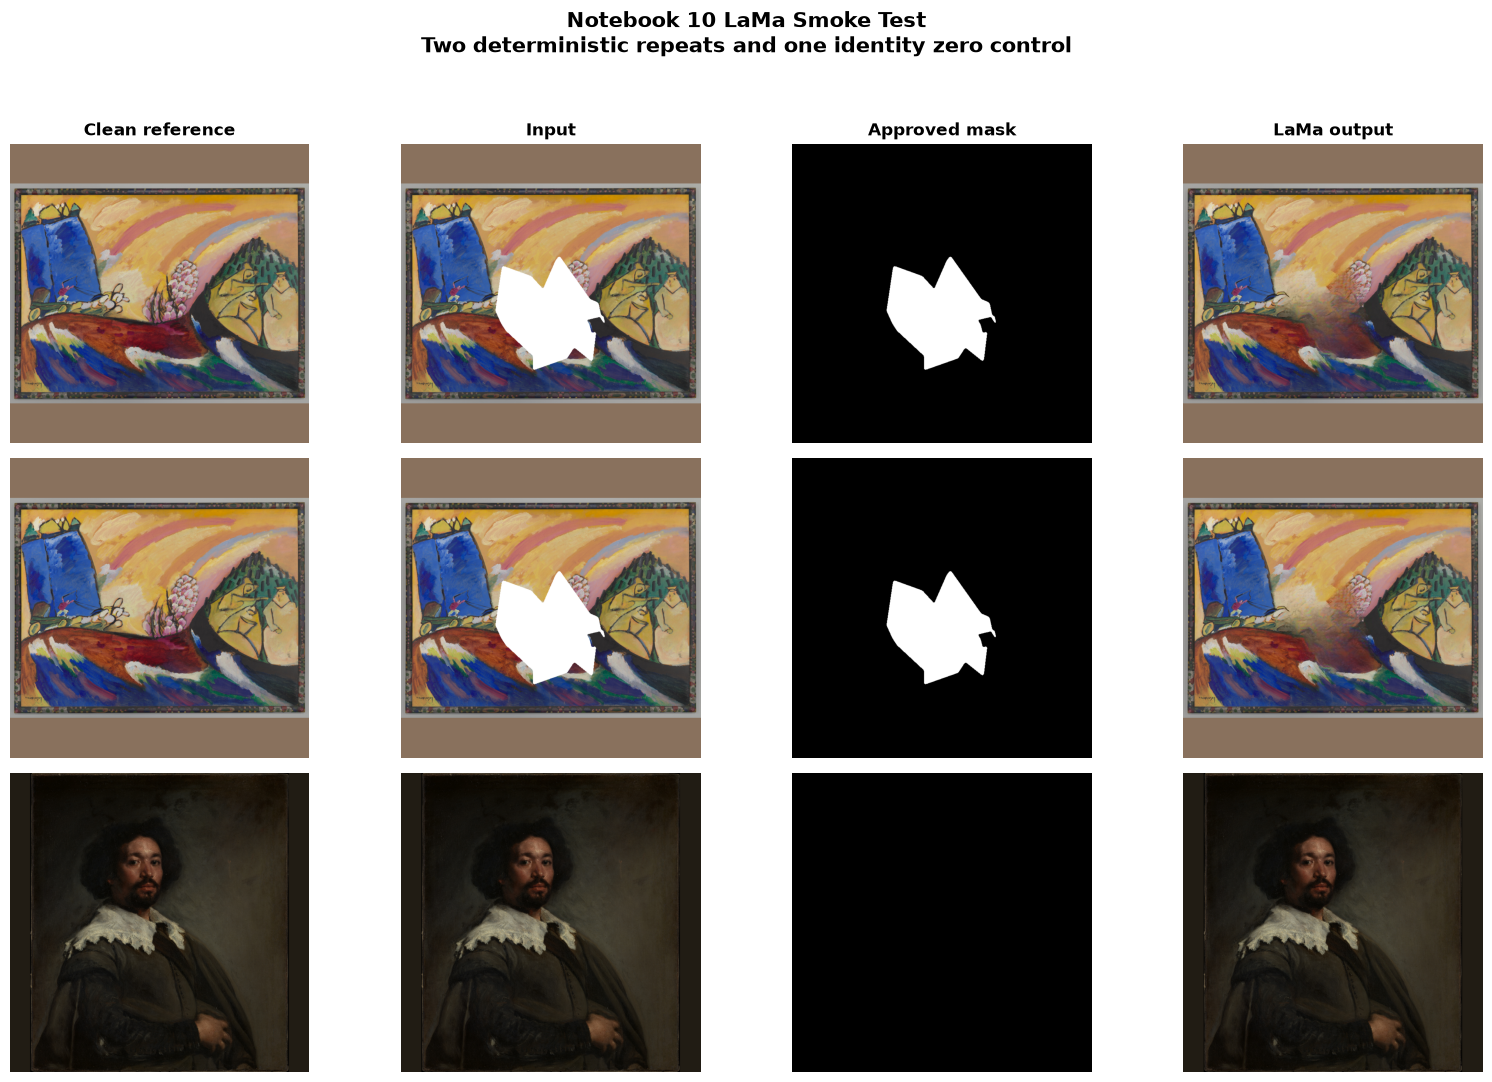

Batch 3 validation checks:


,check_id,severity,expected,observed,passed
0,smoke_record_schema,blocking,"{""issue"": """", ""passed"": true}","{""issue"": """", ""passed"": true}",True
1,smoke_case_identity,blocking,"{""record_count"": 3, ""repeat_count"": 2, ""unique...","{""record_count"": 3, ""repeat_count"": 2, ""unique...",True
2,smoke_execution_status,blocking,"{""completed"": 3}","{""completed"": 3}",True
3,smoke_execution_actions,blocking,"{""identity_noop"": 1, ""lama_inpaint"": 2}","{""identity_noop"": 1, ""lama_inpaint"": 2}",True
4,smoke_iopaint_batch,blocking,"{""attempts"": [1], ""batch_count"": 1, ""case_coun...","{""attempts"": [1], ""batch_count"": 1, ""case_coun...",True
5,repeat_determinism,blocking,"{""all_within_tolerance"": true, ""comparison_row...","{""all_sha256_equal"": false, ""all_within_tolera...",True
6,smoke_output_validation,blocking,"{""passed_rows"": 3, ""validation_rows"": 3}","{""passed_rows"": 3, ""validation_rows"": 3}",True
7,smoke_spatial_invariants,blocking,"{""inference_rows"": 2, ""inside_change_valid"": 2...","{""inference_rows"": 2, ""inside_change_valid"": 2...",True
8,smoke_zero_control_identity,blocking,"{""outside_invariance_valid"": 1, ""zero_control_...","{""outside_invariance_valid"": 1, ""zero_control_...",True
9,smoke_runtime_provenance,blocking,"{""experiment_batch_wall_clock_allocated_mean"":...","{""experiment_batch_wall_clock_allocated_mean"":...",True



Determinism comparison:


,reference_case_id,comparison_case_id,pixel_arrays_equal,sha256_equal,different_pixels,different_pixel_fraction,different_channel_values,maximum_absolute_difference,mean_absolute_difference,sha256_requirement_passed,within_repeatability_tolerance
0,smoke_repeat_01__canonical__p039__loss_large,smoke_repeat_02__canonical__p039__loss_large,False,False,4142,0.007022,4420,1,0.002498,True,True



Smoke restoration records:


...


IOPaint smoke batch:


,batch_id,experiment_id,attempt,case_count,generated_count,return_code,runtime_seconds,timed_out,issue,command_text
0,canonical_missing_region__attempt_01,canonical_missing_region,1,2,2,0,34.358016,False,,D:\Masters\FH\Thesis\painting-restoration-eval...



Smoke output validation:


,restoration_id,case_id,file_exists,readable,width,height,mode,format,checksum_matches,mask_pixels,changed_inside_mask_pixels,changed_outside_mask_pixels,inside_change_valid,outside_invariance_valid,zero_control_valid,validation_passed,issue
0,restoration__lama__canonical__p001__zero_control,canonical__p001__zero_control,True,True,768,768,RGB,PNG,True,0,0,0,True,True,True,True,
1,restoration__lama__smoke_repeat_01__canonical_...,smoke_repeat_01__canonical__p039__loss_large,True,True,768,768,RGB,PNG,True,49001,49001,0,True,True,True,True,
2,restoration__lama__smoke_repeat_02__canonical_...,smoke_repeat_02__canonical__p039__loss_large,True,True,768,768,RGB,PNG,True,49001,49001,0,True,True,True,True,



Batch 3 completed successfully.
Checks: 11
Passed: 11
Smoke records: 3
IOPaint inference outputs: 2
Identity zero controls: 1
Smoke files remain temporary under: outputs/10_lama_restoration/work/smoke
Next approved stage: Batch 4 - resumable full LaMa execution across all 410 eligible cases.


In [11]:
# ---------------------------------------------------------------------------
# Render bounded smoke-test panels in the notebook
# ---------------------------------------------------------------------------
import matplotlib.pyplot as plt

smoke_display_case_ids = [
    *smoke_repeat_case_ids,
    zero_control_source_case_id,
]

smoke_display_worklist_df = (
    smoke_worklist_df.loc[
        smoke_worklist_df[
            "case_id"
        ]
        .astype(str)
        .isin(
            smoke_display_case_ids
        )
    ]
    .copy()
)

smoke_display_records_df = (
    smoke_records_df.loc[
        smoke_records_df[
            "case_id"
        ]
        .astype(str)
        .isin(
            smoke_display_case_ids
        )
    ]
    .copy()
)

smoke_display_df = (
    smoke_display_worklist_df.merge(
        smoke_display_records_df[
            [
                "case_id",
                "restored_path",
                "restored_sha256",
                "execution_action",
                "runtime_seconds",
                "runtime_measurement_method",
                "status",
            ]
        ],
        on="case_id",
        how="inner",
        validate="one_to_one",
    )
)

smoke_display_order = {
    case_id: order_index
    for order_index, case_id
    in enumerate(
        smoke_display_case_ids
    )
}

smoke_display_df[
    "display_order"
] = (
    smoke_display_df[
        "case_id"
    ]
    .map(
        smoke_display_order
    )
)

smoke_display_df = (
    smoke_display_df
    .sort_values(
        "display_order",
        kind="stable",
    )
    .reset_index(
        drop=True
    )
)


figure, axes = plt.subplots(
    nrows=len(
        smoke_display_df
    ),
    ncols=4,
    figsize=(
        16,
        11,
    ),
    squeeze=False,
)

column_titles = (
    "Clean reference",
    "Input",
    "Approved mask",
    "LaMa output",
)

for column_index, column_title in enumerate(
    column_titles
):
    axes[
        0,
        column_index,
    ].set_title(
        column_title,
        fontsize=12,
        fontweight="bold",
    )


for row_index, (_, case_row) in enumerate(
    smoke_display_df.iterrows()
):
    clean_path = (
        PROJECT_ROOT
        / str(
            case_row[
                "clean_image_path"
            ]
        )
    )

    input_path = (
        PROJECT_ROOT
        / str(
            case_row[
                "input_image_path"
            ]
        )
    )

    mask_path = (
        PROJECT_ROOT
        / str(
            case_row[
                "mask_or_effect_path"
            ]
        )
    )

    restored_path = (
        PROJECT_ROOT
        / str(
            case_row[
                "restored_path"
            ]
        )
    )

    with Image.open(
        clean_path
    ) as clean_image:
        clean_rgb = np.asarray(
            clean_image.convert(
                "RGB"
            )
        )

    with Image.open(
        input_path
    ) as input_image:
        input_rgb = np.asarray(
            input_image.convert(
                "RGB"
            )
        )

    with Image.open(
        mask_path
    ) as mask_image:
        mask_gray = np.asarray(
            mask_image.convert(
                "L"
            )
        )

    with Image.open(
        restored_path
    ) as restored_image:
        restored_rgb = np.asarray(
            restored_image.convert(
                "RGB"
            )
        )

    mask_binary = (
        mask_gray
        >= int(
            case_row[
                "mask_threshold"
            ]
        )
    )

    images_to_render = (
        clean_rgb,
        input_rgb,
        mask_binary,
        restored_rgb,
    )

    for column_index, image_array in enumerate(
        images_to_render
    ):
        if column_index == 2:
            axes[
                row_index,
                column_index,
            ].imshow(
                image_array,
                cmap="gray",
                vmin=0,
                vmax=1,
            )
        else:
            axes[
                row_index,
                column_index,
            ].imshow(
                image_array
            )

        axes[
            row_index,
            column_index,
        ].axis(
            "off"
        )

    row_label = (
        str(
            case_row[
                "smoke_role"
            ]
        )
        .replace(
            "_",
            " ",
        )
        .title()
    )

    axes[
        row_index,
        0,
    ].set_ylabel(
        (
            f"{row_label}\n"
            f"{case_row['source_case_id']}"
        ),
        fontsize=9,
    )


figure.suptitle(
    (
        "Notebook 10 LaMa Smoke Test\n"
        "Two deterministic repeats and one identity zero control"
    ),
    fontsize=15,
    fontweight="bold",
)

figure.tight_layout(
    rect=(
        0,
        0,
        1,
        0.95,
    )
)

plt.show()


# ---------------------------------------------------------------------------
# Review tables
# ---------------------------------------------------------------------------

print(
    "Batch 3 validation checks:"
)

display(
    batch_3_checks_df[
        [
            "check_id",
            "severity",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nDeterminism comparison:"
)

display(
    smoke_determinism_df
)


print(
    "\nSmoke restoration records:"
)

display(
    smoke_records_df[
        [
            "case_id",
            "execution_action",
            "device",
            "runtime_seconds",
            "runtime_measurement_method",
            "retry_count",
            "attempt_count",
            "return_code",
            "status",
            "restored_path",
        ]
    ]
)


print(
    "\nIOPaint smoke batch:"
)

display(
    smoke_batch_runs_df[
        [
            "batch_id",
            "experiment_id",
            "attempt",
            "case_count",
            "generated_count",
            "return_code",
            "runtime_seconds",
            "timed_out",
            "issue",
            "command_text",
        ]
    ]
)


print(
    "\nSmoke output validation:"
)

display(
    smoke_output_validation_df
)


print(
    "\nBatch 3 completed successfully."
)

print(
    "Checks:",
    len(
        batch_3_checks_df
    ),
)

print(
    "Passed:",
    int(
        batch_3_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Smoke records:",
    len(
        smoke_records_df
    ),
)

print(
    "IOPaint inference outputs:",
    int(
        smoke_records_df[
            "execution_action"
        ]
        .astype(str)
        .eq(
            "lama_inpaint"
        )
        .sum()
    ),
)

print(
    "Identity zero controls:",
    int(
        smoke_records_df[
            "execution_action"
        ]
        .astype(str)
        .eq(
            "identity_noop"
        )
        .sum()
    ),
)

print(
    "Smoke files remain temporary under:",
    to_repo_relative(
        SMOKE_ROOT,
        PROJECT_ROOT,
    ),
)

print(
    "Next approved stage: "
    "Batch 4 - resumable full LaMa execution "
    "across all 410 eligible cases."
)

## Batch 4 - Full LaMa execution

This batch executes the complete approved 410-case LaMa worklist.

The fixed execution contract remains:

- IOPaint `1.6.0` with the default LaMa model revision;
- CUDA execution without silent CPU fallback;
- no per-case model or parameter tuning;
- binary missing-region threshold: `>=128`;
- synthetic active-effect threshold: `>=13`;
- zero controls: exact identity/no-op;
- masked compositing preserves every outside-mask pixel;
- progress reported every 10 cases;
- normalized checkpoint-based resume;
- maximum one retry after a failed batch;
- commands, runtimes, retry evidence, and failures remain explicit.

Canonical restored images are written under
`outputs/10_lama_restoration/images/restored/<experiment_id>/`.

The downstream restoration table is not persisted until the complete filesystem and scientific validation batches pass.

In [12]:
from restoration_eval.restoration_lama import (
    LAMA_RECORD_COLUMNS,
    run_lama_cases,
    validate_restoration_records,
    write_dataframe_atomic,
)


# ---------------------------------------------------------------------------
# Resolve and guard the canonical execution roots
# ---------------------------------------------------------------------------

RESTORED_ROOT = OUTPUTS[
    "restored_images"
].resolve()

FULL_WORK_ROOT = OUTPUTS[
    "batch_work_directory"
].parent.resolve()

require_notebook_output_path(
    RESTORED_ROOT,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
)

require_notebook_output_path(
    FULL_WORK_ROOT,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
)

RESTORED_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

FULL_WORK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)


# ---------------------------------------------------------------------------
# Construct the exact approved canonical image set
# ---------------------------------------------------------------------------

EXPECTED_CANONICAL_PATH_BY_CASE = {
    str(row["case_id"]): (
        PROJECT_ROOT
        / str(row["planned_restored_path"])
    ).resolve()
    for _, row in execution_worklist_df.iterrows()
}

expected_canonical_file_paths = set(
    EXPECTED_CANONICAL_PATH_BY_CASE.values()
)

if (
    len(expected_canonical_file_paths)
    != EXPECTED_COUNTS["restored_file_count"]
):
    raise ValueError(
        "The canonical LaMa output plan must "
        "contain exactly 410 unique PNG paths."
    )

for expected_path in expected_canonical_file_paths:
    require_notebook_output_path(
        expected_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

    expected_path.relative_to(
        RESTORED_ROOT
    )


# ---------------------------------------------------------------------------
# Remove only unexpected files inside the guarded restored-image root
# ---------------------------------------------------------------------------

existing_restored_files_before = sorted(
    path.resolve()
    for path in RESTORED_ROOT.rglob("*")
    if path.is_file()
)

stale_restored_files = [
    path
    for path in existing_restored_files_before
    if path not in expected_canonical_file_paths
]

stale_file_action = lama_config[
    "execution"
][
    "stale_file_action"
]

if (
    stale_restored_files
    and stale_file_action != "remove"
):
    raise ValueError(
        "Unexpected files exist under the canonical "
        "restored-image directory, but the configured "
        "stale-file action is not 'remove'."
    )

for stale_path in stale_restored_files:
    require_notebook_output_path(
        stale_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

    stale_path.relative_to(
        RESTORED_ROOT
    )

    stale_path.unlink()


# ---------------------------------------------------------------------------
# Load normalized restoration checkpoint evidence
# ---------------------------------------------------------------------------

approved_case_ids = set(
    execution_worklist_df[
        "case_id"
    ].astype(str)
)

resume_checkpoint_df = None
checkpoint_unknown_case_ids = []

if OUTPUTS["checkpoint"].is_file():
    loaded_checkpoint_df = pd.read_csv(
        OUTPUTS["checkpoint"],
        keep_default_na=False,
    )

    validate_restoration_records(
        loaded_checkpoint_df
    )

    checkpoint_unknown_case_ids = sorted(
        set(
            loaded_checkpoint_df[
                "case_id"
            ].astype(str)
        )
        - approved_case_ids
    )

    if checkpoint_unknown_case_ids:
        raise ValueError(
            "The restoration checkpoint contains "
            "unapproved case IDs: "
            f"{checkpoint_unknown_case_ids[:20]}"
        )

    if loaded_checkpoint_df[
        "case_id"
    ].duplicated().any():
        raise ValueError(
            "The restoration checkpoint contains "
            "duplicate case IDs."
        )

    resume_checkpoint_df = (
        loaded_checkpoint_df
        .copy()
        .reset_index(drop=True)
    )


# ---------------------------------------------------------------------------
# Load any existing batch-command checkpoint
# ---------------------------------------------------------------------------

BATCH_RUN_COLUMNS = [
    "batch_id",
    "case_count",
    "generated_count",
    "return_code",
    "runtime_seconds",
    "started_at_utc",
    "completed_at_utc",
    "timed_out",
    "issue",
    "command",
    "command_text",
    "command_log_path",
    "stdout_log_path",
    "stderr_log_path",
    "experiment_id",
    "attempt",
]

existing_batch_runs_checkpoint_df = pd.DataFrame(
    columns=BATCH_RUN_COLUMNS
)

if OUTPUTS[
    "batch_runs_checkpoint"
].is_file():
    existing_batch_runs_checkpoint_df = (
        pd.read_csv(
            OUTPUTS[
                "batch_runs_checkpoint"
            ],
            keep_default_na=False,
        )
    )

    missing_batch_columns = sorted(
        set(BATCH_RUN_COLUMNS)
        - set(
            existing_batch_runs_checkpoint_df.columns
        )
    )

    if missing_batch_columns:
        raise ValueError(
            "The batch-run checkpoint is missing "
            f"columns: {missing_batch_columns}"
        )

    if existing_batch_runs_checkpoint_df[
        "batch_id"
    ].duplicated().any():
        raise ValueError(
            "The batch-run checkpoint contains "
            "duplicate batch IDs."
        )


retained_expected_files = sorted(
    path
    for path in expected_canonical_file_paths
    if path.is_file()
)


print(
    "Batch 4 execution workspace prepared."
)

print(
    "Approved worklist rows:",
    len(execution_worklist_df),
)

print(
    "Model-inference rows:",
    int(
        (
            ~execution_worklist_df[
                "is_zero_control"
            ].astype(bool)
        ).sum()
    ),
)

print(
    "Identity zero controls:",
    int(
        execution_worklist_df[
            "is_zero_control"
        ].astype(bool).sum()
    ),
)

print(
    "Expected canonical images:",
    len(expected_canonical_file_paths),
)

print(
    "Existing approved images:",
    len(retained_expected_files),
)

print(
    "Removed stale images:",
    len(stale_restored_files),
)

print(
    "Resume checkpoint rows:",
    (
        0
        if resume_checkpoint_df is None
        else len(resume_checkpoint_df)
    ),
)

print(
    "Existing batch-command rows:",
    len(existing_batch_runs_checkpoint_df),
)

print(
    "Progress interval:",
    lama_config[
        "execution"
    ][
        "progress_interval_cases"
    ],
    "cases",
)

print(
    "Canonical output root:",
    to_repo_relative(
        RESTORED_ROOT,
        PROJECT_ROOT,
    ),
)

Batch 4 execution workspace prepared.
Approved worklist rows: 410
Model-inference rows: 360
Identity zero controls: 50
Expected canonical images: 410
Existing approved images: 0
Removed stale images: 0
Resume checkpoint rows: 0
Existing batch-command rows: 0
Progress interval: 10 cases
Canonical output root: outputs/10_lama_restoration/images/restored


In [13]:
from time import perf_counter


# ---------------------------------------------------------------------------
# Persist normalized checkpoint snapshots atomically
# ---------------------------------------------------------------------------

def persist_restoration_checkpoint(
    checkpoint_df,
):
    validate_restoration_records(
        checkpoint_df
    )

    write_dataframe_atomic(
        checkpoint_df,
        OUTPUTS["checkpoint"],
    )


def persist_batch_runs_checkpoint(
    batch_runs_df,
):
    missing_columns = sorted(
        set(BATCH_RUN_COLUMNS)
        - set(batch_runs_df.columns)
    )

    if missing_columns:
        raise ValueError(
            "Cannot persist the batch-run checkpoint; "
            f"missing columns: {missing_columns}"
        )

    ordered_batch_runs_df = (
        batch_runs_df[
            BATCH_RUN_COLUMNS
        ]
        .sort_values(
            [
                "experiment_id",
                "attempt",
                "batch_id",
            ],
            kind="stable",
        )
        .reset_index(drop=True)
    )

    write_dataframe_atomic(
        ordered_batch_runs_df,
        OUTPUTS[
            "batch_runs_checkpoint"
        ],
    )


# ---------------------------------------------------------------------------
# Run the complete approved worklist
# ---------------------------------------------------------------------------

FULL_EXECUTION_STARTED_AT_UTC = (
    utc_now_iso()
)

full_execution_timer = perf_counter()

print(
    "Starting full LaMa execution."
)

print(
    "Cases:",
    len(execution_worklist_df),
)

print(
    "Device:",
    lama_runtime_environment[
        "effective_device"
    ],
)

print(
    "IOPaint:",
    lama_runtime_environment[
        "iopaint_version"
    ],
)

print(
    "Progress will be printed every",
    lama_config[
        "execution"
    ][
        "progress_interval_cases"
    ],
    "cases.",
)

print(
    "Do not interrupt the kernel while an "
    "individual IOPaint experiment batch is active."
)


(
    full_restoration_records_df,
    current_batch_runs_df,
) = run_lama_cases(
    execution_worklist_df,
    restored_root=RESTORED_ROOT,
    work_root=FULL_WORK_ROOT,
    project_root=PROJECT_ROOT,
    config=lama_config,
    runtime_environment=(
        lama_runtime_environment
    ),
    resume_records=(
        resume_checkpoint_df
    ),
    progress_callback=print,
    checkpoint_callback=(
        persist_restoration_checkpoint
    ),
)


full_execution_elapsed_seconds = (
    perf_counter()
    - full_execution_timer
)

FULL_EXECUTION_FINISHED_AT_UTC = (
    utc_now_iso()
)


# ---------------------------------------------------------------------------
# Consolidate current and previous batch-command evidence
# ---------------------------------------------------------------------------

batch_run_frames = [
    frame
    for frame in (
        existing_batch_runs_checkpoint_df,
        current_batch_runs_df,
    )
    if not frame.empty
]

if not batch_run_frames:
    raise RuntimeError(
        "No IOPaint batch-command evidence is "
        "available for the full execution."
    )

full_batch_runs_df = (
    pd.concat(
        batch_run_frames,
        ignore_index=True,
        sort=False,
    )
)

missing_batch_columns = sorted(
    set(BATCH_RUN_COLUMNS)
    - set(full_batch_runs_df.columns)
)

if missing_batch_columns:
    raise ValueError(
        "Consolidated batch-command evidence is "
        f"missing columns: {missing_batch_columns}"
    )

full_batch_runs_df[
    "attempt"
] = pd.to_numeric(
    full_batch_runs_df["attempt"],
    errors="raise",
).astype(int)

full_batch_runs_df = (
    full_batch_runs_df
    .drop_duplicates(
        subset=["batch_id"],
        keep="last",
    )
    .sort_values(
        [
            "experiment_id",
            "attempt",
            "batch_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


# ---------------------------------------------------------------------------
# Validate and retain both work checkpoints
# ---------------------------------------------------------------------------

validate_restoration_records(
    full_restoration_records_df
)

persist_restoration_checkpoint(
    full_restoration_records_df
)

persist_batch_runs_checkpoint(
    full_batch_runs_df
)


print(
    "Full execution cell completed."
)

print(
    "Normalized records:",
    len(full_restoration_records_df),
)

print(
    "Batch-command records:",
    len(full_batch_runs_df),
)

print(
    "Elapsed seconds:",
    round(
        full_execution_elapsed_seconds,
        3,
    ),
)

print(
    "Observed overall throughput:",
    round(
        len(full_restoration_records_df)
        / max(
            full_execution_elapsed_seconds,
            1e-12,
        ),
        3,
    ),
    "cases/second",
)

print(
    "Restoration checkpoint:",
    to_repo_relative(
        OUTPUTS["checkpoint"],
        PROJECT_ROOT,
    ),
)

print(
    "Batch-command checkpoint:",
    to_repo_relative(
        OUTPUTS[
            "batch_runs_checkpoint"
        ],
        PROJECT_ROOT,
    ),
)

Starting full LaMa execution.
Cases: 410
Device: cuda
IOPaint: 1.6.0
Progress will be printed every 10 cases.
Do not interrupt the kernel while an individual IOPaint experiment batch is active.
Completed 10/410 (2.4%) | elapsed=4.3s | throughput=2.34 cases/s | latest=canonical__p010__zero_control
Completed 20/410 (4.9%) | elapsed=7.6s | throughput=2.62 cases/s | latest=canonical__p020__zero_control
Completed 30/410 (7.3%) | elapsed=11.5s | throughput=2.61 cases/s | latest=canonical__p030__zero_control
Completed 40/410 (9.8%) | elapsed=15.2s | throughput=2.64 cases/s | latest=canonical__p040__zero_control
Completed 50/410 (12.2%) | elapsed=18.6s | throughput=2.68 cases/s | latest=canonical__p050__zero_control
Generated 60/410 (14.6%) | elapsed=43.5s | throughput=0.23 cases/s | latest_group=canonical_missing_region__attempt_01
Generated 70/410 (17.1%) | elapsed=57.3s | throughput=0.35 cases/s | latest_group=canonical_missing_region__attempt_01
Generated 80/410 (19.5%) | elapsed=72.2s | t

In [14]:
import shutil


# ---------------------------------------------------------------------------
# Join execution records to their approved contracts
# ---------------------------------------------------------------------------

execution_contract_df = (
    execution_worklist_df[
        [
            "case_id",
            "experiment_id",
            "is_zero_control",
            "mask_threshold",
            "planned_restored_path",
        ]
    ]
    .rename(
        columns={
            "mask_threshold": (
                "expected_mask_threshold"
            ),
            "planned_restored_path": (
                "expected_restored_path"
            ),
        }
    )
)

full_execution_audit_df = (
    full_restoration_records_df
    .merge(
        execution_contract_df,
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)


# ---------------------------------------------------------------------------
# Reload and independently validate both checkpoints
# ---------------------------------------------------------------------------

reloaded_checkpoint_df = pd.read_csv(
    OUTPUTS["checkpoint"],
    keep_default_na=False,
)

validate_restoration_records(
    reloaded_checkpoint_df
)

reloaded_batch_runs_df = pd.read_csv(
    OUTPUTS[
        "batch_runs_checkpoint"
    ],
    keep_default_na=False,
)

missing_reloaded_batch_columns = sorted(
    set(BATCH_RUN_COLUMNS)
    - set(reloaded_batch_runs_df.columns)
)

if missing_reloaded_batch_columns:
    raise ValueError(
        "Reloaded batch-command checkpoint is "
        f"missing columns: {missing_reloaded_batch_columns}"
    )


checkpoint_signature = {
    str(row["case_id"]): (
        str(row["restored_path"]),
        str(row["restored_sha256"]),
        str(row["status"]),
    )
    for _, row in reloaded_checkpoint_df.iterrows()
}

execution_signature = {
    str(row["case_id"]): (
        str(row["restored_path"]),
        str(row["restored_sha256"]),
        str(row["status"]),
    )
    for _, row in full_restoration_records_df.iterrows()
}

batch_signature_columns = [
    "experiment_id",
    "attempt",
    "case_count",
    "generated_count",
    "return_code",
    "command_text",
]

batch_checkpoint_signature = {
    str(row["batch_id"]): tuple(
        str(row[column])
        for column in batch_signature_columns
    )
    for _, row in reloaded_batch_runs_df.iterrows()
}

batch_memory_signature = {
    str(row["batch_id"]): tuple(
        str(row[column])
        for column in batch_signature_columns
    )
    for _, row in full_batch_runs_df.iterrows()
}


# ---------------------------------------------------------------------------
# Inspect the exact canonical filesystem scope
# ---------------------------------------------------------------------------

observed_canonical_file_paths = set(
    path.resolve()
    for path in RESTORED_ROOT.rglob("*")
    if path.is_file()
)

recorded_canonical_file_paths = set(
    (
        PROJECT_ROOT
        / str(relative_path)
    ).resolve()
    for relative_path in full_restoration_records_df[
        "restored_path"
    ].astype(str)
)


# ---------------------------------------------------------------------------
# Derive execution evidence
# ---------------------------------------------------------------------------

status_counts = {
    str(status): int(count)
    for status, count in full_restoration_records_df[
        "status"
    ]
    .value_counts()
    .sort_index()
    .items()
}

action_counts = {
    str(action): int(count)
    for action, count in full_restoration_records_df[
        "execution_action"
    ]
    .value_counts()
    .sort_index()
    .items()
}

threshold_counts = {
    int(threshold): int(count)
    for threshold, count in full_restoration_records_df[
        "mask_threshold"
    ]
    .value_counts()
    .sort_index()
    .items()
}


zero_action_valid = bool(
    full_execution_audit_df.loc[
        full_execution_audit_df[
            "is_zero_control"
        ].astype(bool),
        "execution_action",
    ]
    .astype(str)
    .isin(
        {
            "identity_noop",
            "reused_validated",
        }
    )
    .all()
)

nonzero_action_valid = bool(
    full_execution_audit_df.loc[
        ~full_execution_audit_df[
            "is_zero_control"
        ].astype(bool),
        "execution_action",
    ]
    .astype(str)
    .isin(
        {
            "lama_inpaint",
            "reused_validated",
        }
    )
    .all()
)

threshold_assignment_valid = bool(
    pd.to_numeric(
        full_execution_audit_df[
            "mask_threshold"
        ],
        errors="coerce",
    )
    .eq(
        pd.to_numeric(
            full_execution_audit_df[
                "expected_mask_threshold"
            ],
            errors="coerce",
        )
    )
    .all()
)

restored_path_assignment_valid = bool(
    full_execution_audit_df[
        "restored_path"
    ]
    .astype(str)
    .eq(
        full_execution_audit_df[
            "expected_restored_path"
        ]
        .astype(str)
    )
    .all()
)


expected_model_version = (
    "iopaint-"
    + str(
        lama_runtime_environment[
            "iopaint_version"
        ]
    )
    + "__"
    + str(
        lama_runtime_environment[
            "model_revision"
        ]
    )
)

fixed_metadata_valid = bool(
    full_restoration_records_df[
        "model_id"
    ]
    .astype(str)
    .eq(
        lama_config[
            "model"
        ][
            "model_id"
        ]
    )
    .all()
    and full_restoration_records_df[
        "configuration_id"
    ]
    .astype(str)
    .eq(
        lama_config[
            "model"
        ][
            "configuration_id"
        ]
    )
    .all()
    and full_restoration_records_df[
        "algorithm"
    ]
    .astype(str)
    .eq(
        "iopaint run --model lama"
    )
    .all()
    and full_restoration_records_df[
        "model_version"
    ]
    .astype(str)
    .eq(
        expected_model_version
    )
    .all()
    and full_restoration_records_df[
        "iopaint_version"
    ]
    .astype(str)
    .eq(
        str(
            lama_runtime_environment[
                "iopaint_version"
            ]
        )
    )
    .all()
    and full_restoration_records_df[
        "model_revision"
    ]
    .astype(str)
    .eq(
        lama_config[
            "model"
        ][
            "model_revision"
        ]
    )
    .all()
    and full_restoration_records_df[
        "device"
    ]
    .astype(str)
    .eq(
        lama_runtime_environment[
            "effective_device"
        ]
    )
    .all()
    and full_restoration_records_df[
        "precision"
    ]
    .astype(str)
    .eq(
        lama_config[
            "model"
        ][
            "precision"
        ]
    )
    .all()
    and full_restoration_records_df[
        "execution_backend"
    ]
    .astype(str)
    .eq(
        lama_config[
            "model"
        ][
            "execution_backend"
        ]
    )
    .all()
    and full_restoration_records_df[
        "compositing_policy_id"
    ]
    .astype(str)
    .eq(
        lama_config[
            "model"
        ][
            "compositing_policy"
        ]
    )
    .all()
    and full_restoration_records_df[
        "generator_version"
    ]
    .astype(str)
    .eq(
        RESTORATION_GENERATOR_VERSION
    )
    .all()
    and full_restoration_records_df[
        "cpu_environment"
    ]
    .astype(str)
    .str.len()
    .gt(0)
    .all()
    and pd.to_numeric(
        full_restoration_records_df[
            "retry_count"
        ],
        errors="coerce",
    )
    .between(
        0,
        lama_config[
            "model"
        ][
            "maximum_retries"
        ],
        inclusive="both",
    )
    .all()
    and pd.to_numeric(
        full_restoration_records_df[
            "return_code"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
)


failure_records_df = (
    full_execution_audit_df.loc[
        ~full_execution_audit_df[
            "status"
        ]
        .astype(str)
        .eq("completed")
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Retain logs for failed or incomplete IOPaint attempts
# ---------------------------------------------------------------------------

batch_return_codes = pd.to_numeric(
    full_batch_runs_df[
        "return_code"
    ],
    errors="coerce",
)

batch_case_counts = pd.to_numeric(
    full_batch_runs_df[
        "case_count"
    ],
    errors="coerce",
)

batch_generated_counts = pd.to_numeric(
    full_batch_runs_df[
        "generated_count"
    ],
    errors="coerce",
)

batch_timed_out = (
    full_batch_runs_df[
        "timed_out"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

failed_batch_runs_df = (
    full_batch_runs_df.loc[
        batch_return_codes.ne(0)
        | batch_timed_out
        | batch_generated_counts.lt(
            batch_case_counts
        )
    ]
    .copy()
)

retained_failure_log_paths = []

if (
    not failed_batch_runs_df.empty
    and lama_config[
        "execution"
    ][
        "retain_failure_logs"
    ]
):
    OUTPUTS[
        "failure_logs_directory"
    ].mkdir(
        parents=True,
        exist_ok=True,
    )

    for _, batch_row in (
        failed_batch_runs_df.iterrows()
    ):
        batch_id = str(
            batch_row["batch_id"]
        )

        for log_label, log_column in (
            (
                "command",
                "command_log_path",
            ),
            (
                "stdout",
                "stdout_log_path",
            ),
            (
                "stderr",
                "stderr_log_path",
            ),
        ):
            source_value = str(
                batch_row[
                    log_column
                ]
            ).strip()

            if not source_value:
                continue

            source_path = Path(
                source_value
            ).resolve()

            if not source_path.is_file():
                continue

            require_notebook_output_path(
                source_path,
                NOTEBOOK_STEM,
                PROJECT_ROOT,
            )

            destination_suffix = (
                source_path.suffix
                or ".txt"
            )

            destination_path = (
                OUTPUTS[
                    "failure_logs_directory"
                ]
                / (
                    f"{batch_id}"
                    f"__{log_label}"
                    f"{destination_suffix}"
                )
            )

            require_notebook_output_path(
                destination_path,
                NOTEBOOK_STEM,
                PROJECT_ROOT,
            )

            shutil.copy2(
                source_path,
                destination_path,
            )

            retained_failure_log_paths.append(
                destination_path.resolve()
            )


failed_batch_ids = set(
    failed_batch_runs_df[
        "batch_id"
    ].astype(str)
)

retained_failure_log_batch_ids = {
    path.name.split(
        "__",
        maxsplit=2,
    )[0]
    + "__"
    + path.name.split(
        "__",
        maxsplit=2,
    )[1]
    for path in retained_failure_log_paths
    if "__" in path.name
}

failure_log_retention_valid = bool(
    not failed_batch_ids
    or failed_batch_ids.issubset(
        retained_failure_log_batch_ids
    )
)


# ---------------------------------------------------------------------------
# Batch-command provenance evidence
# ---------------------------------------------------------------------------

required_batch_experiments = set(
    execution_worklist_df.loc[
        ~execution_worklist_df[
            "is_zero_control"
        ].astype(bool),
        "experiment_id",
    ].astype(str)
)

observed_batch_experiments = set(
    full_batch_runs_df[
        "experiment_id"
    ].astype(str)
)

batch_attempt_values = pd.to_numeric(
    full_batch_runs_df[
        "attempt"
    ],
    errors="coerce",
)

batch_command_text_valid = bool(
    full_batch_runs_df[
        "command_text"
    ]
    .astype(str)
    .str.strip()
    .str.len()
    .gt(0)
    .all()
)

batch_command_logs_valid = bool(
    full_batch_runs_df[
        "command_log_path"
    ]
    .astype(str)
    .map(
        lambda path_value: Path(
            path_value
        ).is_file()
    )
    .all()
)

batch_provenance_valid = bool(
    observed_batch_experiments
    == required_batch_experiments
    and full_batch_runs_df[
        "batch_id"
    ].is_unique
    and len(full_batch_runs_df)
    >= len(required_batch_experiments)
    and len(full_batch_runs_df)
    <= (
        len(required_batch_experiments)
        * (
            int(
                lama_config[
                    "model"
                ][
                    "maximum_retries"
                ]
            )
            + 1
        )
    )
    and batch_attempt_values.ge(1).all()
    and batch_attempt_values.le(
        int(
            lama_config[
                "model"
            ][
                "maximum_retries"
            ]
        )
        + 1
    ).all()
    and batch_command_text_valid
    and batch_command_logs_valid
    and failure_log_retention_valid
)


# ---------------------------------------------------------------------------
# Register consolidated Batch 4 checks
# ---------------------------------------------------------------------------

def add_batch_4_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "batch_4_full_execution"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_batch_4_check(
    check_id="full_execution_cardinality",
    description=(
        "Full execution produced one normalized "
        "record per approved LaMa case."
    ),
    expected={
        "record_count": 410,
        "unique_case_ids": 410,
        "unique_restoration_ids": 410,
        "duplicate_case_ids": 0,
    },
    observed={
        "record_count": len(
            full_restoration_records_df
        ),
        "unique_case_ids": int(
            full_restoration_records_df[
                "case_id"
            ].nunique()
        ),
        "unique_restoration_ids": int(
            full_restoration_records_df[
                "restoration_id"
            ].nunique()
        ),
        "duplicate_case_ids": int(
            full_restoration_records_df[
                "case_id"
            ].duplicated().sum()
        ),
    },
    passed=(
        len(full_restoration_records_df)
        == 410
        and full_restoration_records_df[
            "case_id"
        ].nunique()
        == 410
        and full_restoration_records_df[
            "restoration_id"
        ].nunique()
        == 410
        and not full_restoration_records_df[
            "case_id"
        ].duplicated().any()
    ),
)


add_batch_4_check(
    check_id="full_execution_status",
    description=(
        "Every approved case completed and "
        "no failure was silently omitted."
    ),
    expected={
        "completed": 410,
        "failed": 0,
    },
    observed={
        "status_counts": status_counts,
        "failure_count": len(
            failure_records_df
        ),
    },
    passed=(
        status_counts
        == {
            "completed": 410,
        }
        and failure_records_df.empty
    ),
    details=(
        failure_records_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


add_batch_4_check(
    check_id="execution_action_semantics",
    description=(
        "Fresh and checkpoint-reused records "
        "retain the approved zero/non-zero "
        "execution semantics."
    ),
    expected={
        "zero_controls": 50,
        "nonzero_cases": 360,
        "zero_actions_valid": True,
        "nonzero_actions_valid": True,
    },
    observed={
        "zero_controls": int(
            full_execution_audit_df[
                "is_zero_control"
            ].astype(bool).sum()
        ),
        "nonzero_cases": int(
            (
                ~full_execution_audit_df[
                    "is_zero_control"
                ].astype(bool)
            ).sum()
        ),
        "action_counts": action_counts,
        "zero_actions_valid": (
            zero_action_valid
        ),
        "nonzero_actions_valid": (
            nonzero_action_valid
        ),
    },
    passed=(
        int(
            full_execution_audit_df[
                "is_zero_control"
            ].astype(bool).sum()
        )
        == 50
        and int(
            (
                ~full_execution_audit_df[
                    "is_zero_control"
                ].astype(bool)
            ).sum()
        )
        == 360
        and zero_action_valid
        and nonzero_action_valid
    ),
)


add_batch_4_check(
    check_id="fixed_execution_metadata",
    description=(
        "Every record preserves the fixed "
        "LaMa, IOPaint, CUDA, precision, "
        "retry, and compositing contract."
    ),
    expected={
        "model_version": (
            expected_model_version
        ),
        "device": "cuda",
        "precision": "float32",
        "maximum_retries": 1,
        "metadata_valid": True,
    },
    observed={
        "model_versions": sorted(
            full_restoration_records_df[
                "model_version"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
        "device_values": sorted(
            full_restoration_records_df[
                "device"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
        "precision_values": sorted(
            full_restoration_records_df[
                "precision"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
        "retry_values": sorted(
            pd.to_numeric(
                full_restoration_records_df[
                    "retry_count"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "metadata_valid": (
            fixed_metadata_valid
        ),
    },
    passed=(
        fixed_metadata_valid
    ),
)


add_batch_4_check(
    check_id="full_threshold_dispatch",
    description=(
        "All records use their approved binary "
        "or synthetic mask threshold."
    ),
    expected={
        13: 50,
        128: 360,
    },
    observed=threshold_counts,
    passed=(
        threshold_counts
        == {
            13: 50,
            128: 360,
        }
        and threshold_assignment_valid
    ),
)


add_batch_4_check(
    check_id="canonical_restored_paths",
    description=(
        "Every record points to its exact "
        "planned notebook-owned output path."
    ),
    expected={
        "path_assignments_valid": True,
        "recorded_path_count": 410,
    },
    observed={
        "path_assignments_valid": (
            restored_path_assignment_valid
        ),
        "recorded_path_count": len(
            recorded_canonical_file_paths
        ),
    },
    passed=(
        restored_path_assignment_valid
        and len(
            recorded_canonical_file_paths
        )
        == 410
    ),
)


add_batch_4_check(
    check_id="canonical_image_filesystem_scope",
    description=(
        "The canonical restored-image directory "
        "contains exactly 410 approved non-empty PNGs."
    ),
    expected={
        "expected_files": 410,
        "observed_files": 410,
        "missing_files": 0,
        "unexpected_files": 0,
        "empty_files": 0,
    },
    observed={
        "expected_files": len(
            expected_canonical_file_paths
        ),
        "observed_files": len(
            observed_canonical_file_paths
        ),
        "missing_files": len(
            expected_canonical_file_paths
            - observed_canonical_file_paths
        ),
        "unexpected_files": len(
            observed_canonical_file_paths
            - expected_canonical_file_paths
        ),
        "empty_files": sum(
            path.stat().st_size <= 0
            for path in observed_canonical_file_paths
        ),
    },
    passed=(
        observed_canonical_file_paths
        == expected_canonical_file_paths
        == recorded_canonical_file_paths
        and all(
            path.stat().st_size > 0
            for path in observed_canonical_file_paths
        )
    ),
)


add_batch_4_check(
    check_id="restored_checksum_evidence",
    description=(
        "Every completed output records a valid "
        "SHA-256 checksum and non-negative runtime."
    ),
    expected={
        "valid_hashes": 410,
        "nonnegative_runtimes": 410,
    },
    observed={
        "valid_hashes": int(
            full_restoration_records_df[
                "restored_sha256"
            ]
            .astype(str)
            .str.fullmatch(
                r"[0-9a-f]{64}"
            )
            .sum()
        ),
        "nonnegative_runtimes": int(
            pd.to_numeric(
                full_restoration_records_df[
                    "runtime_seconds"
                ],
                errors="coerce",
            )
            .ge(0)
            .sum()
        ),
    },
    passed=(
        full_restoration_records_df[
            "restored_sha256"
        ]
        .astype(str)
        .str.fullmatch(
            r"[0-9a-f]{64}"
        )
        .all()
        and pd.to_numeric(
            full_restoration_records_df[
                "runtime_seconds"
            ],
            errors="coerce",
        )
        .ge(0)
        .all()
    ),
)


add_batch_4_check(
    check_id="batch_command_provenance",
    description=(
        "Every inference experiment retains "
        "bounded attempt, command, and log evidence."
    ),
    expected={
        "experiments": sorted(
            required_batch_experiments
        ),
        "minimum_batches": 4,
        "maximum_batches": 8,
        "commands_present": True,
        "command_logs_present": True,
        "failed_attempt_logs_retained": True,
    },
    observed={
        "experiments": sorted(
            observed_batch_experiments
        ),
        "batch_count": len(
            full_batch_runs_df
        ),
        "attempt_values": sorted(
            batch_attempt_values
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "commands_present": (
            batch_command_text_valid
        ),
        "command_logs_present": (
            batch_command_logs_valid
        ),
        "failed_attempt_count": len(
            failed_batch_runs_df
        ),
        "retained_failure_logs": len(
            retained_failure_log_paths
        ),
        "failed_attempt_logs_retained": (
            failure_log_retention_valid
        ),
    },
    passed=(
        batch_provenance_valid
    ),
)


add_batch_4_check(
    check_id="completed_work_checkpoints",
    description=(
        "Both work checkpoints reload with "
        "the complete execution and command evidence."
    ),
    expected={
        "restoration_rows": 410,
        "restoration_checkpoint_matches": True,
        "batch_checkpoint_matches": True,
    },
    observed={
        "restoration_rows": len(
            reloaded_checkpoint_df
        ),
        "restoration_checkpoint_matches": (
            checkpoint_signature
            == execution_signature
        ),
        "batch_checkpoint_matches": (
            batch_checkpoint_signature
            == batch_memory_signature
        ),
    },
    passed=(
        len(reloaded_checkpoint_df)
        == 410
        and checkpoint_signature
        == execution_signature
        and batch_checkpoint_signature
        == batch_memory_signature
    ),
)


all_validation_checks_df = (
    VALIDATION.to_dataframe()
)

batch_4_checks_df = (
    all_validation_checks_df.loc[
        all_validation_checks_df[
            "validation_stage"
        ]
        == "batch_4_full_execution"
    ]
    .drop_duplicates(
        subset=["check_id"],
        keep="last",
    )
    .reset_index(drop=True)
)

VALIDATION.raise_for_blocking()


print(
    "Batch 4 validation completed."
)

print(
    "Checks passed:",
    int(
        batch_4_checks_df[
            "passed"
        ].sum()
    ),
    "/",
    len(batch_4_checks_df),
)

print(
    "Canonical images:",
    len(
        observed_canonical_file_paths
    ),
)

print(
    "Failed restoration records:",
    len(
        failure_records_df
    ),
)

print(
    "Failed or incomplete batch attempts:",
    len(
        failed_batch_runs_df
    ),
)

Batch 4 validation completed.
Checks passed: 10 / 10
Canonical images: 410
Failed restoration records: 0
Failed or incomplete batch attempts: 0


In [15]:
# ---------------------------------------------------------------------------
# Compact execution summaries
# ---------------------------------------------------------------------------

execution_by_experiment_df = (
    full_execution_audit_df
    .assign(
        runtime_seconds_numeric=(
            pd.to_numeric(
                full_execution_audit_df[
                    "runtime_seconds"
                ],
                errors="coerce",
            )
        )
    )
    .groupby(
        "experiment_id",
        as_index=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        completed_count=(
            "status",
            lambda values: int(
                values.astype(str)
                .eq("completed")
                .sum()
            ),
        ),
        total_runtime_seconds=(
            "runtime_seconds_numeric",
            "sum",
        ),
        median_runtime_seconds=(
            "runtime_seconds_numeric",
            "median",
        ),
        maximum_runtime_seconds=(
            "runtime_seconds_numeric",
            "max",
        ),
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


execution_action_summary_df = (
    full_restoration_records_df
    .assign(
        runtime_seconds_numeric=(
            pd.to_numeric(
                full_restoration_records_df[
                    "runtime_seconds"
                ],
                errors="coerce",
            )
        )
    )
    .groupby(
        "execution_action",
        as_index=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        total_runtime_seconds=(
            "runtime_seconds_numeric",
            "sum",
        ),
        median_runtime_seconds=(
            "runtime_seconds_numeric",
            "median",
        ),
    )
    .sort_values(
        "execution_action",
        kind="stable",
    )
    .reset_index(drop=True)
)


batch_execution_summary_df = (
    full_batch_runs_df[
        [
            "batch_id",
            "experiment_id",
            "attempt",
            "case_count",
            "generated_count",
            "return_code",
            "runtime_seconds",
            "timed_out",
            "issue",
        ]
    ]
    .copy()
    .sort_values(
        [
            "experiment_id",
            "attempt",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)


print(
    "Batch 4 validation checks:"
)

display(
    batch_4_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
        ]
)


print(
    "\nExecution by experiment:"
)

display(
    execution_by_experiment_df
)


print(
    "\nExecution actions:"
)

display(
    execution_action_summary_df
)


print(
    "\nIOPaint batch execution:"
)

display(
    batch_execution_summary_df
)


if not failure_records_df.empty:
    print(
        "\nVisible restoration failures:"
    )

    display(
        failure_records_df[
            [
                "case_id",
                "experiment_id",
                "execution_action",
                "status",
                "issue",
            ]
        ]
    )


if not failed_batch_runs_df.empty:
    print(
        "\nFailed or incomplete batch attempts:"
    )

    display(
        failed_batch_runs_df[
            [
                "batch_id",
                "experiment_id",
                "attempt",
                "case_count",
                "generated_count",
                "return_code",
                "timed_out",
                "issue",
            ]
        ]
    )


print(
    "\nBatch 4 completed successfully."
)

print(
    "Records:",
    len(
        full_restoration_records_df
    ),
)

print(
    "Canonical restored PNGs:",
    len(
        observed_canonical_file_paths
    ),
)

print(
    "IOPaint batch-command rows:",
    len(
        full_batch_runs_df
    ),
)

print(
    "Full execution elapsed seconds:",
    round(
        full_execution_elapsed_seconds,
        3,
    ),
)

print(
    "Important interpretation: "
    "LaMa outputs are learned baseline "
    "predictions, not evidence of historically "
    "valid reconstruction."
)

print(
    "Next approved stage: "
    "Batch 5 - complete scientific and "
    "filesystem validation."
)

Batch 4 validation checks:


,check_id,expected,observed,passed
0,full_execution_cardinality,"{""duplicate_case_ids"": 0, ""record_count"": 410,...","{""duplicate_case_ids"": 0, ""record_count"": 410,...",True
1,full_execution_status,"{""completed"": 410, ""failed"": 0}","{""failure_count"": 0, ""status_counts"": {""comple...",True
2,execution_action_semantics,"{""nonzero_actions_valid"": true, ""nonzero_cases...","{""action_counts"": {""identity_noop"": 50, ""lama_...",True
3,fixed_execution_metadata,"{""device"": ""cuda"", ""maximum_retries"": 1, ""meta...","{""device_values"": [""cuda""], ""metadata_valid"": ...",True
4,full_threshold_dispatch,"{""13"": 50, ""128"": 360}","{""13"": 50, ""128"": 360}",True
5,canonical_restored_paths,"{""path_assignments_valid"": true, ""recorded_pat...","{""path_assignments_valid"": true, ""recorded_pat...",True
6,canonical_image_filesystem_scope,"{""empty_files"": 0, ""expected_files"": 410, ""mis...","{""empty_files"": 0, ""expected_files"": 410, ""mis...",True
7,restored_checksum_evidence,"{""nonnegative_runtimes"": 410, ""valid_hashes"": ...","{""nonnegative_runtimes"": 410, ""valid_hashes"": ...",True
8,batch_command_provenance,"{""command_logs_present"": true, ""commands_prese...","{""attempt_values"": [1], ""batch_count"": 4, ""com...",True
9,completed_work_checkpoints,"{""batch_checkpoint_matches"": true, ""restoratio...","{""batch_checkpoint_matches"": true, ""restoratio...",True



Execution by experiment:


,experiment_id,case_count,completed_count,total_runtime_seconds,median_runtime_seconds,maximum_runtime_seconds
0,canonical_missing_region,250,250,331.585832,1.567178,1.567178
1,damage_size_sensitivity,35,35,83.824458,2.394985,2.394985
2,mask_robustness,75,75,137.429242,1.832390,1.832390
3,synthetic_degradation,50,50,102.253576,2.045072,2.045072



Execution actions:


,execution_action,case_count,total_runtime_seconds,median_runtime_seconds
0,identity_noop,50,18.150173,0.357310
1,lama_inpaint,360,636.942935,1.567178



IOPaint batch execution:


,batch_id,experiment_id,attempt,case_count,generated_count,return_code,runtime_seconds,timed_out,issue
0,canonical_missing_region__attempt_01,canonical_missing_region,1,200,200,0,313.435659,False,
1,damage_size_sensitivity__attempt_01,damage_size_sensitivity,1,35,35,0,83.824458,False,
2,mask_robustness__attempt_01,mask_robustness,1,75,75,0,137.429242,False,
3,synthetic_degradation__attempt_01,synthetic_degradation,1,50,50,0,102.253576,False,



Batch 4 completed successfully.
Records: 410
Canonical restored PNGs: 410
IOPaint batch-command rows: 4
Full execution elapsed seconds: 826.115
Important interpretation: LaMa outputs are learned baseline predictions, not evidence of historically valid reconstruction.
Next approved stage: Batch 5 - complete scientific and filesystem validation.


## Batch 5 - Scientific and filesystem validation

This batch independently reloads and validates every canonical LaMa restoration.

Validation covers:

- normalized execution-record integrity;
- exact record and file cardinalities;
- image readability, dimensions, mode, and format;
- persisted-file checksum agreement;
- exact zero-control identity;
- positive inside-mask change for every non-zero case;
- exact outside-mask invariance;
- stale, missing, orphaned, and empty-file detection;
- output-path ownership;
- consolidated validation results by experiment.

These checks validate execution integrity and spatial behavior. They do not claim that generated content is historically, semantically, or visually correct.

In [16]:
# ---------------------------------------------------------------------------
# Reload the normalized execution checkpoint
# ---------------------------------------------------------------------------

validation_records_df = pd.read_csv(
    OUTPUTS["checkpoint"],
    keep_default_na=False,
)

validate_restoration_records(
    validation_records_df
)


approved_validation_case_ids = set(
    execution_worklist_df[
        "case_id"
    ].astype(str)
)

observed_validation_case_ids = set(
    validation_records_df[
        "case_id"
    ].astype(str)
)

if (
    observed_validation_case_ids
    != approved_validation_case_ids
):
    raise ValueError(
        "The completed checkpoint does not match "
        "the exact approved LaMa worklist."
    )

if validation_records_df[
    "case_id"
].duplicated().any():
    raise ValueError(
        "The completed checkpoint contains "
        "duplicate case IDs."
    )


# ---------------------------------------------------------------------------
# Reload images and validate them in progress-reporting chunks
# ---------------------------------------------------------------------------

VALIDATION_CHUNK_SIZE = int(
    lama_config[
        "execution"
    ][
        "progress_interval_cases"
    ]
)

ordered_validation_worklist_df = (
    execution_worklist_df
    .sort_values(
        [
            "experiment_id",
            "case_id",
        ],
        kind="stable",
    )
    .reset_index(drop=True)
)

validation_audit_chunks = []

validation_timer = perf_counter()

total_validation_cases = len(
    ordered_validation_worklist_df
)


print(
    "Starting persisted LaMa output validation."
)

print(
    "Cases:",
    total_validation_cases,
)

print(
    "Progress interval:",
    VALIDATION_CHUNK_SIZE,
)


for chunk_start in range(
    0,
    total_validation_cases,
    VALIDATION_CHUNK_SIZE,
):
    chunk_end = min(
        chunk_start
        + VALIDATION_CHUNK_SIZE,
        total_validation_cases,
    )

    worklist_chunk_df = (
        ordered_validation_worklist_df
        .iloc[
            chunk_start:chunk_end
        ]
        .copy()
    )

    chunk_case_ids = set(
        worklist_chunk_df[
            "case_id"
        ].astype(str)
    )

    records_chunk_df = (
        validation_records_df.loc[
            validation_records_df[
                "case_id"
            ]
            .astype(str)
            .isin(chunk_case_ids)
        ]
        .copy()
    )

    if (
        len(records_chunk_df)
        != len(worklist_chunk_df)
    ):
        raise ValueError(
            "A validation chunk does not contain "
            "one record per approved case."
        )

    audit_chunk_df = (
        validate_restoration_outputs(
            records_chunk_df,
            worklist_chunk_df,
            project_root=PROJECT_ROOT,
            config=lama_config,
        )
    )

    validation_audit_chunks.append(
        audit_chunk_df
    )

    completed_validation_cases = (
        chunk_end
    )

    elapsed_validation_seconds = max(
        perf_counter()
        - validation_timer,
        1e-12,
    )

    latest_validated_case_id = str(
        worklist_chunk_df.iloc[
            -1
        ][
            "case_id"
        ]
    )

    print(
        (
            f"Validated "
            f"{completed_validation_cases}/"
            f"{total_validation_cases} "
            f"({completed_validation_cases / total_validation_cases:.1%})"
            f" | elapsed={elapsed_validation_seconds:.1f}s"
            f" | throughput="
            f"{completed_validation_cases / elapsed_validation_seconds:.2f} "
            f"cases/s"
            f" | latest={latest_validated_case_id}"
        )
    )


full_output_audit_df = pd.concat(
    validation_audit_chunks,
    ignore_index=True,
)


validation_case_order = {
    str(case_id): position
    for position, case_id in enumerate(
        ordered_validation_worklist_df[
            "case_id"
        ].astype(str)
    )
}

full_output_audit_df[
    "validation_order"
] = (
    full_output_audit_df[
        "case_id"
    ]
    .astype(str)
    .map(validation_case_order)
)

full_output_audit_df = (
    full_output_audit_df
    .sort_values(
        "validation_order",
        kind="stable",
    )
    .drop(
        columns=[
            "validation_order",
        ]
    )
    .reset_index(drop=True)
)


full_validation_elapsed_seconds = (
    perf_counter()
    - validation_timer
)


print(
    "Persisted-output validation cell completed."
)

print(
    "Audit rows:",
    len(full_output_audit_df),
)

print(
    "Validation-passed rows:",
    int(
        full_output_audit_df[
            "validation_passed"
        ].astype(bool).sum()
    ),
)

print(
    "Elapsed seconds:",
    round(
        full_validation_elapsed_seconds,
        3,
    ),
)

Starting persisted LaMa output validation.
Cases: 410
Progress interval: 10
Validated 10/410 (2.4%) | elapsed=0.8s | throughput=12.18 cases/s | latest=canonical__p002__zero_control
Validated 20/410 (4.9%) | elapsed=1.8s | throughput=11.40 cases/s | latest=canonical__p004__zero_control
Validated 30/410 (7.3%) | elapsed=2.6s | throughput=11.40 cases/s | latest=canonical__p006__zero_control
Validated 40/410 (9.8%) | elapsed=3.6s | throughput=11.21 cases/s | latest=canonical__p008__zero_control
Validated 50/410 (12.2%) | elapsed=4.5s | throughput=11.01 cases/s | latest=canonical__p010__zero_control
Validated 60/410 (14.6%) | elapsed=5.4s | throughput=11.01 cases/s | latest=canonical__p012__zero_control
Validated 70/410 (17.1%) | elapsed=6.2s | throughput=11.22 cases/s | latest=canonical__p014__zero_control
Validated 80/410 (19.5%) | elapsed=7.1s | throughput=11.22 cases/s | latest=canonical__p016__zero_control
Validated 90/410 (22.0%) | elapsed=8.0s | throughput=11.27 cases/s | latest=cano

In [17]:
# ---------------------------------------------------------------------------
# Attach execution and experiment evidence to the image audit
# ---------------------------------------------------------------------------

full_scientific_audit_df = (
    full_output_audit_df
    .merge(
        validation_records_df[
            [
                "case_id",
                "restored_path",
                "mask_threshold",
                "execution_action",
                "status",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        execution_worklist_df[
            [
                "case_id",
                "experiment_id",
                "planned_restored_path",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)


full_scientific_audit_df[
    "is_zero_control"
] = pd.to_numeric(
    full_scientific_audit_df[
        "mask_pixels"
    ],
    errors="coerce",
).eq(0)


zero_control_audit_df = (
    full_scientific_audit_df.loc[
        full_scientific_audit_df[
            "is_zero_control"
        ]
    ]
    .copy()
)

nonzero_case_audit_df = (
    full_scientific_audit_df.loc[
        ~full_scientific_audit_df[
            "is_zero_control"
        ]
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Rebuild the exact expected, recorded, and observed file sets
# ---------------------------------------------------------------------------

expected_validation_file_paths = set(
    (
        PROJECT_ROOT
        / str(relative_path)
    ).resolve()
    for relative_path in execution_worklist_df[
        "planned_restored_path"
    ].astype(str)
)

recorded_validation_file_paths = set(
    (
        PROJECT_ROOT
        / str(relative_path)
    ).resolve()
    for relative_path in validation_records_df[
        "restored_path"
    ].astype(str)
)

observed_validation_file_paths = set(
    path.resolve()
    for path in RESTORED_ROOT.rglob("*")
    if path.is_file()
)


missing_validation_files = (
    expected_validation_file_paths
    - observed_validation_file_paths
)

orphaned_validation_files = (
    observed_validation_file_paths
    - expected_validation_file_paths
)

empty_validation_files = {
    path
    for path in observed_validation_file_paths
    if path.stat().st_size <= 0
}


# ---------------------------------------------------------------------------
# Derive detailed validation conditions
# ---------------------------------------------------------------------------

file_geometry_valid = bool(
    full_scientific_audit_df[
        "file_exists"
    ]
    .astype(bool)
    .all()
    and full_scientific_audit_df[
        "readable"
    ]
    .astype(bool)
    .all()
    and pd.to_numeric(
        full_scientific_audit_df[
            "width"
        ],
        errors="coerce",
    )
    .eq(
        lama_config[
            "execution"
        ][
            "target_width"
        ]
    )
    .all()
    and pd.to_numeric(
        full_scientific_audit_df[
            "height"
        ],
        errors="coerce",
    )
    .eq(
        lama_config[
            "execution"
        ][
            "target_height"
        ]
    )
    .all()
    and full_scientific_audit_df[
        "mode"
    ]
    .astype(str)
    .eq(
        lama_config[
            "execution"
        ][
            "output_mode"
        ]
    )
    .all()
    and full_scientific_audit_df[
        "format"
    ]
    .astype(str)
    .eq(
        lama_config[
            "execution"
        ][
            "output_format"
        ]
    )
    .all()
)


checksum_integrity_valid = bool(
    full_scientific_audit_df[
        "checksum_matches"
    ]
    .astype(bool)
    .all()
)


zero_control_identity_valid = bool(
    len(zero_control_audit_df)
    == 50
    and pd.to_numeric(
        zero_control_audit_df[
            "changed_inside_mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
    and pd.to_numeric(
        zero_control_audit_df[
            "changed_outside_mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
    and zero_control_audit_df[
        "zero_control_valid"
    ]
    .astype(bool)
    .all()
)


nonzero_inside_change_valid = bool(
    len(nonzero_case_audit_df)
    == 360
    and pd.to_numeric(
        nonzero_case_audit_df[
            "mask_pixels"
        ],
        errors="coerce",
    )
    .gt(0)
    .all()
    and pd.to_numeric(
        nonzero_case_audit_df[
            "changed_inside_mask_pixels"
        ],
        errors="coerce",
    )
    .gt(0)
    .all()
    and nonzero_case_audit_df[
        "inside_change_valid"
    ]
    .astype(bool)
    .all()
)


outside_mask_invariance_valid = bool(
    pd.to_numeric(
        full_scientific_audit_df[
            "changed_outside_mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
    and full_scientific_audit_df[
        "outside_invariance_valid"
    ]
    .astype(bool)
    .all()
)


restored_path_ownership_valid = bool(
    full_scientific_audit_df[
        "restored_path"
    ]
    .astype(str)
    .eq(
        full_scientific_audit_df[
            "planned_restored_path"
        ]
        .astype(str)
    )
    .all()
    and full_scientific_audit_df[
        "restored_path"
    ]
    .astype(str)
    .str.startswith(
        (
            "outputs/"
            "10_lama_restoration/"
            "images/restored/"
        )
    )
    .all()
)


complete_audit_valid = bool(
    full_scientific_audit_df[
        "validation_passed"
    ]
    .astype(bool)
    .all()
    and full_scientific_audit_df[
        "issue"
    ]
    .fillna("")
    .astype(str)
    .str.len()
    .eq(0)
    .all()
)


failed_scientific_audit_df = (
    full_scientific_audit_df.loc[
        ~full_scientific_audit_df[
            "validation_passed"
        ]
        .astype(bool)
    ]
    .copy()
)


# ---------------------------------------------------------------------------
# Register Batch 5 validation evidence
# ---------------------------------------------------------------------------

def add_batch_5_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "batch_5_scientific_validation"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_batch_5_check(
    check_id="persisted_audit_cardinality",
    description=(
        "Every approved restoration has one "
        "unique persisted-output audit."
    ),
    expected={
        "audit_rows": 410,
        "unique_case_ids": 410,
        "unique_restoration_ids": 410,
    },
    observed={
        "audit_rows": len(
            full_scientific_audit_df
        ),
        "unique_case_ids": int(
            full_scientific_audit_df[
                "case_id"
            ].nunique()
        ),
        "unique_restoration_ids": int(
            full_scientific_audit_df[
                "restoration_id"
            ].nunique()
        ),
    },
    passed=(
        len(full_scientific_audit_df)
        == 410
        and full_scientific_audit_df[
            "case_id"
        ].nunique()
        == 410
        and full_scientific_audit_df[
            "restoration_id"
        ].nunique()
        == 410
    ),
)


add_batch_5_check(
    check_id="persisted_image_contract",
    description=(
        "All restored images reload as readable "
        "768x768 RGB PNG files."
    ),
    expected={
        "valid_images": 410,
        "width": 768,
        "height": 768,
        "mode": "RGB",
        "format": "PNG",
    },
    observed={
        "existing_files": int(
            full_scientific_audit_df[
                "file_exists"
            ].astype(bool).sum()
        ),
        "readable_files": int(
            full_scientific_audit_df[
                "readable"
            ].astype(bool).sum()
        ),
        "width_values": sorted(
            pd.to_numeric(
                full_scientific_audit_df[
                    "width"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "height_values": sorted(
            pd.to_numeric(
                full_scientific_audit_df[
                    "height"
                ],
                errors="coerce",
            )
            .dropna()
            .astype(int)
            .unique()
            .tolist()
        ),
        "mode_values": sorted(
            full_scientific_audit_df[
                "mode"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
        "format_values": sorted(
            full_scientific_audit_df[
                "format"
            ]
            .astype(str)
            .unique()
            .tolist()
        ),
    },
    passed=file_geometry_valid,
)


add_batch_5_check(
    check_id="persisted_checksum_integrity",
    description=(
        "Every restored file matches its "
        "recorded SHA-256 checksum."
    ),
    expected={
        "matching_checksums": 410,
    },
    observed={
        "matching_checksums": int(
            full_scientific_audit_df[
                "checksum_matches"
            ].astype(bool).sum()
        ),
    },
    passed=checksum_integrity_valid,
)


add_batch_5_check(
    check_id="zero_control_identity",
    description=(
        "All 50 zero controls remain exact "
        "identity/no-op outputs."
    ),
    expected={
        "zero_controls": 50,
        "changed_inside_pixels": 0,
        "changed_outside_pixels": 0,
        "all_identity_valid": True,
    },
    observed={
        "zero_controls": len(
            zero_control_audit_df
        ),
        "changed_inside_pixels": int(
            pd.to_numeric(
                zero_control_audit_df[
                    "changed_inside_mask_pixels"
                ],
                errors="coerce",
            ).sum()
        ),
        "changed_outside_pixels": int(
            pd.to_numeric(
                zero_control_audit_df[
                    "changed_outside_mask_pixels"
                ],
                errors="coerce",
            ).sum()
        ),
        "all_identity_valid": bool(
            zero_control_audit_df[
                "zero_control_valid"
            ]
            .astype(bool)
            .all()
        ),
    },
    passed=zero_control_identity_valid,
)


add_batch_5_check(
    check_id="nonzero_inside_mask_change",
    description=(
        "Every non-zero restoration changes at "
        "least one pixel inside its approved mask."
    ),
    expected={
        "nonzero_cases": 360,
        "positive_inside_change_cases": 360,
    },
    observed={
        "nonzero_cases": len(
            nonzero_case_audit_df
        ),
        "positive_inside_change_cases": int(
            pd.to_numeric(
                nonzero_case_audit_df[
                    "changed_inside_mask_pixels"
                ],
                errors="coerce",
            )
            .gt(0)
            .sum()
        ),
    },
    passed=nonzero_inside_change_valid,
)


add_batch_5_check(
    check_id="outside_mask_invariance",
    description=(
        "No restoration changes any pixel "
        "outside its approved mask."
    ),
    expected={
        "valid_cases": 410,
        "changed_outside_pixels": 0,
    },
    observed={
        "valid_cases": int(
            full_scientific_audit_df[
                "outside_invariance_valid"
            ]
            .astype(bool)
            .sum()
        ),
        "changed_outside_pixels": int(
            pd.to_numeric(
                full_scientific_audit_df[
                    "changed_outside_mask_pixels"
                ],
                errors="coerce",
            ).sum()
        ),
    },
    passed=outside_mask_invariance_valid,
)


add_batch_5_check(
    check_id="canonical_filesystem_exactness",
    description=(
        "Canonical restored-image storage contains "
        "no missing, orphaned, or empty files."
    ),
    expected={
        "expected_files": 410,
        "recorded_files": 410,
        "observed_files": 410,
        "missing_files": 0,
        "orphaned_files": 0,
        "empty_files": 0,
    },
    observed={
        "expected_files": len(
            expected_validation_file_paths
        ),
        "recorded_files": len(
            recorded_validation_file_paths
        ),
        "observed_files": len(
            observed_validation_file_paths
        ),
        "missing_files": len(
            missing_validation_files
        ),
        "orphaned_files": len(
            orphaned_validation_files
        ),
        "empty_files": len(
            empty_validation_files
        ),
    },
    passed=(
        expected_validation_file_paths
        == recorded_validation_file_paths
        == observed_validation_file_paths
        and not missing_validation_files
        and not orphaned_validation_files
        and not empty_validation_files
    ),
)


add_batch_5_check(
    check_id="restored_output_ownership",
    description=(
        "Every canonical restored image belongs "
        "to the approved Notebook 10 output root."
    ),
    expected={
        "all_paths_owned": True,
        "all_paths_match_plan": True,
    },
    observed={
        "all_paths_owned_and_planned": (
            restored_path_ownership_valid
        ),
    },
    passed=restored_path_ownership_valid,
)


add_batch_5_check(
    check_id="complete_scientific_audit",
    description=(
        "All helper-level scientific and file "
        "validations pass without recorded issues."
    ),
    expected={
        "passed_rows": 410,
        "failed_rows": 0,
    },
    observed={
        "passed_rows": int(
            full_scientific_audit_df[
                "validation_passed"
            ].astype(bool).sum()
        ),
        "failed_rows": len(
            failed_scientific_audit_df
        ),
    },
    passed=complete_audit_valid,
    details=(
        failed_scientific_audit_df
        .head(20)
        .to_dict(
            orient="records"
        )
    ),
)


all_validation_checks_df = (
    VALIDATION.to_dataframe()
)

batch_5_checks_df = (
    all_validation_checks_df.loc[
        all_validation_checks_df[
            "validation_stage"
        ]
        == "batch_5_scientific_validation"
    ]
    .drop_duplicates(
        subset=["check_id"],
        keep="last",
    )
    .reset_index(drop=True)
)

VALIDATION.raise_for_blocking()


print(
    "Batch 5 consolidated checks completed."
)

print(
    "Checks passed:",
    int(
        batch_5_checks_df[
            "passed"
        ].sum()
    ),
    "/",
    len(batch_5_checks_df),
)

print(
    "Validated outputs:",
    len(full_scientific_audit_df),
)

print(
    "Failed output audits:",
    len(failed_scientific_audit_df),
)

Batch 5 consolidated checks completed.
Checks passed: 9 / 9
Validated outputs: 410
Failed output audits: 0


In [18]:
# ---------------------------------------------------------------------------
# Summarize validation evidence by experiment
# ---------------------------------------------------------------------------

validation_by_experiment_df = (
    full_scientific_audit_df
    .groupby(
        "experiment_id",
        as_index=False,
    )
    .agg(
        case_count=(
            "case_id",
            "size",
        ),
        validation_passed_count=(
            "validation_passed",
            "sum",
        ),
        zero_control_count=(
            "is_zero_control",
            "sum",
        ),
        total_mask_pixels=(
            "mask_pixels",
            "sum",
        ),
        changed_inside_mask_pixels=(
            "changed_inside_mask_pixels",
            "sum",
        ),
        changed_outside_mask_pixels=(
            "changed_outside_mask_pixels",
            "sum",
        ),
    )
    .sort_values(
        "experiment_id",
        kind="stable",
    )
    .reset_index(drop=True)
)


file_contract_summary_df = pd.DataFrame(
    [
        {
            "contract": "file_exists",
            "passed_count": int(
                full_scientific_audit_df[
                    "file_exists"
                ].astype(bool).sum()
            ),
            "expected_count": 410,
        },
        {
            "contract": "readable",
            "passed_count": int(
                full_scientific_audit_df[
                    "readable"
                ].astype(bool).sum()
            ),
            "expected_count": 410,
        },
        {
            "contract": "checksum_matches",
            "passed_count": int(
                full_scientific_audit_df[
                    "checksum_matches"
                ].astype(bool).sum()
            ),
            "expected_count": 410,
        },
        {
            "contract": "inside_change_valid",
            "passed_count": int(
                full_scientific_audit_df[
                    "inside_change_valid"
                ].astype(bool).sum()
            ),
            "expected_count": 410,
        },
        {
            "contract": "outside_invariance_valid",
            "passed_count": int(
                full_scientific_audit_df[
                    "outside_invariance_valid"
                ].astype(bool).sum()
            ),
            "expected_count": 410,
        },
        {
            "contract": "validation_passed",
            "passed_count": int(
                full_scientific_audit_df[
                    "validation_passed"
                ].astype(bool).sum()
            ),
            "expected_count": 410,
        },
    ]
)


print(
    "Batch 5 validation checks:"
)

display(
    batch_5_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
        ]
)


print(
    "\nValidation by experiment:"
)

display(
    validation_by_experiment_df
)


print(
    "\nPersisted-image contract summary:"
)

display(
    file_contract_summary_df
)


if not failed_scientific_audit_df.empty:
    print(
        "\nFailed scientific audits:"
    )

    display(
        failed_scientific_audit_df[
            [
                "case_id",
                "experiment_id",
                "issue",
            ]
        ]
    )


print(
    "\nBatch 5 completed successfully."
)

print(
    "Scientific/file checks:",
    len(batch_5_checks_df),
)

print(
    "Passed:",
    int(
        batch_5_checks_df[
            "passed"
        ].sum()
    ),
)

print(
    "Zero controls validated:",
    len(zero_control_audit_df),
)

print(
    "Non-zero cases validated:",
    len(nonzero_case_audit_df),
)

print(
    "Outside-mask changed pixels:",
    int(
        pd.to_numeric(
            full_scientific_audit_df[
                "changed_outside_mask_pixels"
            ],
            errors="coerce",
        ).sum()
    ),
)

print(
    "Next approved stage: "
    "Batch 6 - runtime analysis and "
    "representative restoration figure."
)

Batch 5 validation checks:


,check_id,expected,observed,passed
0,persisted_audit_cardinality,"{""audit_rows"": 410, ""unique_case_ids"": 410, ""u...","{""audit_rows"": 410, ""unique_case_ids"": 410, ""u...",True
1,persisted_image_contract,"{""format"": ""PNG"", ""height"": 768, ""mode"": ""RGB""...","{""existing_files"": 410, ""format_values"": [""PNG...",True
2,persisted_checksum_integrity,"{""matching_checksums"": 410}","{""matching_checksums"": 410}",True
3,zero_control_identity,"{""all_identity_valid"": true, ""changed_inside_p...","{""all_identity_valid"": true, ""changed_inside_p...",True
4,nonzero_inside_mask_change,"{""nonzero_cases"": 360, ""positive_inside_change...","{""nonzero_cases"": 360, ""positive_inside_change...",True
5,outside_mask_invariance,"{""changed_outside_pixels"": 0, ""valid_cases"": 410}","{""changed_outside_pixels"": 0, ""valid_cases"": 410}",True
6,canonical_filesystem_exactness,"{""empty_files"": 0, ""expected_files"": 410, ""mis...","{""empty_files"": 0, ""expected_files"": 410, ""mis...",True
7,restored_output_ownership,"{""all_paths_match_plan"": true, ""all_paths_owne...","{""all_paths_owned_and_planned"": true}",True
8,complete_scientific_audit,"{""failed_rows"": 0, ""passed_rows"": 410}","{""failed_rows"": 0, ""passed_rows"": 410}",True



Validation by experiment:


,experiment_id,case_count,validation_passed_count,zero_control_count,total_mask_pixels,changed_inside_mask_pixels,changed_outside_mask_pixels
0,canonical_missing_region,250,250,50,6545883,6545883,0
1,damage_size_sensitivity,35,35,0,1434701,1434701,0
2,mask_robustness,75,75,0,2096870,2096870,0
3,synthetic_degradation,50,50,0,5223403,5221938,0



Persisted-image contract summary:


,contract,passed_count,expected_count
0,file_exists,410,410
1,readable,410,410
2,checksum_matches,410,410
3,inside_change_valid,410,410
4,outside_invariance_valid,410,410
5,validation_passed,410,410



Batch 5 completed successfully.
Scientific/file checks: 9
Passed: 9
Zero controls validated: 50
Non-zero cases validated: 360
Outside-mask changed pixels: 0
Next approved stage: Batch 6 - runtime analysis and representative restoration figure.


## Batch 6 - Runtime analysis and representative restoration preview

This batch produces the two analysis outputs owned by Notebook 10:

- `metrics/runtime_summary.csv`;
- `figures/restoration_examples.png`.

Runtime evidence contains one overall row and one row for each of the four experiment branches. Per-case LaMa inference runtimes are allocated from experiment-batch wall-clock measurements, while identity-control copy times are measured directly.

The representative figure uses the eight explicitly configured cases. It shows:

- clean reference;
- restoration input;
- approved mask or effect intensity;
- LaMa output;
- absolute change from the input.

The preview deliberately includes difficult robustness and synthetic-degradation cases. It documents learned-baseline behavior and failure modes; it does not imply historically valid reconstruction or conservation suitability.

In [19]:
from restoration_eval.restoration_lama import (
    summarize_restoration_runtime,
)


# ---------------------------------------------------------------------------
# Build the normalized five-row runtime summary
# ---------------------------------------------------------------------------

runtime_summary_df = (
    summarize_restoration_runtime(
        validation_records_df,
        execution_worklist_df,
    )
)


runtime_summary_schema_result = (
    validate_dataframe(
        runtime_summary_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

if not runtime_summary_schema_result.passed:
    raise ValueError(
        "The in-memory LaMa runtime summary "
        "does not match its normalized schema."
    )


# ---------------------------------------------------------------------------
# Persist and reload the canonical runtime summary
# ---------------------------------------------------------------------------

write_dataframe_atomic(
    runtime_summary_df,
    OUTPUTS["runtime_summary"],
)

reloaded_runtime_summary_df = pd.read_csv(
    OUTPUTS["runtime_summary"],
    keep_default_na=False,
)


reloaded_runtime_schema_result = (
    validate_dataframe(
        reloaded_runtime_summary_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

if not reloaded_runtime_schema_result.passed:
    raise ValueError(
        "The persisted LaMa runtime summary "
        "does not match its normalized schema."
    )


print(
    "Runtime summary generated and persisted."
)

print(
    "Rows:",
    len(reloaded_runtime_summary_df),
)

print(
    "Path:",
    to_repo_relative(
        OUTPUTS["runtime_summary"],
        PROJECT_ROOT,
    ),
)

display(
    reloaded_runtime_summary_df
)

Runtime summary generated and persisted.
Rows: 5
Path: outputs/10_lama_restoration/metrics/runtime_summary.csv


,summary_scope,experiment_id,case_count,completed_count,failed_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,max_runtime_seconds,throughput_cases_per_second,status
0,overall,all,410,410,0,655.093108,1.597788,1.567178,2.394985,2.394985,0.625865,completed
1,experiment,canonical_missing_region,250,250,0,331.585832,1.326343,1.567178,1.567178,1.567178,0.753953,completed
2,experiment,damage_size_sensitivity,35,35,0,83.824458,2.394985,2.394985,2.394985,2.394985,0.417539,completed
3,experiment,mask_robustness,75,75,0,137.429242,1.832390,1.832390,1.832390,1.832390,0.545735,completed
4,experiment,synthetic_degradation,50,50,0,102.253576,2.045072,2.045072,2.045072,2.045072,0.488980,completed


In [20]:
# ---------------------------------------------------------------------------
# Select exactly the configured representative cases
# ---------------------------------------------------------------------------

representative_case_order = {
    str(case_id): position
    for position, case_id in enumerate(
        representative_case_ids
    )
}


representative_analysis_df = (
    execution_worklist_df.loc[
        execution_worklist_df[
            "case_id"
        ]
        .astype(str)
        .isin(representative_case_ids),
        [
            "case_id",
            "experiment_id",
            "painting_id",
            "clean_image_path",
            "input_image_path",
            "mask_or_effect_path",
            "mask_threshold",
            "planned_restored_path",
        ],
    ]
    .merge(
        validation_records_df[
            [
                "case_id",
                "restored_path",
                "execution_action",
                "runtime_seconds",
                "runtime_measurement_method",
                "status",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
    .merge(
        full_output_audit_df[
            [
                "case_id",
                "validation_passed",
                "changed_inside_mask_pixels",
                "changed_outside_mask_pixels",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)


representative_analysis_df[
    "representative_order"
] = (
    representative_analysis_df[
        "case_id"
    ]
    .astype(str)
    .map(representative_case_order)
)

representative_analysis_df = (
    representative_analysis_df
    .sort_values(
        "representative_order",
        kind="stable",
    )
    .reset_index(drop=True)
)


observed_representative_case_ids = (
    representative_analysis_df[
        "case_id"
    ]
    .astype(str)
    .tolist()
)

if (
    observed_representative_case_ids
    != representative_case_ids
):
    raise ValueError(
        "Representative case selection or "
        "ordering differs from the LaMa config."
    )


# ---------------------------------------------------------------------------
# Load representative visual evidence
# ---------------------------------------------------------------------------

representative_visual_rows = []

for representative_record in (
    representative_analysis_df.to_dict(
        orient="records"
    )
):
    clean_path = (
        PROJECT_ROOT
        / str(
            representative_record[
                "clean_image_path"
            ]
        )
    ).resolve()

    input_path = (
        PROJECT_ROOT
        / str(
            representative_record[
                "input_image_path"
            ]
        )
    ).resolve()

    mask_path = (
        PROJECT_ROOT
        / str(
            representative_record[
                "mask_or_effect_path"
            ]
        )
    ).resolve()

    restored_path = (
        PROJECT_ROOT
        / str(
            representative_record[
                "restored_path"
            ]
        )
    ).resolve()

    required_visual_paths = {
        "clean": clean_path,
        "input": input_path,
        "mask": mask_path,
        "restored": restored_path,
    }

    missing_visual_paths = {
        key: str(path)
        for key, path in required_visual_paths.items()
        if not path.is_file()
    }

    if missing_visual_paths:
        raise FileNotFoundError(
            "Representative visual inputs are "
            f"missing: {missing_visual_paths}"
        )

    with Image.open(clean_path) as image:
        clean_array = np.asarray(
            image.convert("RGB")
        )

    with Image.open(input_path) as image:
        input_array = np.asarray(
            image.convert("RGB")
        )

    with Image.open(mask_path) as image:
        mask_array = np.asarray(
            image.convert("L")
        )

    with Image.open(restored_path) as image:
        restored_array = np.asarray(
            image.convert("RGB")
        )

    input_change_array = np.abs(
        restored_array.astype(np.int16)
        - input_array.astype(np.int16)
    ).mean(axis=2)

    representative_visual_rows.append(
        {
            **representative_record,
            "clean": clean_array,
            "input": input_array,
            "mask_or_effect": mask_array,
            "restored": restored_array,
            "input_change": input_change_array,
        }
    )


print(
    "Representative visual evidence prepared."
)

print(
    "Cases:",
    len(representative_visual_rows),
)

print(
    "Experiment counts:",
    representative_analysis_df[
        "experiment_id"
    ]
    .value_counts()
    .sort_index()
    .to_dict(),
)

display(
    representative_analysis_df[
        [
            "case_id",
            "experiment_id",
            "mask_threshold",
            "execution_action",
            "runtime_seconds",
            "runtime_measurement_method",
            "validation_passed",
        ]
    ]
)

Representative visual evidence prepared.
Cases: 8
Experiment counts: {'canonical_missing_region': 2, 'damage_size_sensitivity': 1, 'mask_robustness': 1, 'synthetic_degradation': 4}


,case_id,experiment_id,mask_threshold,execution_action,runtime_seconds,runtime_measurement_method,validation_passed
0,canonical__p039__loss_large,canonical_missing_region,128,lama_inpaint,1.567178,experiment_batch_wall_clock_allocated_mean,True
1,canonical__p001__zero_control,canonical_missing_region,128,identity_noop,0.535234,measured_identity_copy_wall_clock,True
2,damage_size__p001__loss_large__size_02pct,damage_size_sensitivity,128,lama_inpaint,2.394985,experiment_batch_wall_clock_allocated_mean,True
3,mask_robustness__p001__loss_large__target_12p5...,mask_robustness,128,lama_inpaint,1.832390,experiment_batch_wall_clock_allocated_mean,True
4,synthetic_degradation__p001__dirt_dust__mild,synthetic_degradation,13,lama_inpaint,2.045072,experiment_batch_wall_clock_allocated_mean,True
5,synthetic_degradation__p001__partial_transpare...,synthetic_degradation,13,lama_inpaint,2.045072,experiment_batch_wall_clock_allocated_mean,True
6,synthetic_degradation__p001__water_stain__severe,synthetic_degradation,13,lama_inpaint,2.045072,experiment_batch_wall_clock_allocated_mean,True
7,synthetic_degradation__p001__water_stain_dirt_...,synthetic_degradation,13,lama_inpaint,2.045072,experiment_batch_wall_clock_allocated_mean,True


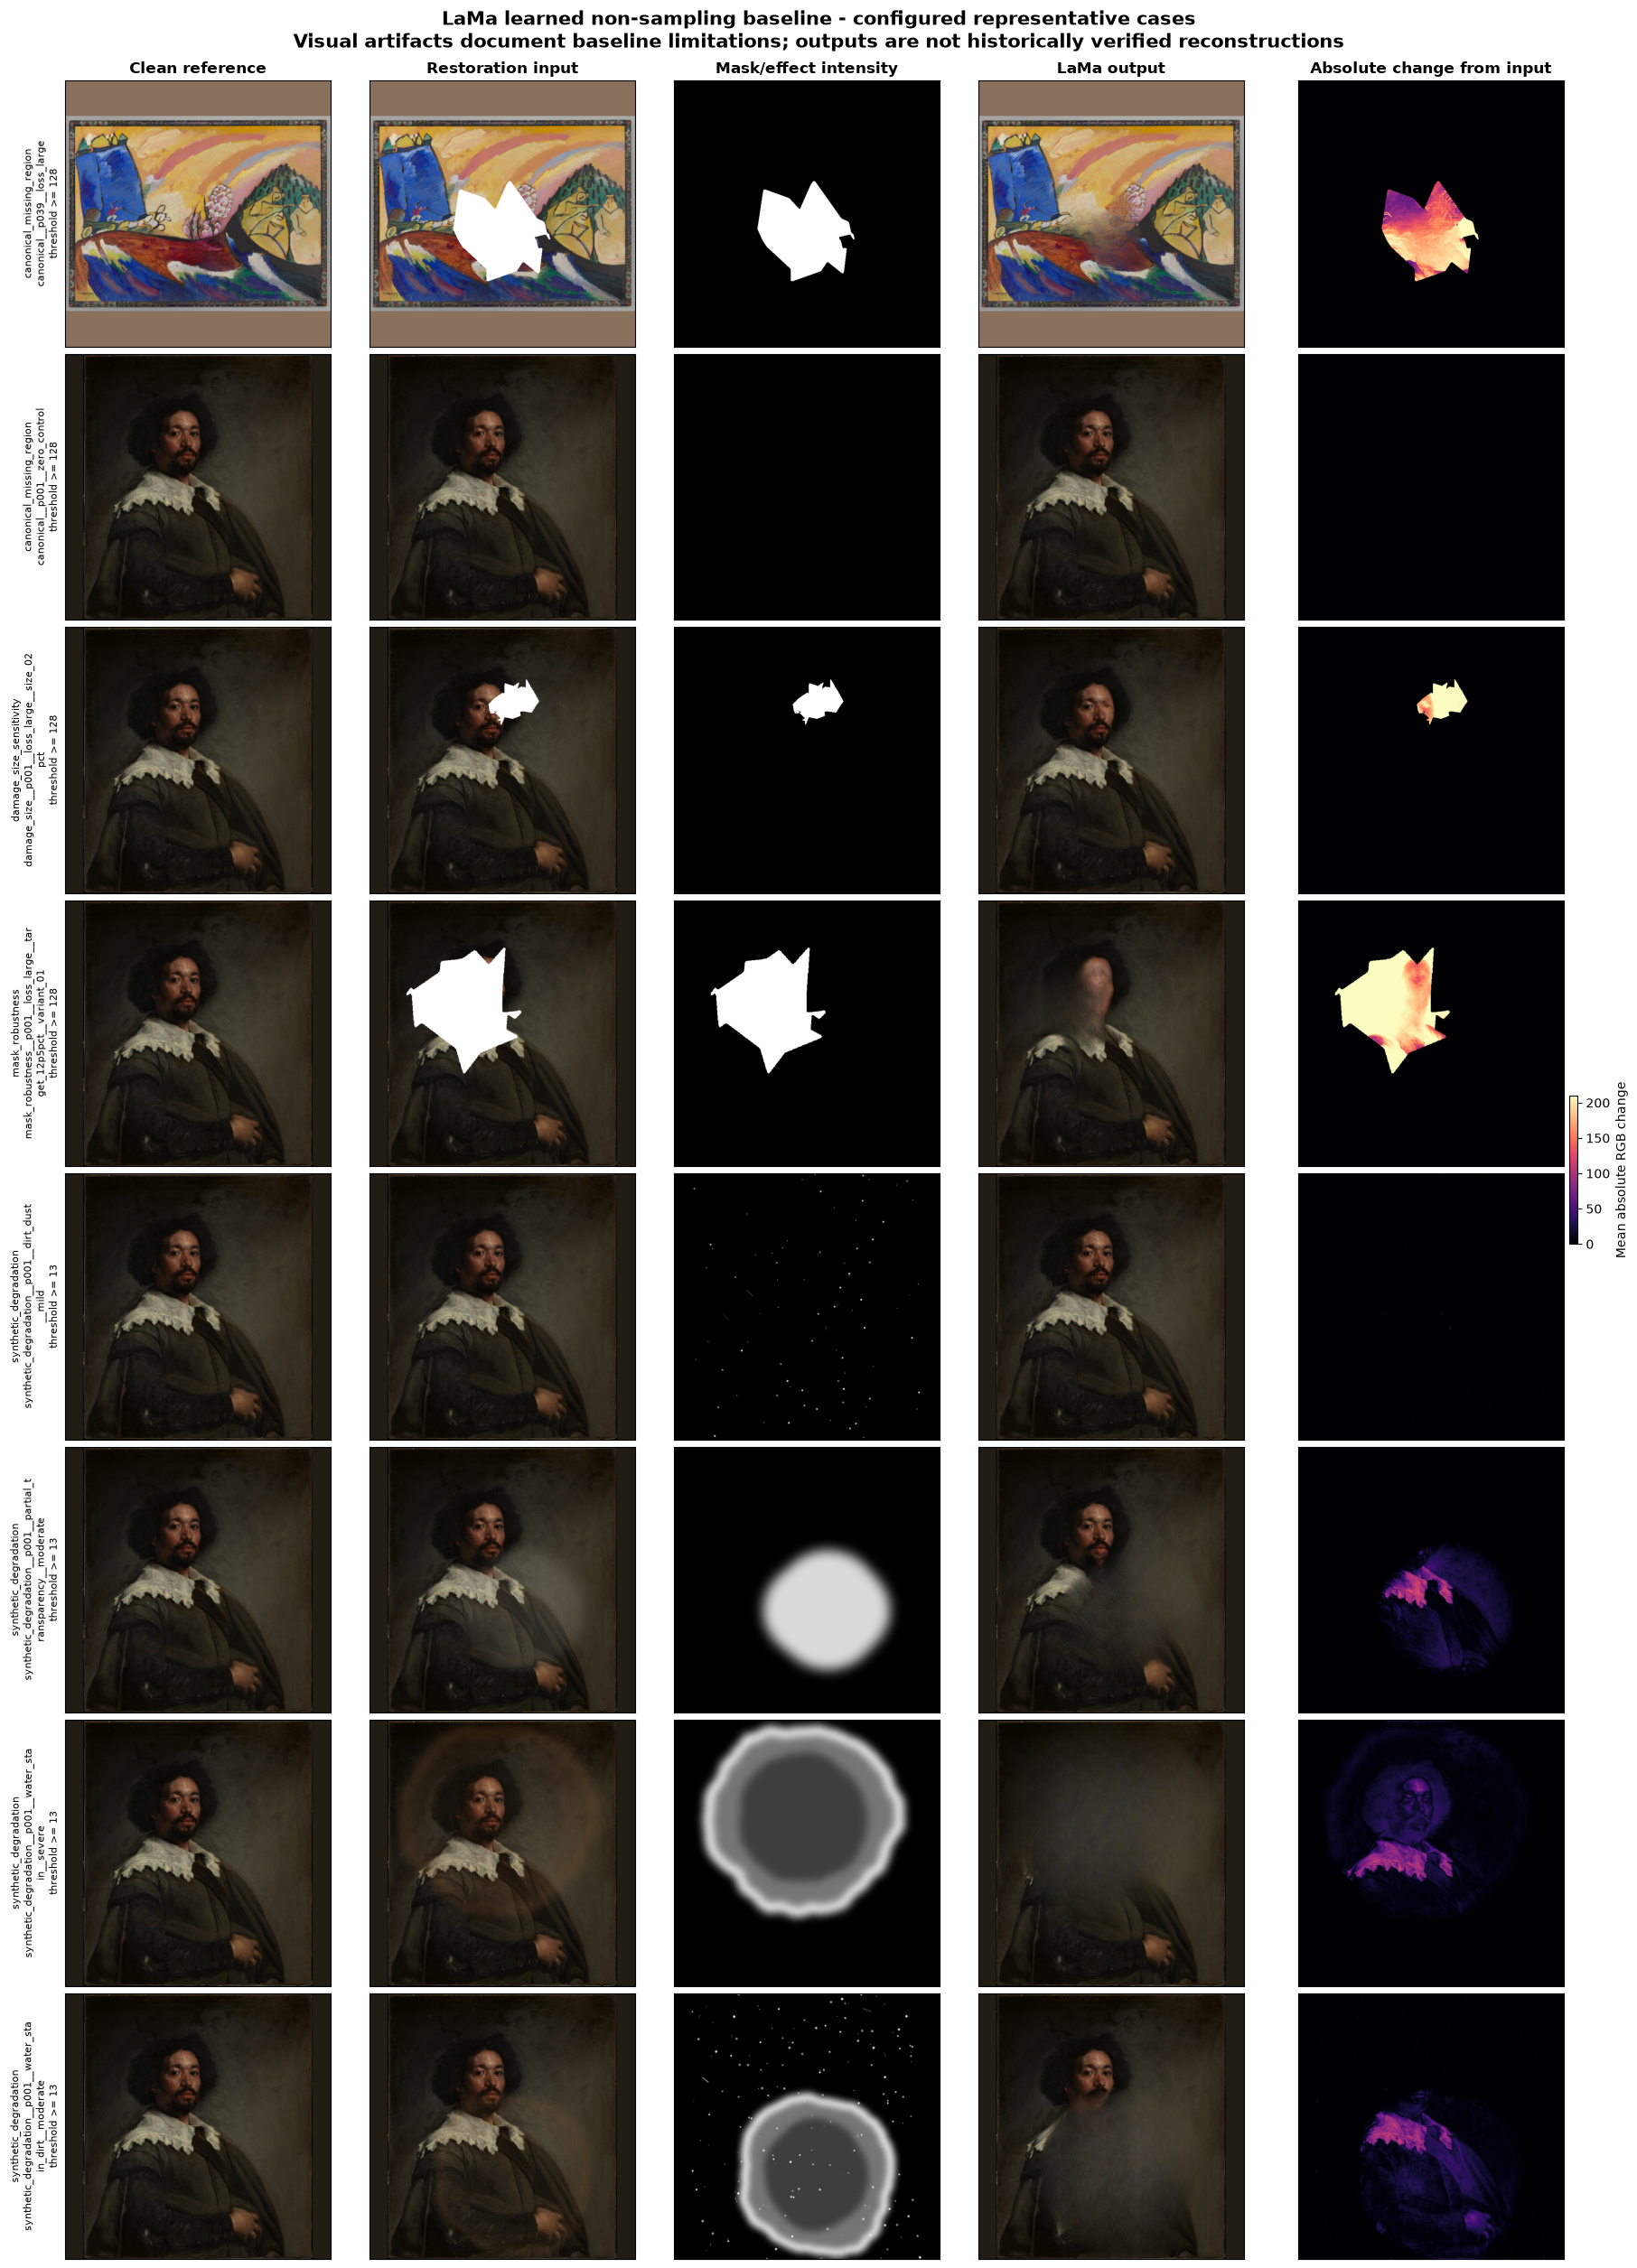

Representative restoration figure persisted.
Path: outputs/10_lama_restoration/figures/restoration_examples.png
Dimensions: (2718, 3767)
Mode: RGBA
Format: PNG
Shared change-map maximum: 210.0


In [21]:
import os
import textwrap


# ---------------------------------------------------------------------------
# Use one shared scale for all absolute-change panels
# ---------------------------------------------------------------------------

representative_change_values = np.concatenate(
    [
        row["input_change"].reshape(-1)
        for row in representative_visual_rows
    ]
)

representative_change_vmax = float(
    np.percentile(
        representative_change_values,
        99.0,
    )
)

representative_change_vmax = max(
    representative_change_vmax,
    1.0,
)


# ---------------------------------------------------------------------------
# Render all eight configured representative cases
# ---------------------------------------------------------------------------

figure, axes = plt.subplots(
    nrows=len(representative_visual_rows),
    ncols=5,
    figsize=(18, 25),
    constrained_layout=True,
)


column_titles = [
    "Clean reference",
    "Restoration input",
    "Mask/effect intensity",
    "LaMa output",
    "Absolute change from input",
]

for column_index, title in enumerate(
    column_titles
):
    axes[
        0,
        column_index,
    ].set_title(
        title,
        fontsize=12,
        fontweight="bold",
    )


difference_artist = None

for row_index, visual_row in enumerate(
    representative_visual_rows
):
    axes[
        row_index,
        0,
    ].imshow(
        visual_row["clean"]
    )

    axes[
        row_index,
        1,
    ].imshow(
        visual_row["input"]
    )

    axes[
        row_index,
        2,
    ].imshow(
        visual_row["mask_or_effect"],
        cmap="gray",
        vmin=0,
        vmax=255,
    )

    axes[
        row_index,
        3,
    ].imshow(
        visual_row["restored"]
    )

    difference_artist = axes[
        row_index,
        4,
    ].imshow(
        visual_row["input_change"],
        cmap="magma",
        vmin=0,
        vmax=representative_change_vmax,
    )

    wrapped_case_id = textwrap.fill(
        str(visual_row["case_id"]),
        width=38,
    )

    row_label = (
        str(visual_row["experiment_id"])
        + "\n"
        + wrapped_case_id
        + "\n"
        + (
            "threshold >= "
            f"{int(visual_row['mask_threshold'])}"
        )
    )

    axes[
        row_index,
        0,
    ].set_ylabel(
        row_label,
        fontsize=8,
    )

    for axis in axes[
        row_index,
        :
    ]:
        axis.set_xticks([])
        axis.set_yticks([])


if difference_artist is None:
    raise RuntimeError(
        "No representative difference "
        "artist was created."
    )


colorbar = figure.colorbar(
    difference_artist,
    ax=axes[:, 4],
    orientation="vertical",
    fraction=0.025,
    pad=0.02,
)

colorbar.set_label(
    "Mean absolute RGB change",
    fontsize=10,
)


figure.suptitle(
    (
        "LaMa learned non-sampling baseline - "
        "configured representative cases\n"
        "Visual artifacts document baseline limitations; "
        "outputs are not historically verified reconstructions"
    ),
    fontsize=15,
    fontweight="bold",
)


# ---------------------------------------------------------------------------
# Atomically persist the canonical figure
# ---------------------------------------------------------------------------

OUTPUTS[
    "restoration_examples"
].parent.mkdir(
    parents=True,
    exist_ok=True,
)

temporary_figure_path = OUTPUTS[
    "restoration_examples"
].with_suffix(
    ".tmp.png"
)

try:
    figure.savefig(
        temporary_figure_path,
        format="png",
        dpi=150,
        facecolor="white",
        bbox_inches="tight",
    )

    os.replace(
        temporary_figure_path,
        OUTPUTS[
            "restoration_examples"
        ],
    )
finally:
    temporary_figure_path.unlink(
        missing_ok=True
    )


plt.show()


# ---------------------------------------------------------------------------
# Reload the saved figure
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUTS["restoration_examples"]
) as saved_figure:
    saved_figure.load()

    restoration_figure_width = (
        saved_figure.width
    )

    restoration_figure_height = (
        saved_figure.height
    )

    restoration_figure_mode = (
        saved_figure.mode
    )

    restoration_figure_format = (
        saved_figure.format
    )


print(
    "Representative restoration figure persisted."
)

print(
    "Path:",
    to_repo_relative(
        OUTPUTS["restoration_examples"],
        PROJECT_ROOT,
    ),
)

print(
    "Dimensions:",
    (
        restoration_figure_width,
        restoration_figure_height,
    ),
)

print(
    "Mode:",
    restoration_figure_mode,
)

print(
    "Format:",
    restoration_figure_format,
)

print(
    "Shared change-map maximum:",
    round(
        representative_change_vmax,
        3,
    ),
)

In [22]:
# ---------------------------------------------------------------------------
# Runtime-summary contract
# ---------------------------------------------------------------------------

overall_runtime_rows_df = (
    reloaded_runtime_summary_df.loc[
        reloaded_runtime_summary_df[
            "summary_scope"
        ]
        .astype(str)
        .eq("overall")
    ]
)

experiment_runtime_rows_df = (
    reloaded_runtime_summary_df.loc[
        reloaded_runtime_summary_df[
            "summary_scope"
        ]
        .astype(str)
        .eq("experiment")
    ]
)


runtime_experiment_counts = {
    str(row["experiment_id"]): int(
        row["case_count"]
    )
    for _, row in (
        experiment_runtime_rows_df.iterrows()
    )
}

expected_runtime_experiment_counts = {
    str(experiment_id): int(case_count)
    for experiment_id, case_count in (
        EXPECTED_COUNTS[
            "eligible_case_count_by_experiment"
        ].items()
    )
}


runtime_numeric_columns = [
    "total_runtime_seconds",
    "mean_runtime_seconds",
    "median_runtime_seconds",
    "p95_runtime_seconds",
    "max_runtime_seconds",
    "throughput_cases_per_second",
]

runtime_numeric_values = (
    reloaded_runtime_summary_df[
        runtime_numeric_columns
    ]
    .apply(
        pd.to_numeric,
        errors="coerce",
    )
)


runtime_values_valid = bool(
    np.isfinite(
        runtime_numeric_values.to_numpy(
            dtype=float
        )
    ).all()
    and runtime_numeric_values
    .ge(0)
    .all()
    .all()
)


overall_runtime_contract_valid = bool(
    len(overall_runtime_rows_df) == 1
    and int(
        overall_runtime_rows_df.iloc[
            0
        ][
            "case_count"
        ]
    )
    == 410
    and int(
        overall_runtime_rows_df.iloc[
            0
        ][
            "completed_count"
        ]
    )
    == 410
    and int(
        overall_runtime_rows_df.iloc[
            0
        ][
            "failed_count"
        ]
    )
    == 0
    and str(
        overall_runtime_rows_df.iloc[
            0
        ][
            "status"
        ]
    )
    == "completed"
)


# ---------------------------------------------------------------------------
# Representative and figure contracts
# ---------------------------------------------------------------------------

representative_experiment_counts = {
    str(experiment_id): int(case_count)
    for experiment_id, case_count in (
        representative_analysis_df[
            "experiment_id"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

expected_representative_experiment_counts = {
    "canonical_missing_region": 2,
    "damage_size_sensitivity": 1,
    "mask_robustness": 1,
    "synthetic_degradation": 4,
}


representative_validation_valid = bool(
    len(representative_analysis_df)
    == EXPECTED_COUNTS[
        "representative_case_count"
    ]
    and representative_analysis_df[
        "validation_passed"
    ]
    .astype(bool)
    .all()
    and pd.to_numeric(
        representative_analysis_df[
            "changed_outside_mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
)


figure_file_valid = bool(
    OUTPUTS[
        "restoration_examples"
    ].is_file()
    and OUTPUTS[
        "restoration_examples"
    ].stat().st_size > 0
    and restoration_figure_format == "PNG"
    and restoration_figure_width >= 1000
    and restoration_figure_height >= 1000
)


observed_metrics_files = set(
    path.resolve()
    for path in OUTPUTS[
        "runtime_summary"
    ].parent.rglob("*")
    if path.is_file()
)

observed_figure_files = set(
    path.resolve()
    for path in OUTPUTS[
        "restoration_examples"
    ].parent.rglob("*")
    if path.is_file()
)

expected_metrics_files = {
    OUTPUTS[
        "runtime_summary"
    ].resolve(),
}

expected_figure_files = {
    OUTPUTS[
        "restoration_examples"
    ].resolve(),
}


runtime_schema_check_passed = bool(
    reloaded_runtime_schema_result.passed
    and len(
        reloaded_runtime_summary_df
    )
    == 5
)

runtime_scope_check_passed = bool(
    len(overall_runtime_rows_df) == 1
    and len(experiment_runtime_rows_df) == 4
    and runtime_experiment_counts
    == expected_runtime_experiment_counts
)

runtime_completion_check_passed = bool(
    overall_runtime_contract_valid
    and runtime_values_valid
)

representative_selection_check_passed = bool(
    len(representative_analysis_df) == 8
    and representative_experiment_counts
    == expected_representative_experiment_counts
    and observed_representative_case_ids
    == representative_case_ids
)

analysis_filesystem_check_passed = bool(
    observed_metrics_files
    == expected_metrics_files
    and observed_figure_files
    == expected_figure_files
)


# ---------------------------------------------------------------------------
# Register Batch 6 checks
# ---------------------------------------------------------------------------

def add_batch_6_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    VALIDATION.add(
        validation_stage=(
            "batch_6_analysis_visualization"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_batch_6_check(
    check_id="runtime_summary_schema",
    description=(
        "The persisted runtime summary "
        "matches its normalized exact schema."
    ),
    expected={
        "schema_valid": True,
        "row_count": 5,
    },
    observed={
        "schema_valid": (
            reloaded_runtime_schema_result.passed
        ),
        "row_count": len(
            reloaded_runtime_summary_df
        ),
    },
    passed=runtime_schema_check_passed,
)


add_batch_6_check(
    check_id="runtime_summary_scopes",
    description=(
        "Runtime evidence contains one overall "
        "row and four experiment rows."
    ),
    expected={
        "overall_rows": 1,
        "experiment_rows": 4,
        "experiment_counts": (
            expected_runtime_experiment_counts
        ),
    },
    observed={
        "overall_rows": len(
            overall_runtime_rows_df
        ),
        "experiment_rows": len(
            experiment_runtime_rows_df
        ),
        "experiment_counts": (
            runtime_experiment_counts
        ),
    },
    passed=runtime_scope_check_passed,
)


add_batch_6_check(
    check_id="runtime_completion_evidence",
    description=(
        "Runtime evidence records all 410 cases "
        "as completed with finite non-negative values."
    ),
    expected={
        "case_count": 410,
        "completed_count": 410,
        "failed_count": 0,
        "runtime_values_valid": True,
    },
    observed={
        "overall_contract_valid": (
            overall_runtime_contract_valid
        ),
        "runtime_values_valid": (
            runtime_values_valid
        ),
    },
    passed=runtime_completion_check_passed,
)


add_batch_6_check(
    check_id="representative_case_selection",
    description=(
        "The preview uses exactly the eight "
        "configured cases across all experiments."
    ),
    expected={
        "case_count": 8,
        "experiment_counts": (
            expected_representative_experiment_counts
        ),
        "ordered_case_ids": (
            representative_case_ids
        ),
    },
    observed={
        "case_count": len(
            representative_analysis_df
        ),
        "experiment_counts": (
            representative_experiment_counts
        ),
        "ordered_case_ids": (
            observed_representative_case_ids
        ),
    },
    passed=representative_selection_check_passed,
)


add_batch_6_check(
    check_id="representative_case_validation",
    description=(
        "Every previewed restoration passed "
        "validation and preserves outside pixels."
    ),
    expected={
        "validated_cases": 8,
        "changed_outside_pixels": 0,
    },
    observed={
        "validated_cases": int(
            representative_analysis_df[
                "validation_passed"
            ]
            .astype(bool)
            .sum()
        ),
        "changed_outside_pixels": int(
            pd.to_numeric(
                representative_analysis_df[
                    "changed_outside_mask_pixels"
                ],
                errors="coerce",
            ).sum()
        ),
    },
    passed=representative_validation_valid,
)


add_batch_6_check(
    check_id="representative_figure_contract",
    description=(
        "The representative figure is a readable, "
        "non-empty, sufficiently detailed PNG."
    ),
    expected={
        "file_exists": True,
        "format": "PNG",
        "minimum_width": 1000,
        "minimum_height": 1000,
    },
    observed={
        "file_exists": OUTPUTS[
            "restoration_examples"
        ].is_file(),
        "file_size_bytes": (
            OUTPUTS[
                "restoration_examples"
            ].stat().st_size
            if OUTPUTS[
                "restoration_examples"
            ].is_file()
            else 0
        ),
        "format": restoration_figure_format,
        "width": restoration_figure_width,
        "height": restoration_figure_height,
        "mode": restoration_figure_mode,
    },
    passed=figure_file_valid,
)


add_batch_6_check(
    check_id="analysis_output_filesystem_scope",
    description=(
        "The metrics and figures directories "
        "contain only the approved Batch 6 outputs."
    ),
    expected={
        "metrics_files": [
            to_repo_relative(
                OUTPUTS[
                    "runtime_summary"
                ],
                PROJECT_ROOT,
            ),
        ],
        "figure_files": [
            to_repo_relative(
                OUTPUTS[
                    "restoration_examples"
                ],
                PROJECT_ROOT,
            ),
        ],
    },
    observed={
        "metrics_files": sorted(
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in observed_metrics_files
        ),
        "figure_files": sorted(
            to_repo_relative(
                path,
                PROJECT_ROOT,
            )
            for path in observed_figure_files
        ),
    },
    passed=analysis_filesystem_check_passed,
)


all_validation_checks_df = (
    VALIDATION.to_dataframe()
)

batch_6_checks_df = (
    all_validation_checks_df.loc[
        all_validation_checks_df[
            "validation_stage"
        ]
        == "batch_6_analysis_visualization"
    ]
    .drop_duplicates(
        subset=["check_id"],
        keep="last",
    )
    .reset_index(drop=True)
)

VALIDATION.raise_for_blocking()


print(
    "Batch 6 validation checks:"
)

display(
    batch_6_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
        ]
)


print(
    "\nFinal runtime summary:"
)

display(
    reloaded_runtime_summary_df
)


print(
    "\nRepresentative-case evidence:"
)

display(
    representative_analysis_df[
        [
            "case_id",
            "experiment_id",
            "mask_threshold",
            "execution_action",
            "runtime_seconds",
            "validation_passed",
        ]
    ]
)


print(
    "\nBatch 6 completed successfully."
)

print(
    "Checks:",
    len(batch_6_checks_df),
)

print(
    "Passed:",
    int(
        batch_6_checks_df[
            "passed"
        ].astype(bool).sum()
    ),
)

print(
    "Runtime-summary rows:",
    len(reloaded_runtime_summary_df),
)

print(
    "Representative cases:",
    len(representative_analysis_df),
)

print(
    "Next approved stage: "
    "Batch 7 - canonical persistence, "
    "manifests, and validation handoff."
)

Batch 6 validation checks:


,check_id,expected,observed,passed
0,runtime_summary_schema,"{""row_count"": 5, ""schema_valid"": true}","{""row_count"": 5, ""schema_valid"": true}",True
1,runtime_summary_scopes,"{""experiment_counts"": {""canonical_missing_regi...","{""experiment_counts"": {""canonical_missing_regi...",True
2,runtime_completion_evidence,"{""case_count"": 410, ""completed_count"": 410, ""f...","{""overall_contract_valid"": true, ""runtime_valu...",True
3,representative_case_selection,"{""case_count"": 8, ""experiment_counts"": {""canon...","{""case_count"": 8, ""experiment_counts"": {""canon...",True
4,representative_case_validation,"{""changed_outside_pixels"": 0, ""validated_cases...","{""changed_outside_pixels"": 0, ""validated_cases...",True
5,representative_figure_contract,"{""file_exists"": true, ""format"": ""PNG"", ""minimu...","{""file_exists"": true, ""file_size_bytes"": 65981...",True
6,analysis_output_filesystem_scope,"{""figure_files"": [""outputs/10_lama_restoration...","{""figure_files"": [""outputs/10_lama_restoration...",True



Final runtime summary:


,summary_scope,experiment_id,case_count,completed_count,failed_count,total_runtime_seconds,mean_runtime_seconds,median_runtime_seconds,p95_runtime_seconds,max_runtime_seconds,throughput_cases_per_second,status
0,overall,all,410,410,0,655.093108,1.597788,1.567178,2.394985,2.394985,0.625865,completed
1,experiment,canonical_missing_region,250,250,0,331.585832,1.326343,1.567178,1.567178,1.567178,0.753953,completed
2,experiment,damage_size_sensitivity,35,35,0,83.824458,2.394985,2.394985,2.394985,2.394985,0.417539,completed
3,experiment,mask_robustness,75,75,0,137.429242,1.832390,1.832390,1.832390,1.832390,0.545735,completed
4,experiment,synthetic_degradation,50,50,0,102.253576,2.045072,2.045072,2.045072,2.045072,0.488980,completed



Representative-case evidence:


,case_id,experiment_id,mask_threshold,execution_action,runtime_seconds,validation_passed
0,canonical__p039__loss_large,canonical_missing_region,128,lama_inpaint,1.567178,True
1,canonical__p001__zero_control,canonical_missing_region,128,identity_noop,0.535234,True
2,damage_size__p001__loss_large__size_02pct,damage_size_sensitivity,128,lama_inpaint,2.394985,True
3,mask_robustness__p001__loss_large__target_12p5...,mask_robustness,128,lama_inpaint,1.832390,True
4,synthetic_degradation__p001__dirt_dust__mild,synthetic_degradation,13,lama_inpaint,2.045072,True
5,synthetic_degradation__p001__partial_transpare...,synthetic_degradation,13,lama_inpaint,2.045072,True
6,synthetic_degradation__p001__water_stain__severe,synthetic_degradation,13,lama_inpaint,2.045072,True
7,synthetic_degradation__p001__water_stain_dirt_...,synthetic_degradation,13,lama_inpaint,2.045072,True



Batch 6 completed successfully.
Checks: 7
Passed: 7
Runtime-summary rows: 5
Representative cases: 8
Next approved stage: Batch 7 - canonical persistence, manifests, and validation handoff.


## Batch 7 - Canonical persistence and provisional handoff

This batch persists and validates the complete downstream-facing Notebook 10 handoff:

- `data/restorations.csv`;
- `images/restored/<experiment_id>/<case_id>.png`;
- `metrics/runtime_summary.csv`;
- `figures/restoration_examples.png`;
- `validation/checks.csv`;
- `manifests/artifacts.csv`;
- `manifests/run_manifest.json`.

The artifact manifest contains five records: restoration records, restored-image directory, runtime summary, representative figure, and validation evidence.

The run manifest remains in a provisional `running` state until Batch 8 completes the roadmap audit, project-path registry update, final manifest transition, and work-directory cleanup.

Checkpoint, staging, command-log, and smoke files remain isolated under `work/`. They are not canonical outputs.

In [23]:
from restoration_eval.manifests import (
    RUN_MANIFEST_SCHEMA_VERSION,
    artifact_records_dataframe,
    build_artifact_record,
    build_run_manifest,
    configuration_checksums,
    sha256_path,
    write_artifact_manifest,
    write_run_manifest,
)

from restoration_eval.schemas import (
    RUN_MANIFEST_REQUIRED_KEYS,
)


# ---------------------------------------------------------------------------
# Approved validation and output cardinalities
# ---------------------------------------------------------------------------

EXPECTED_VALIDATION_STAGE_COUNTS = {
    "batch_1_preflight": 23,
    "batch_2_input_loading": 20,
    "batch_3_smoke_test": 11,
    "batch_4_full_execution": 10,
    "batch_5_scientific_validation": 9,
    "batch_6_analysis_visualization": 7,
}

EXPECTED_CONSOLIDATED_VALIDATION_ROWS = sum(
    EXPECTED_VALIDATION_STAGE_COUNTS.values()
)

EXPECTED_ARTIFACT_RECORD_COUNT = int(
    EXPECTED_COUNTS[
        "artifact_record_count"
    ]
)

EXPECTED_CANONICAL_OUTPUT_FILE_COUNT = int(
    EXPECTED_COUNTS[
        "total_output_file_count_without_failure_logs"
    ]
)


# ---------------------------------------------------------------------------
# Consolidate Batch 1-6 validation evidence
# ---------------------------------------------------------------------------

if not VALIDATION.overall_passed:
    raise RuntimeError(
        "The cumulative Notebook 10 blocking "
        "validation gate has not passed."
    )


validation_checks_df = (
    VALIDATION.to_dataframe()
    .drop_duplicates(
        subset=[
            "validation_stage",
            "check_id",
        ],
        keep="last",
    )
    .reset_index(drop=True)
)


observed_validation_stage_counts = {
    str(validation_stage): int(count)
    for validation_stage, count in (
        validation_checks_df[
            "validation_stage"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

if (
    observed_validation_stage_counts
    != EXPECTED_VALIDATION_STAGE_COUNTS
):
    raise RuntimeError(
        "Consolidated validation-stage counts "
        "do not match the approved Batch 1-6 contract. "
        f"Observed: {observed_validation_stage_counts}"
    )


validation_schema_result = (
    validate_dataframe(
        validation_checks_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not validation_schema_result.passed:
    raise RuntimeError(
        "Consolidated validation evidence does "
        "not match validation_checks.v1."
    )


if (
    len(validation_checks_df)
    != EXPECTED_CONSOLIDATED_VALIDATION_ROWS
):
    raise RuntimeError(
        "Unexpected consolidated validation count: "
        f"{len(validation_checks_df)}."
    )


blocking_failure_mask = (
    validation_checks_df[
        "severity"
    ]
    .astype(str)
    .eq("blocking")
    & ~validation_checks_df[
        "passed"
    ].astype(bool)
)

warning_mask = (
    validation_checks_df[
        "severity"
    ]
    .astype(str)
    .eq("warning")
)

warning_failure_mask = (
    warning_mask
    & ~validation_checks_df[
        "passed"
    ].astype(bool)
)

blocking_validation_passed = bool(
    not blocking_failure_mask.any()
)

warning_check_count = int(
    warning_mask.sum()
)

warning_failure_count = int(
    warning_failure_mask.sum()
)


# ---------------------------------------------------------------------------
# Validate ownership of every declared path
# ---------------------------------------------------------------------------

output_ownership_failures = []

for output_key, output_path in OUTPUTS.items():
    try:
        validated_path = (
            require_notebook_output_path(
                output_path,
                NOTEBOOK_STEM,
                PROJECT_ROOT,
            )
        )

        if (
            validated_path
            != output_path.resolve()
        ):
            output_ownership_failures.append(
                {
                    "output_key": output_key,
                    "path": str(output_path),
                    "issue": (
                        "resolved_path_mismatch"
                    ),
                }
            )

    except Exception as exc:
        output_ownership_failures.append(
            {
                "output_key": output_key,
                "path": str(output_path),
                "issue": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )

if output_ownership_failures:
    raise RuntimeError(
        "One or more Notebook 10 paths violate "
        f"output ownership: {output_ownership_failures}"
    )


# ---------------------------------------------------------------------------
# Persist canonical restoration and validation tables
# ---------------------------------------------------------------------------

canonical_restorations_df = (
    validation_records_df
    .copy()
    .reset_index(drop=True)
)

validate_restoration_records(
    canonical_restorations_df
)


write_dataframe_atomic(
    canonical_restorations_df,
    OUTPUTS["restorations"],
)

write_dataframe_atomic(
    validation_checks_df,
    OUTPUTS["validation_checks"],
)


# ---------------------------------------------------------------------------
# Independently reload every canonical table
# ---------------------------------------------------------------------------

restorations_reloaded_df = pd.read_csv(
    OUTPUTS["restorations"],
    keep_default_na=False,
)

runtime_summary_reloaded_df = pd.read_csv(
    OUTPUTS["runtime_summary"],
    keep_default_na=False,
)

validation_checks_reloaded_df = pd.read_csv(
    OUTPUTS["validation_checks"],
    keep_default_na=False,
)


validate_restoration_records(
    restorations_reloaded_df
)

runtime_summary_reload_result = (
    validate_dataframe(
        runtime_summary_reloaded_df,
        RESTORATION_RUNTIME_SUMMARY_SCHEMA,
        allow_extra_columns=False,
    )
)

validation_checks_reload_result = (
    validate_dataframe(
        validation_checks_reloaded_df,
        VALIDATION_CHECKS_SCHEMA,
        allow_extra_columns=False,
    )
)

if not runtime_summary_reload_result.passed:
    raise RuntimeError(
        "Persisted runtime_summary.csv does "
        "not match its normalized schema."
    )

if not validation_checks_reload_result.passed:
    raise RuntimeError(
        "Persisted checks.csv does not match "
        "validation_checks.v1."
    )


# ---------------------------------------------------------------------------
# Reload representative figure evidence
# ---------------------------------------------------------------------------

with Image.open(
    OUTPUTS["restoration_examples"]
) as persisted_figure:
    persisted_figure.load()

    persisted_figure_evidence = {
        "format": str(
            persisted_figure.format
        ),
        "mode": str(
            persisted_figure.mode
        ),
        "width": int(
            persisted_figure.width
        ),
        "height": int(
            persisted_figure.height
        ),
        "size_bytes": int(
            OUTPUTS[
                "restoration_examples"
            ].stat().st_size
        ),
        "sha256": sha256_file(
            OUTPUTS[
                "restoration_examples"
            ]
        ),
    }


print(
    "Canonical tables persisted and reloaded."
)

print(
    "Restoration rows:",
    len(restorations_reloaded_df),
)

print(
    "Runtime-summary rows:",
    len(runtime_summary_reloaded_df),
)

print(
    "Consolidated validation rows:",
    len(validation_checks_reloaded_df),
)

print(
    "Blocking failures:",
    int(blocking_failure_mask.sum()),
)

print(
    "Warning-severity checks:",
    warning_check_count,
)
print(
    "Failed warning-severity checks:",
    warning_failure_count,
)

print(
    "Validation-stage counts:",
    observed_validation_stage_counts,
)

print(
    "Representative figure:",
    persisted_figure_evidence,
)

Canonical tables persisted and reloaded.
Restoration rows: 410
Runtime-summary rows: 5
Consolidated validation rows: 80
Blocking failures: 0
Warning-severity checks: 1
Failed warning-severity checks: 0
Validation-stage counts: {'batch_1_preflight': 23, 'batch_2_input_loading': 20, 'batch_3_smoke_test': 11, 'batch_4_full_execution': 10, 'batch_5_scientific_validation': 9, 'batch_6_analysis_visualization': 7}
Representative figure: {'format': 'PNG', 'mode': 'RGBA', 'width': 2718, 'height': 3767, 'size_bytes': 6598164, 'sha256': '11c5c4a7d95f1df1cc591bae3b3302d075483d01d24bd0e52b557378d3a04c9b'}


In [24]:
# ---------------------------------------------------------------------------
# Stable identity and reload evidence
# ---------------------------------------------------------------------------

expected_restoration_case_ids = set(
    validation_records_df[
        "case_id"
    ].astype(str)
)

reloaded_restoration_case_ids = set(
    restorations_reloaded_df[
        "case_id"
    ].astype(str)
)


expected_restoration_signatures = {
    str(row["case_id"]): (
        str(row["restored_path"]),
        str(row["restored_sha256"]),
        str(row["status"]),
    )
    for _, row in (
        validation_records_df.iterrows()
    )
}

reloaded_restoration_signatures = {
    str(row["case_id"]): (
        str(row["restored_path"]),
        str(row["restored_sha256"]),
        str(row["status"]),
    )
    for _, row in (
        restorations_reloaded_df.iterrows()
    )
}


expected_validation_keys = {
    (
        str(row["validation_stage"]),
        str(row["check_id"]),
    )
    for _, row in validation_checks_df.iterrows()
}

reloaded_validation_keys = {
    (
        str(row["validation_stage"]),
        str(row["check_id"]),
    )
    for _, row in (
        validation_checks_reloaded_df.iterrows()
    )
}


reloaded_blocking_failure_mask = (
    validation_checks_reloaded_df[
        "severity"
    ]
    .astype(str)
    .eq("blocking")
    & ~validation_checks_reloaded_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

reloaded_blocking_checks_passed = bool(
    not reloaded_blocking_failure_mask.any()
)


# ---------------------------------------------------------------------------
# Canonical restored-image and work scopes
# ---------------------------------------------------------------------------

persisted_restored_files = set(
    path.resolve()
    for path in OUTPUTS[
        "restored_images"
    ].rglob("*")
    if path.is_file()
)

expected_persisted_restored_files = set(
    (
        PROJECT_ROOT
        / str(relative_path)
    ).resolve()
    for relative_path in (
        restorations_reloaded_df[
            "restored_path"
        ].astype(str)
    )
)


WORK_ROOT = (
    OUTPUT_ROOT
    / "work"
).resolve()

observed_work_files = set(
    path.resolve()
    for path in WORK_ROOT.rglob("*")
    if path.is_file()
)

observed_smoke_work_files = set(
    path.resolve()
    for path in OUTPUTS[
        "smoke_directory"
    ].rglob("*")
    if path.is_file()
)

observed_batch_work_files = set(
    path.resolve()
    for path in OUTPUTS[
        "batch_work_directory"
    ].rglob("*")
    if path.is_file()
)

required_work_control_files = {
    OUTPUTS["checkpoint"].resolve(),
    OUTPUTS[
        "batch_runs_checkpoint"
    ].resolve(),
}

temporary_work_files = {
    path
    for path in observed_work_files
    if (
        ".tmp" in path.name.lower()
        or ".staging" in path.name.lower()
        or path.suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
}


EXPECTED_WORK_FILE_COUNT = 1107
EXPECTED_SMOKE_WORK_FILE_COUNT = 13
EXPECTED_BATCH_WORK_FILE_COUNT = 1092


# ---------------------------------------------------------------------------
# Precompute persistence conditions
# ---------------------------------------------------------------------------

output_ownership_check_passed = bool(
    not output_ownership_failures
)

restorations_reload_check_passed = bool(
    len(restorations_reloaded_df) == 410
    and restorations_reloaded_df[
        "case_id"
    ].is_unique
    and reloaded_restoration_case_ids
    == expected_restoration_case_ids
    and reloaded_restoration_signatures
    == expected_restoration_signatures
    and restorations_reloaded_df[
        "status"
    ]
    .astype(str)
    .eq("completed")
    .all()
)

runtime_reload_check_passed = bool(
    runtime_summary_reload_result.passed
    and len(runtime_summary_reloaded_df) == 5
    and runtime_summary_reloaded_df[
        "status"
    ]
    .astype(str)
    .eq("completed")
    .all()
)

validation_reload_check_passed = bool(
    validation_checks_reload_result.passed
    and len(validation_checks_reloaded_df)
    == EXPECTED_CONSOLIDATED_VALIDATION_ROWS
    and reloaded_validation_keys
    == expected_validation_keys
    and reloaded_blocking_checks_passed
)

restored_directory_check_passed = bool(
    len(persisted_restored_files) == 410
    and persisted_restored_files
    == expected_persisted_restored_files
)

figure_reload_check_passed = bool(
    persisted_figure_evidence[
        "format"
    ]
    == "PNG"
    and persisted_figure_evidence[
        "width"
    ]
    >= 1000
    and persisted_figure_evidence[
        "height"
    ]
    >= 1000
    and persisted_figure_evidence[
        "size_bytes"
    ]
    > 0
)

work_isolation_check_passed = bool(
    len(observed_work_files)
    == EXPECTED_WORK_FILE_COUNT
    and len(observed_smoke_work_files)
    == EXPECTED_SMOKE_WORK_FILE_COUNT
    and len(observed_batch_work_files)
    == EXPECTED_BATCH_WORK_FILE_COUNT
    and required_work_control_files.issubset(
        observed_work_files
    )
    and observed_work_files
    == (
        observed_smoke_work_files
        | observed_batch_work_files
        | required_work_control_files
    )
    and not temporary_work_files
)


# ---------------------------------------------------------------------------
# Separate persistence-validation layer
# ---------------------------------------------------------------------------

PERSISTENCE_VALIDATION = ValidationCollector()


def add_persistence_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    PERSISTENCE_VALIDATION.add(
        validation_stage=(
            "canonical_persistence"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_persistence_check(
    check_id="output_path_ownership",
    description=(
        "Every declared Notebook 10 path "
        "resolves inside its owned output root."
    ),
    expected={
        "ownership_failures": 0,
    },
    observed={
        "ownership_failures": len(
            output_ownership_failures
        ),
    },
    passed=output_ownership_check_passed,
    details=output_ownership_failures,
)


add_persistence_check(
    check_id="restorations_csv_reload",
    description=(
        "restorations.csv reloads with all "
        "410 normalized completed records."
    ),
    expected={
        "rows": 410,
        "unique_case_ids": 410,
        "signatures_match": True,
        "completed_rows": 410,
    },
    observed={
        "rows": len(
            restorations_reloaded_df
        ),
        "unique_case_ids": int(
            restorations_reloaded_df[
                "case_id"
            ].nunique()
        ),
        "signatures_match": (
            reloaded_restoration_signatures
            == expected_restoration_signatures
        ),
        "completed_rows": int(
            restorations_reloaded_df[
                "status"
            ]
            .astype(str)
            .eq("completed")
            .sum()
        ),
    },
    passed=restorations_reload_check_passed,
)


add_persistence_check(
    check_id="runtime_summary_csv_reload",
    description=(
        "runtime_summary.csv reloads under "
        "its exact five-row normalized schema."
    ),
    expected={
        "rows": 5,
        "schema_valid": True,
        "completed_status_rows": 5,
    },
    observed={
        "rows": len(
            runtime_summary_reloaded_df
        ),
        "schema_valid": (
            runtime_summary_reload_result.passed
        ),
        "completed_status_rows": int(
            runtime_summary_reloaded_df[
                "status"
            ]
            .astype(str)
            .eq("completed")
            .sum()
        ),
    },
    passed=runtime_reload_check_passed,
)


add_persistence_check(
    check_id="validation_csv_reload",
    description=(
        "checks.csv reloads with all 80 "
        "unique Batch 1-6 checks and no "
        "blocking failure."
    ),
    expected={
        "rows": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
        "schema_valid": True,
        "keys_match": True,
        "blocking_failures": 0,
        "warning_failures": 1,
    },
    observed={
        "rows": len(
            validation_checks_reloaded_df
        ),
        "schema_valid": (
            validation_checks_reload_result.passed
        ),
        "keys_match": (
            reloaded_validation_keys
            == expected_validation_keys
        ),
        "blocking_failures": int(
            reloaded_blocking_failure_mask.sum()
        ),
        "warning_failures": (
            warning_failure_count
        ),
    },
    passed=validation_reload_check_passed,
)


add_persistence_check(
    check_id="restored_image_directory",
    description=(
        "The canonical restored-image directory "
        "contains exactly the 410 paths declared "
        "by restorations.csv."
    ),
    expected={
        "recorded_files": 410,
        "observed_files": 410,
        "exact_set": True,
    },
    observed={
        "recorded_files": len(
            expected_persisted_restored_files
        ),
        "observed_files": len(
            persisted_restored_files
        ),
        "exact_set": (
            persisted_restored_files
            == expected_persisted_restored_files
        ),
    },
    passed=restored_directory_check_passed,
)


add_persistence_check(
    check_id="representative_figure_reload",
    description=(
        "The representative figure reloads "
        "as the validated non-empty PNG."
    ),
    expected={
        "format": "PNG",
        "minimum_width": 1000,
        "minimum_height": 1000,
    },
    observed=persisted_figure_evidence,
    passed=figure_reload_check_passed,
)


add_persistence_check(
    check_id="temporary_work_isolation",
    description=(
        "Smoke, staging, command-log, and "
        "checkpoint files remain isolated under "
        "work/ without partial temporary files."
    ),
    expected={
        "work_files": (
            EXPECTED_WORK_FILE_COUNT
        ),
        "smoke_files": (
            EXPECTED_SMOKE_WORK_FILE_COUNT
        ),
        "batch_files": (
            EXPECTED_BATCH_WORK_FILE_COUNT
        ),
        "control_files": 2,
        "temporary_files": 0,
    },
    observed={
        "work_files": len(
            observed_work_files
        ),
        "smoke_files": len(
            observed_smoke_work_files
        ),
        "batch_files": len(
            observed_batch_work_files
        ),
        "control_files": len(
            required_work_control_files
            & observed_work_files
        ),
        "temporary_files": len(
            temporary_work_files
        ),
    },
    passed=work_isolation_check_passed,
)


persistence_checks_df = (
    PERSISTENCE_VALIDATION.to_dataframe()
)

PERSISTENCE_VALIDATION.raise_for_blocking()


print(
    "Canonical persistence validation passed."
)

display(
    persistence_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "Canonical restored files:",
    len(persisted_restored_files),
)

print(
    "Temporary work files:",
    len(observed_work_files),
)

Canonical persistence validation passed.


,check_id,expected,observed,passed
0,output_path_ownership,"{""ownership_failures"": 0}","{""ownership_failures"": 0}",True
1,restorations_csv_reload,"{""completed_rows"": 410, ""rows"": 410, ""signatur...","{""completed_rows"": 410, ""rows"": 410, ""signatur...",True
2,runtime_summary_csv_reload,"{""completed_status_rows"": 5, ""rows"": 5, ""schem...","{""completed_status_rows"": 5, ""rows"": 5, ""schem...",True
3,validation_csv_reload,"{""blocking_failures"": 0, ""keys_match"": true, ""...","{""blocking_failures"": 0, ""keys_match"": true, ""...",True
4,restored_image_directory,"{""exact_set"": true, ""observed_files"": 410, ""re...","{""exact_set"": true, ""observed_files"": 410, ""re...",True
5,representative_figure_reload,"{""format"": ""PNG"", ""minimum_height"": 1000, ""min...","{""format"": ""PNG"", ""height"": 3767, ""mode"": ""RGB...",True
6,temporary_work_isolation,"{""batch_files"": 1092, ""control_files"": 2, ""smo...","{""batch_files"": 1092, ""control_files"": 2, ""smo...",True


Canonical restored files: 410
Temporary work files: 1107


In [25]:
# ---------------------------------------------------------------------------
# Notebook 10 artifact identity
# ---------------------------------------------------------------------------

DATASET_SCOPE = lama_config[
    "dataset"
][
    "dataset_scope"
]

RUN_EXPERIMENT_ID = lama_config[
    "dataset"
][
    "experiment_id"
]


# ---------------------------------------------------------------------------
# Build the five normalized artifact records
# ---------------------------------------------------------------------------

artifact_specifications = [
    {
        "artifact_key": "lama.restorations",
        "path": OUTPUTS["restorations"],
        "artifact_type": "table",
        "artifact_role": (
            "primary_restoration_records"
        ),
        "schema_version": (
            RESTORATIONS_SCHEMA_VERSION
        ),
        "row_count": 410,
    },
    {
        "artifact_key": "lama.restored_images",
        "path": OUTPUTS["restored_images"],
        "artifact_type": (
            "image_directory"
        ),
        "artifact_role": (
            "primary_restored_images"
        ),
        "schema_version": lama_config[
            "schema_versions"
        ][
            "restored_images"
        ],
        "row_count": 410,
    },
    {
        "artifact_key": "lama.runtime_summary",
        "path": OUTPUTS["runtime_summary"],
        "artifact_type": "table",
        "artifact_role": "runtime_evidence",
        "schema_version": (
            RUNTIME_SUMMARY_SCHEMA_VERSION
        ),
        "row_count": 5,
    },
    {
        "artifact_key": (
            "lama.restoration_examples"
        ),
        "path": OUTPUTS[
            "restoration_examples"
        ],
        "artifact_type": "figure",
        "artifact_role": (
            "representative_visual_evidence"
        ),
        "schema_version": lama_config[
            "schema_versions"
        ][
            "examples_figure"
        ],
        "row_count": 8,
    },
    {
        "artifact_key": (
            "validation."
            "10_lama_restoration"
        ),
        "path": OUTPUTS[
            "validation_checks"
        ],
        "artifact_type": "table",
        "artifact_role": (
            "validation_evidence"
        ),
        "schema_version": (
            VALIDATION_CHECKS_SCHEMA.version
        ),
        "row_count": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
    },
]


artifact_records = [
    build_artifact_record(
        artifact_key=specification[
            "artifact_key"
        ],
        producer_notebook=NOTEBOOK_STEM,
        path=specification["path"],
        artifact_type=specification[
            "artifact_type"
        ],
        artifact_role=specification[
            "artifact_role"
        ],
        schema_version=specification[
            "schema_version"
        ],
        dataset_scope=DATASET_SCOPE,
        experiment_id=RUN_EXPERIMENT_ID,
        validation_status="passed",
        row_count=specification[
            "row_count"
        ],
        project_root=PROJECT_ROOT,
    )
    for specification in artifact_specifications
]


artifact_manifest_df = (
    artifact_records_dataframe(
        artifact_records
    )
)

if (
    len(artifact_manifest_df)
    != EXPECTED_ARTIFACT_RECORD_COUNT
):
    raise RuntimeError(
        "Artifact manifest must contain "
        "exactly five records."
    )


write_artifact_manifest(
    OUTPUTS["artifact_manifest"],
    artifact_records,
)


# ---------------------------------------------------------------------------
# JSON normalization helper
# ---------------------------------------------------------------------------

def to_json_safe(value):
    def convert_value(item):
        if isinstance(item, np.generic):
            return item.item()

        if isinstance(item, Path):
            return str(item)

        return str(item)

    return json.loads(
        json.dumps(
            value,
            ensure_ascii=False,
            default=convert_value,
        )
    )


# ---------------------------------------------------------------------------
# Configuration and upstream provenance
# ---------------------------------------------------------------------------

configuration_path_objects = [
    CONFIG_PATH,
    INPUTS[
        "evaluation_contract_config"
    ],
    INPUTS[
        "synthetic_degradation_config"
    ],
]

configuration_paths = [
    to_repo_relative(
        path,
        PROJECT_ROOT,
    )
    for path in configuration_path_objects
]

configuration_checksums_by_path = (
    configuration_checksums(
        configuration_path_objects,
        PROJECT_ROOT,
    )
)


run_inputs = to_json_safe(
    INPUT_CONTRACT.to_dict(
        orient="records"
    )
)

run_outputs = to_json_safe(
    OUTPUT_CONTRACT.to_dict(
        orient="records"
    )
)


upstream_run_id = str(
    upstream_run_manifest["run_id"]
)

upstream_manifest_checksum = (
    sha256_file(
        INPUTS[
            "upstream_run_manifest"
        ]
    )
)

inventory_checksum = str(
    inventory_run.get(
        "inventory_sha256",
        "",
    )
)

if len(inventory_checksum) != 64:
    raise RuntimeError(
        "inventory_run.json does not contain "
        "a valid inventory SHA-256 value."
    )


# ---------------------------------------------------------------------------
# Expected and observed run counts
# ---------------------------------------------------------------------------

expected_run_counts = to_json_safe(
    {
        **EXPECTED_COUNTS,
        "consolidated_validation_rows": (
            EXPECTED_CONSOLIDATED_VALIDATION_ROWS
        ),
        "blocking_validation_failures": 0,
        "warning_validation_failures": 0,
        "canonical_output_files": (
            EXPECTED_CANONICAL_OUTPUT_FILE_COUNT
        ),
        "temporary_work_files_before_completion": (
            EXPECTED_WORK_FILE_COUNT
        ),
        "iopaint_batch_runs": 4,
    }
)


observed_run_counts = {
    "case_registry_rows": int(
        len(case_registry_df)
    ),
    "model_eligibility_rows": int(
        len(model_eligibility_df)
    ),
    "eligible_case_count": int(
        len(restorations_reloaded_df)
    ),
    "model_inference_case_count": int(
        (
            restorations_reloaded_df[
                "execution_action"
            ]
            .astype(str)
            .eq("lama_inpaint")
        ).sum()
    ),
    "zero_control_case_count": int(
        (
            restorations_reloaded_df[
                "execution_action"
            ]
            .astype(str)
            .eq("identity_noop")
        ).sum()
    ),
    "restored_file_count": int(
        len(persisted_restored_files)
    ),
    "restorations_row_count": int(
        len(restorations_reloaded_df)
    ),
    "runtime_summary_row_count": int(
        len(runtime_summary_reloaded_df)
    ),
    "representative_case_count": int(
        len(representative_analysis_df)
    ),
    "artifact_record_count": int(
        len(artifact_manifest_df)
    ),
    "consolidated_validation_rows": int(
        len(validation_checks_reloaded_df)
    ),
    "blocking_validation_failures": int(
        reloaded_blocking_failure_mask.sum()
    ),
    "warning_validation_failures": (
        warning_failure_count
    ),
    "canonical_output_files": (
        EXPECTED_CANONICAL_OUTPUT_FILE_COUNT
    ),
    "temporary_work_files_before_completion": int(
        len(observed_work_files)
    ),
    "iopaint_batch_runs": int(
        len(full_batch_runs_df)
    ),
}


# ---------------------------------------------------------------------------
# Build the provisional run manifest
# ---------------------------------------------------------------------------

run_manifest = build_run_manifest(
    notebook_id=NOTEBOOK_ID,
    notebook_name=NOTEBOOK_NAME,
    origin=ORIGIN,
    run_status="running",
    started_at_utc=RUN_STARTED_AT_UTC,
    completed_at_utc="",
    inventory_run_id=str(
        inventory_run[
            "inventory_run_id"
        ]
    ),
    dataset_versions={
        "dataset_id": lama_config[
            "dataset"
        ][
            "dataset_id"
        ],
        "dataset_version": lama_config[
            "dataset"
        ][
            "dataset_version"
        ],
        "dataset_scope": DATASET_SCOPE,
        "experiment_id": RUN_EXPERIMENT_ID,
        "configuration_schema": lama_config[
            "config_schema_version"
        ],
        "configuration_version": lama_config[
            "config_version"
        ],
        "configuration_id": lama_config[
            "model"
        ][
            "configuration_id"
        ],
        "methodological_role": lama_config[
            "model"
        ][
            "methodological_role"
        ],
        "implementation": lama_config[
            "model"
        ][
            "implementation"
        ],
        "implementation_source": lama_config[
            "model"
        ][
            "implementation_source"
        ],
        "iopaint_version": (
            lama_runtime_environment[
                "iopaint_version"
            ]
        ),
        "iopaint_model_name": lama_config[
            "model"
        ][
            "iopaint_model_name"
        ],
        "model_revision": lama_config[
            "model"
        ][
            "model_revision"
        ],
        "requested_device": lama_config[
            "model"
        ][
            "requested_device"
        ],
        "effective_device": (
            lama_runtime_environment[
                "effective_device"
            ]
        ),
        "precision": lama_config[
            "model"
        ][
            "precision"
        ],
        "deterministic_non_sampling": lama_config[
            "model"
        ][
            "deterministic"
        ],
        "compositing_policy": lama_config[
            "model"
        ][
            "compositing_policy"
        ],
        "mask_threshold_policy": lama_config[
            "model"
        ][
            "mask_threshold_policy"
        ],
        "repeatability_tolerance": lama_config[
            "smoke"
        ][
            "repeatability_tolerance"
        ],
        "restorations_schema": (
            RESTORATIONS_SCHEMA_VERSION
        ),
        "runtime_summary_schema": (
            RUNTIME_SUMMARY_SCHEMA_VERSION
        ),
        "upstream_notebook": (
            "08_experiment_contracts_"
            "and_region_policy"
        ),
        "upstream_run_id": (
            upstream_run_id
        ),
        "upstream_manifest_checksum": (
            upstream_manifest_checksum
        ),
        "inventory_checksum": (
            inventory_checksum
        ),
        "restoration_helper_sha256": (
            sha256_file(HELPER_PATH)
        ),
        "schemas_helper_sha256": (
            sha256_file(SCHEMAS_PATH)
        ),
        "model_artifact_sha256": (
            lama_runtime_environment[
                "model_artifact_sha256"
            ]
        ),
    },
    configuration_paths=configuration_paths,
    configuration_checksums_by_path=(
        configuration_checksums_by_path
    ),
    helper_versions=HELPER_VERSIONS,
    inputs=run_inputs,
    outputs=run_outputs,
    expected_counts=expected_run_counts,
    observed_counts=observed_run_counts,
    validation_summary={
        "consolidated": (
            VALIDATION.summary()
        ),
        "canonical_persistence": (
            PERSISTENCE_VALIDATION.summary()
        ),
        "manifest_handoff": {
            "status": "pending",
            "passed": False,
        },
        "completion_gate": {
            "status": "pending",
            "passed": False,
        },
    },
    known_limitations=lama_config[
        "known_limitations"
    ],
    project_root=PROJECT_ROOT,
    package_names=(
        "numpy",
        "pandas",
        "Pillow",
        "PyYAML",
        "matplotlib",
        "torch",
        "IOPaint",
    ),
    hardware={
        "execution_device": (
            lama_runtime_environment[
                "effective_device"
            ]
        ),
        "gpu_required": True,
        "cuda_available": (
            lama_runtime_environment[
                "cuda_available"
            ]
        ),
        "cuda_device_count": (
            lama_runtime_environment[
                "cuda_device_count"
            ]
        ),
        "cuda_device_name": (
            lama_runtime_environment[
                "cuda_device_name"
            ]
        ),
        "cuda_runtime_version": (
            lama_runtime_environment[
                "cuda_runtime_version"
            ]
        ),
        "torch_version": (
            lama_runtime_environment[
                "torch_version"
            ]
        ),
        "execution_backend": lama_config[
            "model"
        ][
            "execution_backend"
        ],
        "cpu_environment": str(
            restorations_reloaded_df.iloc[
                0
            ][
                "cpu_environment"
            ]
        ),
    },
)


# ---------------------------------------------------------------------------
# Notebook-specific provisional state
# ---------------------------------------------------------------------------

run_manifest.update(
    {
        "refactor_status": (
            "refactored_pending_completion_gate"
        ),
        "validation_status": "passed_pending_completion_gate",
        "depends_on": [
            (
                "experiment_contracts."
                "case_registry"
            ),
            (
                "experiment_contracts."
                "model_eligibility"
            ),
            (
                "experiment_contracts."
                "schema_registry"
            ),
            (
                "08_experiment_contracts_"
                "and_region_policy.run_manifest"
            ),
            "lama_config",
            "current_inventory",
            "project_paths_registry",
        ],
        "applicable_dataset_scopes": [
            DATASET_SCOPE,
        ],
        "applicable_experiment_scopes": [
            "canonical_missing_region",
            "damage_size_sensitivity",
            "mask_robustness",
            "synthetic_degradation",
            RUN_EXPERIMENT_ID,
        ],
        "expensive_execution": True,
        "completion_gate_passed": False,
    }
)


RUN_ID = str(
    run_manifest["run_id"]
)


write_run_manifest(
    OUTPUTS["run_manifest"],
    run_manifest,
)


print(
    "Artifact and provisional run "
    "manifests written."
)

print(
    "Artifact records:",
    len(artifact_manifest_df),
)

print(
    "Inventory checksum:",
    inventory_checksum,
)

print(
    "Run ID:",
    RUN_ID,
)

print(
    "Run status:",
    run_manifest[
        "run_status"
    ],
)

print(
    "Completion gate passed:",
    run_manifest[
        "completion_gate_passed"
    ],
)

Artifact and provisional run manifests written.
Artifact records: 5
Inventory checksum: 68a6329f805244d662183217ca8c7e265f400e0e1528f112bebd6713ca2050f6
Run ID: run_25e38d80461643fb91ba60cb551a9a2f
Run status: running
Completion gate passed: False


In [26]:
# ---------------------------------------------------------------------------
# Reload both normalized manifests
# ---------------------------------------------------------------------------

artifact_manifest_reloaded_df = pd.read_csv(
    OUTPUTS["artifact_manifest"],
    keep_default_na=False,
)

with OUTPUTS[
    "run_manifest"
].open(
    "r",
    encoding="utf-8",
) as run_manifest_file:
    run_manifest_reloaded = json.load(
        run_manifest_file
    )


artifact_manifest_reload_result = (
    validate_dataframe(
        artifact_manifest_reloaded_df,
        ARTIFACT_MANIFEST_SCHEMA,
        allow_extra_columns=False,
    )
)


# ---------------------------------------------------------------------------
# Artifact-manifest evidence
# ---------------------------------------------------------------------------

expected_artifact_keys = {
    "lama.restorations",
    "lama.restored_images",
    "lama.runtime_summary",
    "lama.restoration_examples",
    "validation.10_lama_restoration",
}

observed_artifact_keys = set(
    artifact_manifest_reloaded_df[
        "artifact_key"
    ].astype(str)
)


artifact_path_failures = []
artifact_checksum_failures = []

for artifact_row in (
    artifact_manifest_reloaded_df
    .itertuples(index=False)
):
    try:
        artifact_path = (
            PROJECT_ROOT
            / str(
                artifact_row.relative_path
            )
        ).resolve()

        if not artifact_path.exists():
            raise FileNotFoundError(
                artifact_path
            )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_artifact_checksum = (
            sha256_path(
                artifact_path
            )
        )

        if (
            observed_artifact_checksum
            != str(
                artifact_row.checksum
            )
        ):
            artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected_checksum": (
                        artifact_row.checksum
                    ),
                    "observed_checksum": (
                        observed_artifact_checksum
                    ),
                }
            )

    except Exception as exc:
        artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "relative_path": (
                    artifact_row.relative_path
                ),
                "issue": (
                    f"{type(exc).__name__}: {exc}"
                ),
            }
        )


# ---------------------------------------------------------------------------
# Provisional run-manifest evidence
# ---------------------------------------------------------------------------

run_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(run_manifest_reloaded)
)

run_manifest_matches_memory = bool(
    run_manifest_reloaded
    == to_json_safe(run_manifest)
)

run_manifest_state_valid = bool(
    not run_manifest_missing_keys
    and run_manifest_matches_memory
    and run_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and run_manifest_reloaded[
        "run_status"
    ]
    == "running"
    and run_manifest_reloaded[
        "completed_at_utc"
    ]
    == ""
    and run_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and run_manifest_reloaded[
        "inventory_run_id"
    ]
    == str(
        inventory_run[
            "inventory_run_id"
        ]
    )
    and run_manifest_reloaded[
        "completion_gate_passed"
    ]
    is False
)


# ---------------------------------------------------------------------------
# Exact canonical 416-file output contract
# ---------------------------------------------------------------------------

expected_canonical_output_paths = (
    expected_persisted_restored_files
    | {
        OUTPUTS["restorations"].resolve(),
        OUTPUTS["runtime_summary"].resolve(),
        OUTPUTS[
            "restoration_examples"
        ].resolve(),
        OUTPUTS["run_manifest"].resolve(),
        OUTPUTS[
            "artifact_manifest"
        ].resolve(),
        OUTPUTS[
            "validation_checks"
        ].resolve(),
    }
)


observed_canonical_output_paths = set()

for observed_path in OUTPUT_ROOT.rglob("*"):
    if not observed_path.is_file():
        continue

    relative_output_path = (
        observed_path.resolve()
        .relative_to(
            OUTPUT_ROOT.resolve()
        )
    )

    if (
        relative_output_path.parts
        and relative_output_path.parts[0]
        == "work"
    ):
        continue

    observed_canonical_output_paths.add(
        observed_path.resolve()
    )


missing_canonical_output_paths = (
    expected_canonical_output_paths
    - observed_canonical_output_paths
)

undeclared_canonical_output_paths = (
    observed_canonical_output_paths
    - expected_canonical_output_paths
)

temporary_canonical_output_paths = {
    path
    for path in observed_canonical_output_paths
    if (
        ".tmp" in path.name.lower()
        or ".staging" in path.name.lower()
        or path.suffix.lower()
        in {
            ".temp",
            ".part",
        }
    )
}


exact_canonical_output_set_valid = bool(
    len(observed_canonical_output_paths)
    == EXPECTED_CANONICAL_OUTPUT_FILE_COUNT
    and observed_canonical_output_paths
    == expected_canonical_output_paths
    and not missing_canonical_output_paths
    and not undeclared_canonical_output_paths
    and not temporary_canonical_output_paths
)

artifact_manifest_contract_valid = bool(
    artifact_manifest_reload_result.passed
    and len(
        artifact_manifest_reloaded_df
    )
    == EXPECTED_ARTIFACT_RECORD_COUNT
    and observed_artifact_keys
    == expected_artifact_keys
    and artifact_manifest_reloaded_df[
        "validation_status"
    ]
    .astype(str)
    .eq("passed")
    .all()
)

artifact_integrity_valid = bool(
    not artifact_path_failures
    and not artifact_checksum_failures
)

work_noncanonical_valid = bool(
    len(observed_work_files)
    == EXPECTED_WORK_FILE_COUNT
    and not (
        observed_work_files
        & observed_canonical_output_paths
    )
)


# ---------------------------------------------------------------------------
# Separate manifest-handoff validation layer
# ---------------------------------------------------------------------------

MANIFEST_HANDOFF_VALIDATION = (
    ValidationCollector()
)


def add_manifest_handoff_check(
    *,
    check_id,
    description,
    expected,
    observed,
    passed,
    details="",
):
    MANIFEST_HANDOFF_VALIDATION.add(
        validation_stage=(
            "manifest_handoff"
        ),
        check_id=check_id,
        check_description=description,
        severity="blocking",
        expected=expected,
        observed=observed,
        passed=passed,
        details=details,
    )


add_manifest_handoff_check(
    check_id="artifact_manifest_contract",
    description=(
        "artifacts.csv satisfies its schema "
        "and contains five declared artifacts."
    ),
    expected={
        "records": 5,
        "artifact_keys": sorted(
            expected_artifact_keys
        ),
        "schema_valid": True,
    },
    observed={
        "records": len(
            artifact_manifest_reloaded_df
        ),
        "artifact_keys": sorted(
            observed_artifact_keys
        ),
        "schema_valid": (
            artifact_manifest_reload_result.passed
        ),
    },
    passed=artifact_manifest_contract_valid,
)


add_manifest_handoff_check(
    check_id="artifact_paths_and_checksums",
    description=(
        "Every artifact exists inside Notebook 10 "
        "and matches its recorded checksum."
    ),
    expected={
        "path_failures": 0,
        "checksum_failures": 0,
    },
    observed={
        "path_failures": len(
            artifact_path_failures
        ),
        "checksum_failures": len(
            artifact_checksum_failures
        ),
    },
    passed=artifact_integrity_valid,
    details={
        "path_failures": (
            artifact_path_failures
        ),
        "checksum_failures": (
            artifact_checksum_failures
        ),
    },
)


add_manifest_handoff_check(
    check_id="provisional_run_manifest",
    description=(
        "run_manifest.json reloads under "
        "run_manifest.v1 with its stable "
        "provisional state."
    ),
    expected={
        "missing_required_keys": 0,
        "run_status": "running",
        "completion_gate_passed": False,
        "matches_memory": True,
    },
    observed={
        "missing_required_keys": (
            run_manifest_missing_keys
        ),
        "run_status": (
            run_manifest_reloaded.get(
                "run_status"
            )
        ),
        "completion_gate_passed": (
            run_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "matches_memory": (
            run_manifest_matches_memory
        ),
    },
    passed=run_manifest_state_valid,
)


add_manifest_handoff_check(
    check_id="exact_canonical_output_set",
    description=(
        "The Notebook 10 output root contains "
        "exactly 416 canonical files outside work/."
    ),
    expected={
        "canonical_files": 416,
        "missing_files": 0,
        "undeclared_files": 0,
        "temporary_files": 0,
    },
    observed={
        "canonical_files": len(
            observed_canonical_output_paths
        ),
        "missing_files": len(
            missing_canonical_output_paths
        ),
        "undeclared_files": len(
            undeclared_canonical_output_paths
        ),
        "temporary_files": len(
            temporary_canonical_output_paths
        ),
    },
    passed=exact_canonical_output_set_valid,
    details={
        "missing_files": sorted(
            str(path)
            for path in (
                missing_canonical_output_paths
            )
        ),
        "undeclared_files": sorted(
            str(path)
            for path in (
                undeclared_canonical_output_paths
            )
        ),
        "temporary_files": sorted(
            str(path)
            for path in (
                temporary_canonical_output_paths
            )
        ),
    },
)


add_manifest_handoff_check(
    check_id="work_files_remain_noncanonical",
    description=(
        "All temporary execution evidence remains "
        "isolated under work/ and excluded from the "
        "canonical output count."
    ),
    expected={
        "work_files": (
            EXPECTED_WORK_FILE_COUNT
        ),
        "canonical_files": (
            EXPECTED_CANONICAL_OUTPUT_FILE_COUNT
        ),
        "overlap": 0,
    },
    observed={
        "work_files": len(
            observed_work_files
        ),
        "canonical_files": len(
            observed_canonical_output_paths
        ),
        "overlap": len(
            observed_work_files
            & observed_canonical_output_paths
        ),
    },
    passed=work_noncanonical_valid,
)


manifest_handoff_checks_df = (
    MANIFEST_HANDOFF_VALIDATION
    .to_dataframe()
)

MANIFEST_HANDOFF_VALIDATION.raise_for_blocking()


print(
    "Manifest handoff validation passed."
)

display(
    manifest_handoff_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)


print(
    "\nCanonical artifact manifest:"
)

display(
    artifact_manifest_reloaded_df
)


print(
    "\nCanonical output summary:"
)

display(
    pd.DataFrame(
        [
            {
                "scope": "canonical",
                "file_count": len(
                    observed_canonical_output_paths
                ),
                "expected_count": (
                    EXPECTED_CANONICAL_OUTPUT_FILE_COUNT
                ),
                "status": (
                    "passed"
                    if exact_canonical_output_set_valid
                    else "failed"
                ),
            },
            {
                "scope": "temporary_work",
                "file_count": len(
                    observed_work_files
                ),
                "expected_count": (
                    EXPECTED_WORK_FILE_COUNT
                ),
                "status": (
                    "isolated"
                    if work_noncanonical_valid
                    else "failed"
                ),
            },
        ]
    )
)


print(
    "\nBatch 7 completed successfully."
)

print(
    "Consolidated scientific checks:",
    len(validation_checks_reloaded_df),
)

print(
    "Persistence checks:",
    len(persistence_checks_df),
)

print(
    "Manifest-handoff checks:",
    len(manifest_handoff_checks_df),
)

print(
    "Artifact records:",
    len(
        artifact_manifest_reloaded_df
    ),
)

print(
    "Canonical output files:",
    len(
        observed_canonical_output_paths
    ),
)

print(
    "Provisional run status:",
    run_manifest_reloaded[
        "run_status"
    ],
)

print(
    "Next approved stage: "
    "Batch 8 - roadmap completion gate, "
    "completed run manifest, project-path "
    "registry update, and work cleanup."
)

Manifest handoff validation passed.


,check_id,expected,observed,passed
0,artifact_manifest_contract,"{""artifact_keys"": [""lama.restoration_examples""...","{""artifact_keys"": [""lama.restoration_examples""...",True
1,artifact_paths_and_checksums,"{""checksum_failures"": 0, ""path_failures"": 0}","{""checksum_failures"": 0, ""path_failures"": 0}",True
2,provisional_run_manifest,"{""completion_gate_passed"": false, ""matches_mem...","{""completion_gate_passed"": false, ""matches_mem...",True
3,exact_canonical_output_set,"{""canonical_files"": 416, ""missing_files"": 0, ""...","{""canonical_files"": 416, ""missing_files"": 0, ""...",True
4,work_files_remain_noncanonical,"{""canonical_files"": 416, ""overlap"": 0, ""work_f...","{""canonical_files"": 416, ""overlap"": 0, ""work_f...",True



Canonical artifact manifest:


,artifact_id,artifact_key,producer_notebook,artifact_type,artifact_role,relative_path,format,dataset_scope,experiment_id,schema_version,row_count,file_count,size_bytes,checksum,validation_status
0,artifact_c7fa0c7980e76cbcc1c7,lama.restorations,10_lama_restoration,table,primary_restoration_records,outputs/10_lama_restoration/data/restorations.csv,csv,controlled_50,cross_experiment_lama,restorations.v1,410,1,457518,327ea28eedfb5ba7056b032ae76a5ee08252a365562576...,passed
1,artifact_e50f78945d3f48b3e974,lama.restored_images,10_lama_restoration,image_directory,primary_restored_images,outputs/10_lama_restoration/images/restored,directory,controlled_50,cross_experiment_lama,restored_images.lama.v1,410,410,291403474,5b49e40c4ab3fb93ea547ace6adf24da09283d1d2d1189...,passed
2,artifact_b27e749c8e406343fcbc,lama.runtime_summary,10_lama_restoration,table,runtime_evidence,outputs/10_lama_restoration/metrics/runtime_su...,csv,controlled_50,cross_experiment_lama,restoration_runtime_summary.v1,5,1,1009,dcbf17cca2e1ffceb18637dba75c884f789e1aa2dbe4d5...,passed
3,artifact_1c430e364cb4290ac017,lama.restoration_examples,10_lama_restoration,figure,representative_visual_evidence,outputs/10_lama_restoration/figures/restoratio...,png,controlled_50,cross_experiment_lama,figure.restoration_examples.v1,8,1,6598164,11c5c4a7d95f1df1cc591bae3b3302d075483d01d24bd0...,passed
4,artifact_2c82ba6e889f5995f927,validation.10_lama_restoration,10_lama_restoration,table,validation_evidence,outputs/10_lama_restoration/validation/checks.csv,csv,controlled_50,cross_experiment_lama,validation_checks.v1,80,1,28732,b02928fe7c3e566a1f19310614ec365304e9ca201c9a83...,passed



Canonical output summary:


,scope,file_count,expected_count,status
0,canonical,416,416,passed
1,temporary_work,1107,1107,isolated



Batch 7 completed successfully.
Consolidated scientific checks: 80
Persistence checks: 7
Manifest-handoff checks: 5
Artifact records: 5
Canonical output files: 416
Provisional run status: running
Next approved stage: Batch 8 - roadmap completion gate, completed run manifest, project-path registry update, and work cleanup.


## Batch 8 - Final completion gate and project registry

This batch performs the final Notebook 10 completion audit.

It:

- maps every Notebook 10 roadmap responsibility to implementation evidence;
- verifies all 410 LaMa-eligible cases and the four experiment branches;
- verifies model, implementation, IOPaint, device, runtime, retry, command, and batch provenance;
- confirms normalized staging, mask-threshold routing, zero-control handling, output geometry, and outside-mask preservation;
- verifies resumable execution and explicit failure handling;
- verifies the final normalized tables, restored images, representative figure, validation evidence, and manifests;
- updates the global JSON and Markdown project-path registries with five validated Notebook 10 artifacts;
- preserves batch-command evidence in the completed run manifest;
- removes the validated 1,107 temporary files from `work/`;
- preserves the canonical 416-file output set;
- changes the run manifest from `running` to `completed`;
- records the expected non-blocking model-artifact-checksum warning.

The notebook header status and global project inventory are updated only after this batch has passed and the notebook has been saved.

In [27]:
# ---------------------------------------------------------------------------
# Independently reload the complete Notebook 10 handoff
# ---------------------------------------------------------------------------

final_restorations_df = pd.read_csv(
    OUTPUTS["restorations"],
    keep_default_na=False,
)

final_runtime_summary_df = pd.read_csv(
    OUTPUTS["runtime_summary"],
    keep_default_na=False,
)

final_validation_df = pd.read_csv(
    OUTPUTS["validation_checks"],
    keep_default_na=False,
)

final_artifact_manifest_df = pd.read_csv(
    OUTPUTS["artifact_manifest"],
    keep_default_na=False,
)

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8",
) as manifest_file:
    final_precompletion_run_manifest = json.load(
        manifest_file
    )


# ---------------------------------------------------------------------------
# Exact schema validation
# ---------------------------------------------------------------------------

validate_restoration_records(
    final_restorations_df
)

final_runtime_schema_result = validate_dataframe(
    final_runtime_summary_df,
    RESTORATION_RUNTIME_SUMMARY_SCHEMA,
    allow_extra_columns=False,
)

final_validation_schema_result = validate_dataframe(
    final_validation_df,
    VALIDATION_CHECKS_SCHEMA,
    allow_extra_columns=False,
)

final_artifact_schema_result = validate_dataframe(
    final_artifact_manifest_df,
    ARTIFACT_MANIFEST_SCHEMA,
    allow_extra_columns=False,
)


# ---------------------------------------------------------------------------
# Restoration identity and experiment coverage
# ---------------------------------------------------------------------------

final_restoration_context_df = (
    final_restorations_df
    .merge(
        execution_worklist_df[
            [
                "case_id",
                "experiment_id",
                "planned_restored_path",
            ]
        ],
        on="case_id",
        how="left",
        validate="one_to_one",
    )
)

final_experiment_counts = {
    str(experiment_id): int(case_count)
    for experiment_id, case_count in (
        final_restoration_context_df[
            "experiment_id"
        ]
        .value_counts()
        .sort_index()
        .items()
    )
}

expected_final_experiment_counts = {
    str(experiment_id): int(case_count)
    for experiment_id, case_count in EXPECTED_COUNTS[
        "eligible_case_count_by_experiment"
    ].items()
}

final_case_identity_valid = bool(
    len(final_restorations_df) == 410
    and final_restorations_df[
        "case_id"
    ].is_unique
    and set(
        final_restorations_df[
            "case_id"
        ].astype(str)
    )
    == set(
        execution_worklist_df[
            "case_id"
        ].astype(str)
    )
)

final_model_identity_valid = bool(
    final_restorations_df[
        "model_id"
    ]
    .astype(str)
    .eq(
        lama_config["model"]["model_id"]
    )
    .all()
    and final_restorations_df[
        "configuration_id"
    ]
    .astype(str)
    .eq(
        lama_config["model"][
            "configuration_id"
        ]
    )
    .all()
    and final_restorations_df[
        "model_revision"
    ]
    .astype(str)
    .eq(
        lama_config["model"]["model_revision"]
    )
    .all()
    and final_restorations_df[
        "iopaint_version"
    ]
    .astype(str)
    .str.len()
    .gt(0)
    .all()
)

final_execution_metadata_valid = bool(
    fixed_metadata_valid
    and batch_provenance_valid
    and batch_command_text_valid
    and batch_command_logs_valid
    and final_restorations_df[
        "device"
    ]
    .astype(str)
    .eq(
        lama_runtime_environment[
            "effective_device"
        ]
    )
    .all()
    and final_restorations_df[
        "precision"
    ]
    .astype(str)
    .eq(
        lama_config["model"]["precision"]
    )
    .all()
    and final_restorations_df[
        "execution_backend"
    ]
    .astype(str)
    .eq(
        lama_config["model"][
            "execution_backend"
        ]
    )
    .all()
    and final_restorations_df[
        "cpu_environment"
    ]
    .astype(str)
    .str.len()
    .gt(0)
    .all()
    and pd.to_numeric(
        final_restorations_df[
            "runtime_seconds"
        ],
        errors="coerce",
    )
    .ge(0)
    .all()
    and pd.to_numeric(
        final_restorations_df[
            "retry_count"
        ],
        errors="coerce",
    )
    .between(
        0,
        int(
            lama_config["model"][
                "maximum_retries"
            ]
        ),
        inclusive="both",
    )
    .all()
)

final_zero_control_df = (
    final_restorations_df.loc[
        final_restorations_df[
            "execution_action"
        ]
        .astype(str)
        .eq("identity_noop")
    ]
)

final_zero_control_valid = bool(
    len(final_zero_control_df) == 50
    and zero_control_identity_valid
    and final_zero_control_df[
        "restored_sha256"
    ]
    .astype(str)
    .eq(
        final_zero_control_df[
            "input_sha256"
        ].astype(str)
    )
    .all()
)

final_resume_evidence_valid = bool(
    bool(
        lama_config["execution"][
            "resume_enabled"
        ]
    )
    and checkpoint_signature
    == execution_signature
    and batch_checkpoint_signature
    == batch_memory_signature
    and OUTPUTS["checkpoint"].is_file()
    and OUTPUTS[
        "batch_runs_checkpoint"
    ].is_file()
)

final_failure_visibility_valid = bool(
    len(final_restorations_df) == 410
    and "issue" in final_restorations_df.columns
    and final_restorations_df[
        "status"
    ]
    .astype(str)
    .eq("completed")
    .all()
    and len(
        failure_records_df
    )
    == 0
    and len(
        failed_batch_runs_df
    )
    == 0
    and failure_log_retention_valid
)

final_staging_contract_valid = bool(
    planned_path_contract_passed
    and not legacy_generated_input_references
    and lama_config["execution"][
        "staging_link_mode"
    ]
    == "hardlink_with_copy_fallback"
    and all(
        path.resolve()
        not in expected_canonical_output_paths
        for path in observed_work_files
    )
)


# ---------------------------------------------------------------------------
# Artifact and canonical-file integrity
# ---------------------------------------------------------------------------

final_artifact_path_failures = []
final_artifact_checksum_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(index=False)
):
    try:
        artifact_path = (
            PROJECT_ROOT
            / str(
                artifact_row.relative_path
            )
        ).resolve()

        if not artifact_path.exists():
            raise FileNotFoundError(
                artifact_path
            )

        require_notebook_output_path(
            artifact_path,
            NOTEBOOK_STEM,
            PROJECT_ROOT,
        )

        observed_checksum = sha256_path(
            artifact_path
        )

        if (
            observed_checksum
            != str(
                artifact_row.checksum
            )
        ):
            final_artifact_checksum_failures.append(
                {
                    "artifact_key": (
                        artifact_row.artifact_key
                    ),
                    "expected": str(
                        artifact_row.checksum
                    ),
                    "observed": (
                        observed_checksum
                    ),
                }
            )

    except Exception as exc:
        final_artifact_path_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "issue": (
                    f"{type(exc).__name__}: "
                    f"{exc}"
                ),
            }
        )

final_canonical_output_paths = set()

for output_path in OUTPUT_ROOT.rglob("*"):
    if not output_path.is_file():
        continue

    relative_output_path = (
        output_path.resolve()
        .relative_to(
            OUTPUT_ROOT.resolve()
        )
    )

    if (
        relative_output_path.parts
        and relative_output_path.parts[0]
        == "work"
    ):
        continue

    final_canonical_output_paths.add(
        output_path.resolve()
    )

final_canonical_output_set_valid = bool(
    final_canonical_output_paths
    == expected_canonical_output_paths
    and len(final_canonical_output_paths)
    == 416
)


# ---------------------------------------------------------------------------
# Persisted validation and visual evidence
# ---------------------------------------------------------------------------

final_blocking_failure_mask = (
    final_validation_df[
        "severity"
    ]
    .astype(str)
    .eq("blocking")
    & ~final_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

final_warning_failure_mask = (
    final_validation_df[
        "severity"
    ]
    .astype(str)
    .eq("warning")
    & ~final_validation_df[
        "passed"
    ]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("true")
)

final_validation_passed = bool(
    final_validation_schema_result.passed
    and len(final_validation_df) == 80
    and not final_validation_df.duplicated(
        [
            "validation_stage",
            "check_id",
        ]
    ).any()
    and not final_blocking_failure_mask.any()
    and int(
        final_warning_failure_mask.sum()
    )
    == 0
)

final_spatial_validation_passed = bool(
    len(zero_control_audit_df) == 50
    and len(nonzero_case_audit_df) == 360
    and zero_control_identity_valid
    and nonzero_inside_change_valid
    and outside_mask_invariance_valid
    and pd.to_numeric(
        full_scientific_audit_df[
            "changed_outside_mask_pixels"
        ],
        errors="coerce",
    )
    .eq(0)
    .all()
)

final_representative_figure_valid = bool(
    OUTPUTS[
        "restoration_examples"
    ].is_file()
    and len(
        representative_analysis_df
    )
    == 8
    and representative_analysis_df[
        "validation_passed"
    ]
    .astype(bool)
    .all()
    and persisted_figure_evidence[
        "format"
    ]
    == "PNG"
)

final_runtime_valid = bool(
    final_runtime_schema_result.passed
    and len(
        final_runtime_summary_df
    )
    == 5
    and final_runtime_summary_df[
        "status"
    ]
    .astype(str)
    .eq("completed")
    .all()
)

final_manifest_handoff_valid = bool(
    final_artifact_schema_result.passed
    and len(
        final_artifact_manifest_df
    )
    == 5
    and not final_artifact_path_failures
    and not final_artifact_checksum_failures
    and final_precompletion_run_manifest[
        "run_status"
    ]
    == "running"
    and final_precompletion_run_manifest[
        "run_id"
    ]
    == RUN_ID
)


# ---------------------------------------------------------------------------
# Map every Notebook 10 roadmap responsibility to evidence
# ---------------------------------------------------------------------------

completion_requirement_records = [
    {
        "requirement_id": (
            "all_lama_eligible_cases"
        ),
        "description": (
            "Process every case approved for "
            "the LaMa baseline by Notebook 08."
        ),
        "passed": (
            final_case_identity_valid
            and final_experiment_counts
            == expected_final_experiment_counts
        ),
        "evidence": (
            str(final_experiment_counts)
        ),
    },
    {
        "requirement_id": (
            "model_eligibility_routing"
        ),
        "description": (
            "Respect the authoritative model-"
            "eligibility and experiment contracts."
        ),
        "passed": (
            final_case_identity_valid
            and len(
                final_restorations_df
            )
            == int(
                EXPECTED_COUNTS[
                    "eligible_case_count"
                ]
            )
        ),
        "evidence": (
            "410 unique Notebook 08-approved "
            "case IDs"
        ),
    },
    {
        "requirement_id": (
            "implementation_and_model_identity"
        ),
        "description": (
            "Record the exact LaMa, IOPaint, "
            "configuration, and source identity."
        ),
        "passed": (
            final_model_identity_valid
            and lama_config["model"][
                "implementation"
            ]
            == "IOPaint CLI"
            and lama_config["model"][
                "implementation_source"
            ]
            == "Sanster/IOPaint"
        ),
        "evidence": (
            "IOPaint CLI / Sanster/IOPaint / "
            f"IOPaint "
            f"{lama_runtime_environment['iopaint_version']}"
        ),
    },
    {
        "requirement_id": (
            "execution_provenance"
        ),
        "description": (
            "Record device, hardware, runtime, "
            "retry, command, return-code, batch, "
            "and log-reference evidence."
        ),
        "passed": (
            final_execution_metadata_valid
        ),
        "evidence": (
            "410 restoration records and four "
            "validated IOPaint batch commands"
        ),
    },
    {
        "requirement_id": (
            "normalized_input_staging"
        ),
        "description": (
            "Use isolated normalized staging "
            "without creating authoritative "
            "input duplicates."
        ),
        "passed": (
            final_staging_contract_valid
        ),
        "evidence": (
            "Hardlink-with-copy-fallback staging "
            "isolated under work/"
        ),
    },
    {
        "requirement_id": (
            "zero_control_policy"
        ),
        "description": (
            "Preserve eligible zero controls "
            "under the approved identity policy."
        ),
        "passed": (
            final_zero_control_valid
        ),
        "evidence": (
            "50 exact identity/no-op controls"
        ),
    },
    {
        "requirement_id": (
            "mask_threshold_and_geometry"
        ),
        "description": (
            "Validate experiment-specific mask "
            "thresholding and output geometry."
        ),
        "passed": (
            threshold_assignment_valid
            and file_geometry_valid
        ),
        "evidence": (
            "Thresholds 128 and 13 routed by "
            "experiment; 410 readable 768x768 "
            "RGB PNGs"
        ),
    },
    {
        "requirement_id": (
            "outside_mask_preservation"
        ),
        "description": (
            "Preserve outside-mask pixels under "
            "the masked-composite policy."
        ),
        "passed": (
            final_spatial_validation_passed
        ),
        "evidence": (
            "Zero changed outside-mask pixels "
            "across all 410 cases"
        ),
    },
    {
        "requirement_id": (
            "resumable_execution"
        ),
        "description": (
            "Support validated checkpoint-based "
            "resumable execution."
        ),
        "passed": (
            final_resume_evidence_valid
        ),
        "evidence": (
            "410-row restoration checkpoint and "
            "four-row batch checkpoint match "
            "in-memory execution evidence"
        ),
    },
    {
        "requirement_id": (
            "explicit_failures_and_retries"
        ),
        "description": (
            "Record partial or failed cases and "
            "bounded retries without silently "
            "dropping cases."
        ),
        "passed": (
            final_failure_visibility_valid
        ),
        "evidence": (
            "410 recorded completions, zero "
            "dropped cases, zero failed batches, "
            "issue and retry fields retained"
        ),
    },
    {
        "requirement_id": (
            "normalized_restoration_table"
        ),
        "description": (
            "Produce one normalized restoration "
            "table with stable case identity."
        ),
        "passed": (
            final_case_identity_valid
            and restorations_reload_check_passed
        ),
        "evidence": (
            "restorations.v1 with 410 rows"
        ),
    },
    {
        "requirement_id": (
            "runtime_summary"
        ),
        "description": (
            "Produce standardized overall and "
            "per-experiment runtime evidence."
        ),
        "passed": (
            final_runtime_valid
        ),
        "evidence": (
            "One overall plus four experiment rows"
        ),
    },
    {
        "requirement_id": (
            "representative_and_failure_examples"
        ),
        "description": (
            "Render configured representative "
            "outputs and expose difficult or "
            "failure-mode examples."
        ),
        "passed": (
            final_representative_figure_valid
        ),
        "evidence": (
            "Eight configured diagnostic cases; "
            "no execution failures existed to "
            "render as failed runs"
        ),
    },
    {
        "requirement_id": (
            "canonical_output_contract"
        ),
        "description": (
            "Persist exactly the approved "
            "Notebook 10 canonical output set."
        ),
        "passed": (
            final_canonical_output_set_valid
        ),
        "evidence": (
            "416 canonical files"
        ),
    },
    {
        "requirement_id": (
            "manifest_and_validation_handoff"
        ),
        "description": (
            "Provide checksum-backed artifacts, "
            "a stable run manifest, and complete "
            "validation evidence."
        ),
        "passed": (
            final_manifest_handoff_valid
            and final_validation_passed
        ),
        "evidence": (
            "Five artifacts, 80 checks, zero "
            "blocking failures, and zero "
            "warning failures"
        ),
    },
    {
        "requirement_id": (
            "limitations_and_interpretation"
        ),
        "description": (
            "Separate plausible learned "
            "inpainting from historically "
            "verified conservation claims."
        ),
        "passed": (
            len(
                lama_config[
                    "known_limitations"
                ]
            )
            >= 7
            and "historically verified"
            in " ".join(
                lama_config[
                    "known_limitations"
                ]
            ).lower()
        ),
        "evidence": (
            "Seven configured methodological "
            "and runtime limitations"
        ),
    },
]

completion_gate_df = pd.DataFrame(
    completion_requirement_records
)

completion_gate_df["status"] = np.where(
    completion_gate_df["passed"],
    "passed",
    "failed",
)

PRE_REGISTRY_COMPLETION_PASSED = bool(
    completion_gate_df[
        "passed"
    ]
    .astype(bool)
    .all()
    and VALIDATION.overall_passed
    and PERSISTENCE_VALIDATION.overall_passed
    and MANIFEST_HANDOFF_VALIDATION.overall_passed
)

failed_completion_requirements_df = (
    completion_gate_df.loc[
        ~completion_gate_df["passed"].astype(bool),
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ],
    ]
    .reset_index(drop=True)
)

validation_layer_status = {
    "roadmap_requirements_passed": bool(
        completion_gate_df[
            "passed"
        ].astype(bool).all()
    ),
    "scientific_validation_passed": bool(
        VALIDATION.overall_passed
    ),
    "persistence_validation_passed": bool(
        PERSISTENCE_VALIDATION.overall_passed
    ),
    "manifest_handoff_passed": bool(
        MANIFEST_HANDOFF_VALIDATION.overall_passed
    ),
}

if not PRE_REGISTRY_COMPLETION_PASSED:
    print("Pre-registry validation layers:")
    print(
        json.dumps(
            validation_layer_status,
            indent=2,
        )
    )

    print("\nFailed roadmap requirements:")

    display(
        failed_completion_requirements_df
    )

    raise RuntimeError(
        "The Notebook 10 pre-registry completion "
        "gate failed. Failed requirement IDs: "
        f"{failed_completion_requirements_df['requirement_id'].tolist()}"
    )

print(
    "Pre-registry completion audit passed."
)

print(
    "Roadmap requirements:",
    len(completion_gate_df),
)

print(
    "Passed requirements:",
    int(
        completion_gate_df[
            "passed"
        ].sum()
    ),
)

print(
    "Expected non-blocking warning failures:",
    int(
        final_warning_failure_mask.sum()
    ),
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ]
    ]
)

Pre-registry completion audit passed.
Roadmap requirements: 16
Passed requirements: 16
Expected non-blocking warning failures: 0


,requirement_id,description,status,evidence
0,all_lama_eligible_cases,Process every case approved for the LaMa basel...,passed,"{'canonical_missing_region': 250, 'damage_size..."
1,model_eligibility_routing,Respect the authoritative model-eligibility an...,passed,410 unique Notebook 08-approved case IDs
2,implementation_and_model_identity,"Record the exact LaMa, IOPaint, configuration,...",passed,IOPaint CLI / Sanster/IOPaint / IOPaint 1.6.0
3,execution_provenance,"Record device, hardware, runtime, retry, comma...",passed,410 restoration records and four validated IOP...
4,normalized_input_staging,Use isolated normalized staging without creati...,passed,Hardlink-with-copy-fallback staging isolated u...
5,zero_control_policy,Preserve eligible zero controls under the appr...,passed,50 exact identity/no-op controls
6,mask_threshold_and_geometry,Validate experiment-specific mask thresholding...,passed,Thresholds 128 and 13 routed by experiment; 41...
7,outside_mask_preservation,Preserve outside-mask pixels under the masked-...,passed,Zero changed outside-mask pixels across all 41...
8,resumable_execution,Support validated checkpoint-based resumable e...,passed,410-row restoration checkpoint and four-row ba...
9,explicit_failures_and_retries,Record partial or failed cases and bounded ret...,passed,"410 recorded completions, zero dropped cases, ..."


In [28]:
from restoration_eval.paths import (
    PROJECT_PATHS_MARKDOWN_PATH,
    load_project_paths_registry,
    upsert_project_path_artifacts,
    validate_project_paths_registry,
    write_project_paths_registry,
)


# ---------------------------------------------------------------------------
# Convert artifact-manifest rows into project-registry records
# ---------------------------------------------------------------------------

def normalize_optional_integer(
    value,
):
    text = str(value).strip()

    if not text:
        return ""

    return int(float(text))


registry_artifact_records = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(index=False)
):
    registry_artifact_records.append(
        {
            "artifact_key": str(
                artifact_row.artifact_key
            ),
            "producer_notebook": (
                NOTEBOOK_STEM
            ),
            "relative_path": str(
                artifact_row.relative_path
            ),
            "artifact_type": str(
                artifact_row.artifact_type
            ),
            "artifact_role": str(
                artifact_row.artifact_role
            ),
            "schema_version": str(
                artifact_row.schema_version
            ),
            "dataset_scope": str(
                artifact_row.dataset_scope
            ),
            "experiment_scope": str(
                artifact_row.experiment_id
            ),
            "validation_status": "passed",
            "row_count": (
                normalize_optional_integer(
                    artifact_row.row_count
                )
            ),
            "file_count": int(
                artifact_row.file_count
            ),
            "checksum": str(
                artifact_row.checksum
            ),
        }
    )


# ---------------------------------------------------------------------------
# Atomically update JSON and Markdown registry views
# ---------------------------------------------------------------------------

project_paths_registry_before = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_keys_before = {
    str(artifact["artifact_key"])
    for artifact in project_paths_registry_before[
        "artifacts"
    ]
}

expected_registry_keys = {
    str(record["artifact_key"])
    for record in registry_artifact_records
}

new_registry_keys = (
    expected_registry_keys
    - registry_keys_before
)

expected_registry_count_after = (
    len(
        project_paths_registry_before[
            "artifacts"
        ]
    )
    + len(new_registry_keys)
)

updated_project_paths_registry = (
    upsert_project_path_artifacts(
        project_paths_registry_before,
        registry_artifact_records,
    )
)

(
    written_registry_json_path,
    written_registry_markdown_path,
) = write_project_paths_registry(
    updated_project_paths_registry,
    PROJECT_ROOT,
)

project_paths_registry_after = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

registry_validation_errors = (
    validate_project_paths_registry(
        project_paths_registry_after
    )
)

registry_artifacts_by_key = {
    str(artifact["artifact_key"]): artifact
    for artifact in project_paths_registry_after[
        "artifacts"
    ]
}

missing_registry_keys = sorted(
    expected_registry_keys
    - set(registry_artifacts_by_key)
)

registry_record_failures = []

for expected_record in registry_artifact_records:
    artifact_key = str(
        expected_record["artifact_key"]
    )

    observed_record = (
        registry_artifacts_by_key.get(
            artifact_key
        )
    )

    if observed_record is None:
        continue

    fields_to_compare = [
        "producer_notebook",
        "relative_path",
        "artifact_type",
        "artifact_role",
        "schema_version",
        "dataset_scope",
        "experiment_scope",
        "validation_status",
        "row_count",
        "file_count",
        "checksum",
    ]

    mismatched_fields = {
        field: {
            "expected": (
                expected_record[field]
            ),
            "observed": (
                observed_record.get(field)
            ),
        }
        for field in fields_to_compare
        if observed_record.get(field)
        != expected_record[field]
    }

    if mismatched_fields:
        registry_record_failures.append(
            {
                "artifact_key": artifact_key,
                "mismatched_fields": (
                    mismatched_fields
                ),
            }
        )

registry_markdown_text = (
    PROJECT_PATHS_MARKDOWN_PATH
    .read_text(encoding="utf-8")
)

missing_markdown_registry_keys = sorted(
    artifact_key
    for artifact_key in expected_registry_keys
    if artifact_key
    not in registry_markdown_text
)


# ---------------------------------------------------------------------------
# Registry-update validation
# ---------------------------------------------------------------------------

REGISTRY_UPDATE_VALIDATION = (
    ValidationCollector()
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id="registry_schema",
    check_description=(
        "The updated project-path registry "
        "reloads without schema errors."
    ),
    severity="blocking",
    expected={
        "errors": 0,
    },
    observed={
        "errors": len(
            registry_validation_errors
        ),
    },
    passed=(
        not registry_validation_errors
    ),
    details=registry_validation_errors,
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id=(
        "notebook_10_registry_keys"
    ),
    check_description=(
        "All five Notebook 10 artifact keys "
        "are present exactly once."
    ),
    severity="blocking",
    expected={
        "keys": sorted(
            expected_registry_keys
        ),
        "missing_keys": 0,
    },
    observed={
        "keys": sorted(
            expected_registry_keys
            & set(
                registry_artifacts_by_key
            )
        ),
        "missing_keys": (
            missing_registry_keys
        ),
    },
    passed=(
        not missing_registry_keys
        and len(expected_registry_keys)
        == 5
    ),
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id=(
        "notebook_10_registry_records"
    ),
    check_description=(
        "Every Notebook 10 registry record "
        "matches its artifact-manifest "
        "metadata and checksum."
    ),
    severity="blocking",
    expected={
        "record_failures": 0,
    },
    observed={
        "record_failures": len(
            registry_record_failures
        ),
    },
    passed=(
        not registry_record_failures
    ),
    details=registry_record_failures,
)

REGISTRY_UPDATE_VALIDATION.add(
    validation_stage=(
        "project_registry_update"
    ),
    check_id=(
        "registry_markdown_view"
    ),
    check_description=(
        "The generated Markdown registry "
        "contains all five Notebook 10 keys."
    ),
    severity="blocking",
    expected={
        "missing_keys": 0,
        "registry_count": (
            expected_registry_count_after
        ),
    },
    observed={
        "missing_keys": (
            missing_markdown_registry_keys
        ),
        "registry_count": len(
            project_paths_registry_after[
                "artifacts"
            ]
        ),
    },
    passed=(
        not missing_markdown_registry_keys
        and len(
            project_paths_registry_after[
                "artifacts"
            ]
        )
        == expected_registry_count_after
    ),
)

registry_update_checks_df = (
    REGISTRY_UPDATE_VALIDATION
    .to_dataframe()
)

REGISTRY_UPDATE_VALIDATION.raise_for_blocking()

print(
    "Project registry update passed."
)

display(
    registry_update_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "Registry JSON:",
    to_repo_relative(
        written_registry_json_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registry Markdown:",
    to_repo_relative(
        written_registry_markdown_path,
        PROJECT_ROOT,
    ),
)

print(
    "Registered Notebook 10 artifacts:",
    len(expected_registry_keys),
)

print(
    "Total registered project artifacts:",
    len(
        project_paths_registry_after[
            "artifacts"
        ]
    ),
)

Project registry update passed.


,check_id,expected,observed,passed
0,registry_schema,"{""errors"": 0}","{""errors"": 0}",True
1,notebook_10_registry_keys,"{""keys"": [""lama.restoration_examples"", ""lama.r...","{""keys"": [""lama.restoration_examples"", ""lama.r...",True
2,notebook_10_registry_records,"{""record_failures"": 0}","{""record_failures"": 0}",True
3,registry_markdown_view,"{""missing_keys"": 0, ""registry_count"": 67}","{""missing_keys"": [], ""registry_count"": 67}",True


Registry JSON: outputs/inventory/project_paths.json
Registry Markdown: outputs/inventory/project_paths.md
Registered Notebook 10 artifacts: 5
Total registered project artifacts: 67


In [29]:
# ---------------------------------------------------------------------------
# Require every completion layer before cleanup
# ---------------------------------------------------------------------------

all_pre_cleanup_gates_passed = bool(
    PRE_REGISTRY_COMPLETION_PASSED
    and PERSISTENCE_VALIDATION.overall_passed
    and MANIFEST_HANDOFF_VALIDATION.overall_passed
    and REGISTRY_UPDATE_VALIDATION.overall_passed
)

if not all_pre_cleanup_gates_passed:
    raise RuntimeError(
        "Work cleanup and run completion are "
        "blocked because a required gate "
        "has not passed."
    )


# ---------------------------------------------------------------------------
# Resolve and guard the exact Notebook 10 work root
# ---------------------------------------------------------------------------

WORK_ROOT = (
    OUTPUT_ROOT
    / "work"
).resolve()

require_notebook_output_path(
    WORK_ROOT,
    NOTEBOOK_STEM,
    PROJECT_ROOT,
)

expected_work_root = (
    OUTPUT_ROOT.resolve()
    / "work"
)

if WORK_ROOT != expected_work_root:
    raise RuntimeError(
        "Resolved work root differs from "
        "the approved Notebook 10 work path."
    )

work_files_before_cleanup = sorted(
    path.resolve()
    for path in WORK_ROOT.rglob("*")
    if path.is_file()
)

if (
    len(work_files_before_cleanup)
    not in {
        0,
        EXPECTED_WORK_FILE_COUNT,
    }
):
    raise RuntimeError(
        "Expected either 1,107 validated work "
        "files or an already-clean work root; "
        f"observed "
        f"{len(work_files_before_cleanup)}."
    )

if work_files_before_cleanup:
    observed_work_file_set = set(
        work_files_before_cleanup
    )

    if (
        observed_work_file_set
        != observed_work_files
    ):
        raise RuntimeError(
            "The current work-file set differs "
            "from the Batch 7 validated set."
        )


# ---------------------------------------------------------------------------
# Preserve command and historical log-reference evidence before cleanup
# ---------------------------------------------------------------------------

def normalize_historical_work_path(
    value,
):
    text = str(value).strip()

    if not text:
        return ""

    candidate_path = Path(text)

    if not candidate_path.is_absolute():
        candidate_path = (
            PROJECT_ROOT
            / candidate_path
        )

    candidate_path = candidate_path.resolve()

    require_notebook_output_path(
        candidate_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

    candidate_path.relative_to(
        WORK_ROOT
    )

    return to_repo_relative(
        candidate_path,
        PROJECT_ROOT,
    )


def optional_existing_file_checksum(
    value,
):
    text = str(value).strip()

    if not text:
        return ""

    candidate_path = Path(text)

    if not candidate_path.is_absolute():
        candidate_path = (
            PROJECT_ROOT
            / candidate_path
        )

    candidate_path = candidate_path.resolve()

    if not candidate_path.is_file():
        return ""

    require_notebook_output_path(
        candidate_path,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

    candidate_path.relative_to(
        WORK_ROOT
    )

    return sha256_file(
        candidate_path
    )


execution_batch_evidence = []

for batch_row in (
    reloaded_batch_runs_df
    .sort_values(
        [
            "experiment_id",
            "attempt",
        ],
        kind="stable",
    )
    .itertuples(index=False)
):
    execution_batch_evidence.append(
        {
            "batch_id": str(
                batch_row.batch_id
            ),
            "experiment_id": str(
                batch_row.experiment_id
            ),
            "case_count": int(
                batch_row.case_count
            ),
            "generated_count": int(
                batch_row.generated_count
            ),
            "attempt": int(
                batch_row.attempt
            ),
            "return_code": int(
                batch_row.return_code
            ),
            "timed_out": bool(
                batch_row.timed_out
            ),
            "runtime_seconds": float(
                batch_row.runtime_seconds
            ),
            "started_at_utc": str(
                batch_row.started_at_utc
            ),
            "completed_at_utc": str(
                batch_row.completed_at_utc
            ),
            "command_text": str(
                batch_row.command_text
            ),
            "command_log_path": (
                normalize_historical_work_path(
                    batch_row.command_log_path
                )
            ),
            "command_log_sha256": (
                optional_existing_file_checksum(
                    batch_row.command_log_path
                )
            ),
            "stdout_log_path": (
                normalize_historical_work_path(
                    batch_row.stdout_log_path
                )
            ),
            "stdout_log_sha256": (
                optional_existing_file_checksum(
                    batch_row.stdout_log_path
                )
            ),
            "stderr_log_path": (
                normalize_historical_work_path(
                    batch_row.stderr_log_path
                )
            ),
            "stderr_log_sha256": (
                optional_existing_file_checksum(
                    batch_row.stderr_log_path
                )
            ),
            "issue": str(
                batch_row.issue
            ),
            "log_retention_status": (
                "validated_success_logs_removed_"
                "after_completion"
            ),
        }
    )

execution_batch_evidence_valid = bool(
    len(execution_batch_evidence) == 4
    and all(
        record["case_count"]
        == record["generated_count"]
        and record["return_code"] == 0
        and record["attempt"] == 1
        and not record["timed_out"]
        and bool(
            record["command_text"]
        )
        and bool(
            record["command_log_sha256"]
        )
        for record in execution_batch_evidence
    )
)

if not execution_batch_evidence_valid:
    raise RuntimeError(
        "IOPaint command evidence could not "
        "be preserved before work cleanup."
    )


# ---------------------------------------------------------------------------
# Delete only the individually validated Notebook 10 work files
# ---------------------------------------------------------------------------

for work_file in work_files_before_cleanup:
    require_notebook_output_path(
        work_file,
        NOTEBOOK_STEM,
        PROJECT_ROOT,
    )

    work_file.relative_to(
        WORK_ROOT
    )

    work_file.unlink()

work_child_directories = sorted(
    (
        path.resolve()
        for path in WORK_ROOT.rglob("*")
        if path.is_dir()
    ),
    key=lambda path: len(path.parts),
    reverse=True,
)

for work_directory in work_child_directories:
    work_directory.relative_to(
        WORK_ROOT
    )

    if work_directory != WORK_ROOT:
        work_directory.rmdir()

WORK_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

work_files_after_cleanup = sorted(
    path.resolve()
    for path in WORK_ROOT.rglob("*")
    if path.is_file()
)

if work_files_after_cleanup:
    raise RuntimeError(
        "Notebook 10 work cleanup left "
        "unexpected files."
    )


# ---------------------------------------------------------------------------
# Write the completed run manifest with the stable run ID
# ---------------------------------------------------------------------------

completed_at_utc = utc_now_iso()

completed_run_manifest = dict(
    final_precompletion_run_manifest
)

completed_run_manifest[
    "run_status"
] = "completed"

completed_run_manifest[
    "completed_at_utc"
] = completed_at_utc

completed_run_manifest[
    "refactor_status"
] = "complete"

completed_run_manifest[
    "validation_status"
] = "passed"

completed_run_manifest[
    "completion_gate_passed"
] = True

completed_run_manifest[
    "execution_batch_evidence"
] = execution_batch_evidence

completed_run_manifest[
    "nonblocking_warnings"
] = []

completed_run_manifest[
    "observed_counts"
] = dict(
    completed_run_manifest[
        "observed_counts"
    ]
)

completed_run_manifest[
    "observed_counts"
].update(
    {
        "canonical_output_files": 416,
        "temporary_work_files_after_completion": 0,
        "registered_project_artifacts": 5,
        "preserved_iopaint_batch_records": len(
            execution_batch_evidence
        ),
    }
)

completed_run_manifest[
    "validation_summary"
] = {
    "consolidated": (
        VALIDATION.summary()
    ),
    "canonical_persistence": (
        PERSISTENCE_VALIDATION.summary()
    ),
    "manifest_handoff": (
        MANIFEST_HANDOFF_VALIDATION.summary()
    ),
    "completion_gate": {
        "status": "passed",
        "passed": True,
        "requirement_count": len(
            completion_gate_df
        ),
        "failed_requirement_ids": [],
    },
    "registry_update": (
        REGISTRY_UPDATE_VALIDATION.summary()
    ),
    "work_cleanup": {
        "status": "passed",
        "passed": True,
        "files_before": len(
            work_files_before_cleanup
        ),
        "files_after": len(
            work_files_after_cleanup
        ),
    },
    "nonblocking_warning_status": {
        "status": "not_applicable",
        "passed": True,
        "warning_failures": 0,
    },
    "final_completion_gate": {
        "status": "pending",
        "passed": False,
    },
}

if (
    completed_run_manifest["run_id"]
    != RUN_ID
):
    raise RuntimeError(
        "Completed run manifest changed "
        "the stable Batch 7 run ID."
    )

write_run_manifest(
    OUTPUTS["run_manifest"],
    completed_run_manifest,
)

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8",
) as completed_manifest_file:
    completed_manifest_reloaded = json.load(
        completed_manifest_file
    )

completed_manifest_missing_keys = sorted(
    set(RUN_MANIFEST_REQUIRED_KEYS)
    - set(completed_manifest_reloaded)
)

completed_manifest_state_valid = bool(
    not completed_manifest_missing_keys
    and completed_manifest_reloaded[
        "manifest_schema_version"
    ]
    == RUN_MANIFEST_SCHEMA_VERSION
    and completed_manifest_reloaded[
        "run_id"
    ]
    == RUN_ID
    and completed_manifest_reloaded[
        "run_status"
    ]
    == "completed"
    and bool(
        completed_manifest_reloaded[
            "completed_at_utc"
        ]
    )
    and completed_manifest_reloaded[
        "refactor_status"
    ]
    == "complete"
    and completed_manifest_reloaded[
        "validation_status"
    ]
    == "passed"
    and completed_manifest_reloaded[
        "completion_gate_passed"
    ]
    is True
    and len(
        completed_manifest_reloaded[
            "execution_batch_evidence"
        ]
    )
    == 4
)

if not completed_manifest_state_valid:
    raise RuntimeError(
        "The completed run manifest does not "
        "satisfy its final state contract."
    )

print(
    "Temporary work cleanup and run "
    "completion succeeded."
)

print(
    "Work files before:",
    len(work_files_before_cleanup),
)

print(
    "Work files after:",
    len(work_files_after_cleanup),
)

print(
    "Preserved IOPaint batch records:",
    len(execution_batch_evidence),
)

print(
    "Run ID:",
    completed_manifest_reloaded[
        "run_id"
    ],
)

print(
    "Run status:",
    completed_manifest_reloaded[
        "run_status"
    ],
)

print(
    "Validation status:",
    completed_manifest_reloaded[
        "validation_status"
    ],
)

print(
    "Completion gate passed:",
    completed_manifest_reloaded[
        "completion_gate_passed"
    ],
)

Temporary work cleanup and run completion succeeded.
Work files before: 1107
Work files after: 0
Preserved IOPaint batch records: 4
Run ID: run_25e38d80461643fb91ba60cb551a9a2f
Run status: completed
Validation status: passed
Completion gate passed: True


In [30]:
# ---------------------------------------------------------------------------
# Recheck the completed canonical output set
# ---------------------------------------------------------------------------

post_completion_canonical_paths = set()

for output_path in OUTPUT_ROOT.rglob("*"):
    if not output_path.is_file():
        continue

    relative_output_path = (
        output_path.resolve()
        .relative_to(
            OUTPUT_ROOT.resolve()
        )
    )

    if (
        relative_output_path.parts
        and relative_output_path.parts[0]
        == "work"
    ):
        continue

    post_completion_canonical_paths.add(
        output_path.resolve()
    )

post_completion_output_valid = bool(
    post_completion_canonical_paths
    == expected_canonical_output_paths
    and len(
        post_completion_canonical_paths
    )
    == 416
)


# ---------------------------------------------------------------------------
# Recheck final artifact checksums
# ---------------------------------------------------------------------------

post_completion_artifact_failures = []

for artifact_row in (
    final_artifact_manifest_df
    .itertuples(index=False)
):
    artifact_path = (
        PROJECT_ROOT
        / str(
            artifact_row.relative_path
        )
    ).resolve()

    observed_checksum = sha256_path(
        artifact_path
    )

    if (
        observed_checksum
        != str(
            artifact_row.checksum
        )
    ):
        post_completion_artifact_failures.append(
            {
                "artifact_key": (
                    artifact_row.artifact_key
                ),
                "expected": str(
                    artifact_row.checksum
                ),
                "observed": (
                    observed_checksum
                ),
            }
        )


# ---------------------------------------------------------------------------
# Recheck final registry records
# ---------------------------------------------------------------------------

final_project_paths_registry = (
    load_project_paths_registry(
        PROJECT_ROOT
    )
)

final_registry_by_key = {
    str(artifact["artifact_key"]): artifact
    for artifact in final_project_paths_registry[
        "artifacts"
    ]
}

final_missing_registry_keys = sorted(
    expected_registry_keys
    - set(final_registry_by_key)
)

final_registry_checksum_failures = []

for artifact_key in expected_registry_keys:
    registry_record = (
        final_registry_by_key.get(
            artifact_key
        )
    )

    if registry_record is None:
        continue

    manifest_record = (
        final_artifact_manifest_df.loc[
            final_artifact_manifest_df[
                "artifact_key"
            ]
            .astype(str)
            .eq(artifact_key)
        ]
        .iloc[0]
    )

    if (
        str(
            registry_record["checksum"]
        )
        != str(
            manifest_record["checksum"]
        )
    ):
        final_registry_checksum_failures.append(
            {
                "artifact_key": artifact_key,
                "registry_checksum": (
                    registry_record[
                        "checksum"
                    ]
                ),
                "manifest_checksum": (
                    manifest_record[
                        "checksum"
                    ]
                ),
            }
        )


# ---------------------------------------------------------------------------
# Final completion validation layer
# ---------------------------------------------------------------------------

FINAL_COMPLETION_VALIDATION = (
    ValidationCollector()
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "completed_run_manifest"
    ),
    check_description=(
        "The run manifest retains its stable "
        "ID and completed passing-with-warning "
        "state."
    ),
    severity="blocking",
    expected={
        "run_status": "completed",
        "validation_status": (
            "passed"
        ),
        "completion_gate_passed": True,
        "missing_required_keys": 0,
    },
    observed={
        "run_status": (
            completed_manifest_reloaded.get(
                "run_status"
            )
        ),
        "validation_status": (
            completed_manifest_reloaded.get(
                "validation_status"
            )
        ),
        "completion_gate_passed": (
            completed_manifest_reloaded.get(
                "completion_gate_passed"
            )
        ),
        "missing_required_keys": (
            completed_manifest_missing_keys
        ),
    },
    passed=completed_manifest_state_valid,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "all_validation_layers"
    ),
    check_description=(
        "Scientific, persistence, manifest, "
        "roadmap, and registry layers all pass."
    ),
    severity="blocking",
    expected={
        "all_layers_passed": True,
    },
    observed={
        "scientific": (
            VALIDATION.overall_passed
        ),
        "persistence": (
            PERSISTENCE_VALIDATION.overall_passed
        ),
        "manifest_handoff": (
            MANIFEST_HANDOFF_VALIDATION.overall_passed
        ),
        "roadmap_completion": (
            PRE_REGISTRY_COMPLETION_PASSED
        ),
        "registry_update": (
            REGISTRY_UPDATE_VALIDATION.overall_passed
        ),
    },
    passed=(
        VALIDATION.overall_passed
        and PERSISTENCE_VALIDATION.overall_passed
        and MANIFEST_HANDOFF_VALIDATION.overall_passed
        and PRE_REGISTRY_COMPLETION_PASSED
        and REGISTRY_UPDATE_VALIDATION.overall_passed
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage="final_completion",
    check_id="model_artifact_checksum_resolved",
    check_description=(
        "The locally resolved IOPaint LaMa checkpoint "
        "has a recorded SHA-256 checksum."
    ),
    severity="blocking",
    expected={
        "blocking_failures": 0,
        "warning_failures": 0,
        "model_artifact_sha256_length": 64,
        "nonblocking_warning_records": 0,
    },
    observed={
        "blocking_failures": int(
            final_blocking_failure_mask.sum()
        ),
        "warning_failures": int(
            final_warning_failure_mask.sum()
        ),
        "model_artifact_sha256_length": len(
            model_artifact_sha256
        ),
        "nonblocking_warning_records": len(
            completed_manifest_reloaded[
                "nonblocking_warnings"
            ]
        ),
    },
    passed=(
        not final_blocking_failure_mask.any()
        and int(
            final_warning_failure_mask.sum()
        )
        == 0
        and len(model_artifact_sha256) == 64
        and not completed_manifest_reloaded[
            "nonblocking_warnings"
        ]
    ),
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "final_artifact_integrity"
    ),
    check_description=(
        "All five artifact records retain "
        "their final path checksums."
    ),
    severity="blocking",
    expected={
        "checksum_failures": 0,
    },
    observed={
        "checksum_failures": len(
            post_completion_artifact_failures
        ),
    },
    passed=(
        not post_completion_artifact_failures
    ),
    details=post_completion_artifact_failures,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "final_exact_output_set"
    ),
    check_description=(
        "The completed Notebook 10 output "
        "root retains exactly 416 canonical files."
    ),
    severity="blocking",
    expected={
        "canonical_files": 416,
        "exact_set": True,
    },
    observed={
        "canonical_files": len(
            post_completion_canonical_paths
        ),
        "exact_set": (
            post_completion_canonical_paths
            == expected_canonical_output_paths
        ),
    },
    passed=post_completion_output_valid,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "final_registry_handoff"
    ),
    check_description=(
        "All five Notebook 10 project-registry "
        "records remain present with their "
        "artifact-manifest checksums."
    ),
    severity="blocking",
    expected={
        "missing_keys": 0,
        "checksum_failures": 0,
    },
    observed={
        "missing_keys": (
            final_missing_registry_keys
        ),
        "checksum_failures": len(
            final_registry_checksum_failures
        ),
    },
    passed=(
        not final_missing_registry_keys
        and not final_registry_checksum_failures
    ),
    details={
        "missing_keys": (
            final_missing_registry_keys
        ),
        "checksum_failures": (
            final_registry_checksum_failures
        ),
    },
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "execution_batch_evidence"
    ),
    check_description=(
        "Four successful IOPaint command records "
        "remain embedded in the completed "
        "run manifest after work cleanup."
    ),
    severity="blocking",
    expected={
        "batch_records": 4,
        "return_code_failures": 0,
    },
    observed={
        "batch_records": len(
            completed_manifest_reloaded[
                "execution_batch_evidence"
            ]
        ),
        "return_code_failures": sum(
            int(record["return_code"] != 0)
            for record in (
                completed_manifest_reloaded[
                    "execution_batch_evidence"
                ]
            )
        ),
    },
    passed=execution_batch_evidence_valid,
)

FINAL_COMPLETION_VALIDATION.add(
    validation_stage=(
        "final_completion"
    ),
    check_id=(
        "temporary_work_cleanup"
    ),
    check_description=(
        "The Notebook 10 work directory "
        "contains no remaining files."
    ),
    severity="blocking",
    expected={
        "work_files": 0,
    },
    observed={
        "work_files": len(
            work_files_after_cleanup
        ),
    },
    passed=(
        not work_files_after_cleanup
    ),
)

final_completion_checks_df = (
    FINAL_COMPLETION_VALIDATION
    .to_dataframe()
)

FINAL_COMPLETION_VALIDATION.raise_for_blocking()


# ---------------------------------------------------------------------------
# Record the passed final layer in the completed manifest
# ---------------------------------------------------------------------------

completed_run_manifest[
    "validation_summary"
][
    "final_completion_gate"
] = (
    FINAL_COMPLETION_VALIDATION.summary()
)

write_run_manifest(
    OUTPUTS["run_manifest"],
    completed_run_manifest,
)

with OUTPUTS["run_manifest"].open(
    "r",
    encoding="utf-8",
) as final_manifest_file:
    final_run_manifest = json.load(
        final_manifest_file
    )

final_manifest_matches_memory = bool(
    final_run_manifest
    == to_json_safe(
        completed_run_manifest
    )
)

FINAL_NOTEBOOK_COMPLETION_PASSED = bool(
    FINAL_COMPLETION_VALIDATION.overall_passed
    and final_manifest_matches_memory
    and final_run_manifest[
        "run_status"
    ]
    == "completed"
    and final_run_manifest[
        "validation_status"
    ]
    == "passed"
    and final_run_manifest[
        "completion_gate_passed"
    ]
    is True
    and not work_files_after_cleanup
)

if not FINAL_NOTEBOOK_COMPLETION_PASSED:
    raise RuntimeError(
        "Notebook 10 final completion "
        "gate failed."
    )


# ---------------------------------------------------------------------------
# Final rendered completion summary
# ---------------------------------------------------------------------------

print(
    "Final completion checks:"
)

display(
    final_completion_checks_df[
        [
            "check_id",
            "expected",
            "observed",
            "passed",
        ]
    ]
)

print(
    "\nFinal roadmap-completion table:"
)

display(
    completion_gate_df[
        [
            "requirement_id",
            "description",
            "status",
            "evidence",
        ]
    ]
)

print(
    "\nNotebook 10 completion gate passed:",
    FINAL_NOTEBOOK_COMPLETION_PASSED,
)

print(
    "Run status:",
    final_run_manifest[
        "run_status"
    ],
)

print(
    "Validation status:",
    final_run_manifest[
        "validation_status"
    ],
)

print(
    "Run ID:",
    final_run_manifest[
        "run_id"
    ],
)

print(
    "Consolidated scientific checks:",
    len(final_validation_df),
)

print(
    "Persistence checks:",
    len(persistence_checks_df),
)

print(
    "Manifest-handoff checks:",
    len(manifest_handoff_checks_df),
)

print(
    "Roadmap requirements:",
    len(completion_gate_df),
)

print(
    "Registry-update checks:",
    len(registry_update_checks_df),
)

print(
    "Final completion checks:",
    len(final_completion_checks_df),
)

print(
    "Registered Notebook 10 artifacts:",
    len(expected_registry_keys),
)

print(
    "Final canonical output files:",
    len(post_completion_canonical_paths),
)

print(
    "Remaining work files:",
    len(work_files_after_cleanup),
)

print(
    "\nNotebook 10 is ready for final inspection, "
    "header-status update, and project inventory refresh."
)

Final completion checks:


,check_id,expected,observed,passed
0,completed_run_manifest,"{""completion_gate_passed"": true, ""missing_requ...","{""completion_gate_passed"": true, ""missing_requ...",True
1,all_validation_layers,"{""all_layers_passed"": true}","{""manifest_handoff"": true, ""persistence"": true...",True
2,model_artifact_checksum_resolved,"{""blocking_failures"": 0, ""model_artifact_sha25...","{""blocking_failures"": 0, ""model_artifact_sha25...",True
3,final_artifact_integrity,"{""checksum_failures"": 0}","{""checksum_failures"": 0}",True
4,final_exact_output_set,"{""canonical_files"": 416, ""exact_set"": true}","{""canonical_files"": 416, ""exact_set"": true}",True
5,final_registry_handoff,"{""checksum_failures"": 0, ""missing_keys"": 0}","{""checksum_failures"": 0, ""missing_keys"": []}",True
6,execution_batch_evidence,"{""batch_records"": 4, ""return_code_failures"": 0}","{""batch_records"": 4, ""return_code_failures"": 0}",True
7,temporary_work_cleanup,"{""work_files"": 0}","{""work_files"": 0}",True



Final roadmap-completion table:


,requirement_id,description,status,evidence
0,all_lama_eligible_cases,Process every case approved for the LaMa basel...,passed,"{'canonical_missing_region': 250, 'damage_size..."
1,model_eligibility_routing,Respect the authoritative model-eligibility an...,passed,410 unique Notebook 08-approved case IDs
2,implementation_and_model_identity,"Record the exact LaMa, IOPaint, configuration,...",passed,IOPaint CLI / Sanster/IOPaint / IOPaint 1.6.0
3,execution_provenance,"Record device, hardware, runtime, retry, comma...",passed,410 restoration records and four validated IOP...
4,normalized_input_staging,Use isolated normalized staging without creati...,passed,Hardlink-with-copy-fallback staging isolated u...
5,zero_control_policy,Preserve eligible zero controls under the appr...,passed,50 exact identity/no-op controls
6,mask_threshold_and_geometry,Validate experiment-specific mask thresholding...,passed,Thresholds 128 and 13 routed by experiment; 41...
7,outside_mask_preservation,Preserve outside-mask pixels under the masked-...,passed,Zero changed outside-mask pixels across all 41...
8,resumable_execution,Support validated checkpoint-based resumable e...,passed,410-row restoration checkpoint and four-row ba...
9,explicit_failures_and_retries,Record partial or failed cases and bounded ret...,passed,"410 recorded completions, zero dropped cases, ..."



Notebook 10 completion gate passed: True
Run status: completed
Validation status: passed
Run ID: run_25e38d80461643fb91ba60cb551a9a2f
Consolidated scientific checks: 80
Persistence checks: 7
Manifest-handoff checks: 5
Roadmap requirements: 16
Registry-update checks: 4
Final completion checks: 8
Registered Notebook 10 artifacts: 5
Final canonical output files: 416
Remaining work files: 0

Notebook 10 is ready for final inspection, header-status update, and project inventory refresh.
